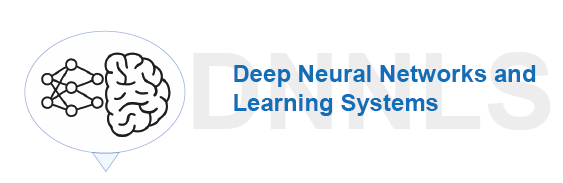

# Final assessment For Arinze Uwazurike - Main Notebook
---

**Introduction:**

In this notebook you will find a baseline, functional architecture for your assessment task.

In [ ]:
!pip install torchinfo
!pip install clip
!pip install evaluate
!pip install rouge_score
!pip install nltk

  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-0.2.0-py3-none-any.whl size=6989 sha256=080cdb97e2b0e08560564caaf793e74a7b0fe6926a30125c88c8b00d247d236e
  Stored in directory: /root/.cache/pip/wheels/6c/fd/54/9d4e15cf829b871199a7cd3597e869a514d1624a0a43076896
Successfully built clip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=dc6afb7eb4c96394b95f9f2424a57e29f2772c072d88952a94897cbf6be8643f
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [ ]:
# @title Importing the necessary libraries

import torch
import torch.nn as nn
import torch.nn.functional as F
import clip
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import numpy as np
import os
from nltk.translate.bleu_score import sentence_bleu
import json
import pandas as pd
from torchinfo import summary
from transformers import CLIPProcessor, CLIPModel, RobertaModel, RobertaTokenizer
import evaluate
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import tqdm
from datasets.fingerprint import random
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms.functional as FT
import math
from transformers import BertTokenizer
import gc

import textwrap

# **Chapter 1: The data preparation**


---



First we need to activate our google drive so that we can save out data permanently.

## 1.1 Loading and saving data

In [ ]:

# This will prompt you to authorize Google Drive access
from google.colab import drive
drive.mount('/content/drive')
def save_checkpoint_to_drive(model, optimizer, epoch, loss, filename="roberta_clip_checkpoint.pth"):
    """
    Saves the checkpoint directly to a specified folder in your mounted Google Drive.
    """
    # 1. Define the full Google Drive path
    # 'DL_Checkpoints' is the folder you want to save to inside your Drive
    drive_folder = '/content/drive/MyDrive/DL_Checkpoints'

    # Ensure the directory exists before attempting to save
    os.makedirs(drive_folder, exist_ok=True)

    # 2. Combine the folder and the filename
    full_path = os.path.join(drive_folder, filename)

    # 3. Create the checkpoint dictionary
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }

    # 4. Save the dictionary to the Google Drive path
    torch.save(checkpoint, full_path)
    print(f"Checkpoint saved to Google Drive: {full_path} at epoch {epoch}")


def load_checkpoint_from_drive(model, optimizer=None, filename="roberta_clip_checkpoint.pth"):
    """
    Loads a checkpoint from your Google Drive folder into the model and optimizer (if provided).
    """
    # Define the same Google Drive folder path
    drive_folder = '/content/drive/MyDrive/DL_Checkpoints'
    full_path = os.path.join(drive_folder, filename)

    # Check if the checkpoint file exists
    if not os.path.exists(full_path):
        raise FileNotFoundError(f"Checkpoint file not found: {full_path}")

    # Load the checkpoint
    checkpoint = torch.load(full_path, map_location=torch.device('cpu'))  # use cuda if available

    # Restore model state
    model.load_state_dict(checkpoint['model_state_dict'])

    # Restore optimizer state (if provided)
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # Extract metadata
    epoch = checkpoint.get('epoch', 0)
    loss = checkpoint.get('loss', None)

    print(f"Checkpoint loaded from: {full_path} (epoch {epoch})")

    return model, optimizer, epoch, loss

Mounted at /content/drive


We need to define a couple of functions to make our life easier. Feel free to tweak those functions:

In [ ]:

emb_dim = 128
latent_dim = 128
num_layers = 6
max_seq_len = 120
batch_size = 16
dropout = 0.1

In [ ]:
# @title Functions to show images and process data
"""
This cell provides essential data processing and visualization tools.
1. `parse_gdi_text`: Parses the raw "GDI" (Graph-Text-Interleaved) format from the dataset into a structured dictionary containing objects, actions, and locations.
2. `show_image`: A helper using matplotlib to display pytorch tensors as images, handling optional de-normalization.
"""

# This function just extracts the tags from the text, don't get distracted by it.
# I changed this function a bit to fix some bugs
def parse_gdi_text(text):
    """Parse GDI formatted text into structured data"""
    soup = BeautifulSoup(text, 'html.parser')
    images = []

    for gdi in soup.find_all('gdi'):
        # Debug: print what BeautifulSoup sees

        # Method 1: Try to get image attribute directly
        image_id = None
        if gdi.attrs:
            # Check for attributes like 'image1', 'image2', etc.
            for attr_name, attr_value in gdi.attrs.items():
                if 'image' in attr_name.lower():
                    image_id = attr_name.replace('image', '')
                    break

        # Method 2: Extract from the tag string using regex
        if not image_id:
            tag_str = str(gdi)
            match = re.search(r'<gdi\s+image(\d+)', tag_str)
            if match:
                image_id = match.group(1)

        # Method 3: Fallback - use sequential numbering
        if not image_id:
            image_id = str(len(images) + 1)

        content = gdi.get_text().strip()

        # Extract tagged elements using BeautifulSoup directly
        objects = [obj.get_text().strip() for obj in gdi.find_all('gdo')]
        actions = [act.get_text().strip() for act in gdi.find_all('gda')]
        locations = [loc.get_text().strip() for loc in gdi.find_all('gdl')]

        images.append({
            'image_id': image_id,
            'description': content,
            'objects': objects,
            'actions': actions,
            'locations': locations,
            'raw_text': str(gdi)
        })

    return images

# This is an utility function to show images.
# Why do we need to do all this?
def show_image(ax, image, de_normalize = False, img_mean = None, img_std = None):
  """
  De-normalize the image (if necessary) and show image
  """
  if de_normalize:
    new_mean = -img_mean/img_std
    new_std = 1/img_std

    image = transforms.Normalize(
        mean=new_mean,
        std=new_std
    )(image)
  ax.imshow(image.permute(1, 2, 0))

In [ ]:
# @title CoT grounding helpers (added)
"""
This cell contains helper functions to parse the "Chain-of-Thought" (CoT) annotations provided in the dataset.
1. `parse_cot_grounding`: Extracts bounding boxes for characters and objects from the CoT markdown tables.
2. `crop_and_resize`: Crops an image region based on a bounding box and resizes it to a fixed size (60x125).
3. `pick_reid_pair`: Selects a pair of bounding boxes for the same entity across different frames to support Re-Identification (ReID) learning.
4. `extract_cot_text_for_frame`: Extracts the text reasoning corresponding to a specific frame.
"""

import random
import re
from typing import Dict, Any, List, Optional, Tuple

def _parse_markdown_table(block: str) -> List[Dict[str, str]]:
    lines = [l.rstrip() for l in block.splitlines()]
    table_lines = [l for l in lines if l.strip().startswith("|")]
    if len(table_lines) < 3:
        return []
    header_line = table_lines[0]
    data_lines = table_lines[2:]
    headers = [h.strip() for h in header_line.strip("|").split("|")]
    rows = []
    for line in data_lines:
        if not line.strip().startswith("|"):
            break
        cols = [c.strip() for c in line.strip("|").split("|")]
        if len(cols) != len(headers):
            continue
        rows.append(dict(zip(headers, cols)))
    return rows

def parse_cot_grounding(chain_of_thought: str) -> Dict[int, Dict[str, Any]]:
    """Parse StoryReasoning-style CoT markdown into per-frame bbox annotations."""
    frames: Dict[int, Dict[str, Any]] = {}
    img_pattern = re.compile(r"^##\s*Image\s+(\d+)", flags=re.MULTILINE)
    matches = list(img_pattern.finditer(chain_of_thought or ""))

    for i, m in enumerate(matches):
        img_idx = int(m.group(1)) - 1
        start = m.end()
        end = matches[i + 1].start() if (i + 1 < len(matches)) else len(chain_of_thought)
        section = (chain_of_thought or "")[start:end]

        frames[img_idx] = {"characters": [], "objects": []}

        char_match = re.search(r"###\s*Characters(.*?)(?=\n###|\n##|$)", section, flags=re.DOTALL)
        if char_match:
            for row in _parse_markdown_table(char_match.group(1)):
                cid = row.get("Character ID", "").strip()
                bbox_str = row.get("Bounding Box", "").strip()
                if cid and bbox_str:
                    try:
                        x1, y1, x2, y2 = [int(v) for v in bbox_str.split(",")]
                        frames[img_idx]["characters"].append({"id": cid, "bbox": [x1, y1, x2, y2]})
                    except Exception:
                        pass

        obj_match = re.search(r"###\s*Objects(.*?)(?=\n###|\n##|$)", section, flags=re.DOTALL)
        if obj_match:
            for row in _parse_markdown_table(obj_match.group(1)):
                oid = row.get("Object ID", "").strip()
                bbox_str = row.get("Bounding Box", "").strip()
                if oid and bbox_str:
                    try:
                        x1, y1, x2, y2 = [int(v) for v in bbox_str.split(",")]
                        frames[img_idx]["objects"].append({"id": oid, "bbox": [x1, y1, x2, y2]})
                    except Exception:
                        pass
    return frames

def _clamp_bbox(x1, y1, x2, y2, W, H):
    x1 = max(0, min(x1, W - 1))
    x2 = max(0, min(x2, W - 1))
    y1 = max(0, min(y1, H - 1))
    y2 = max(0, min(y2, H - 1))
    if x2 <= x1:
        x2 = min(W - 1, x1 + 1)
    if y2 <= y1:
        y2 = min(H - 1, y1 + 1)
    return x1, y1, x2, y2

def crop_and_resize(pil_img, bbox, out_hw=(60, 125)):
    x1, y1, x2, y2 = bbox
    W, H = pil_img.size
    x1, y1, x2, y2 = _clamp_bbox(x1, y1, x2, y2, W, H)
    crop = pil_img.crop((x1, y1, x2, y2))
    crop = transforms.Resize(out_hw)(crop)
    crop = transforms.ToTensor()(crop)
    return crop

def pick_reid_pair(frames_cot: Dict[int, Dict[str, Any]]) -> Optional[Tuple[int, int, List[int], List[int], str]]:
    """Pick two detections of the same entity id across frames."""
    id_to_dets = {}
    for f_idx, content in frames_cot.items():
        for det in content.get("characters", []) + content.get("objects", []):
            ent_id = det.get("id")
            bbox = det.get("bbox")
            if ent_id and bbox:
                id_to_dets.setdefault(ent_id, []).append((f_idx, bbox))

    candidates = [ent_id for ent_id, dets in id_to_dets.items() if len(dets) >= 2]
    if not candidates:
        return None

    ent_id = random.choice(candidates)
    dets = id_to_dets[ent_id]
    (f1, b1), (f2, b2) = random.sample(dets, 2)
    return f1, f2, b1, b2, ent_id

def extract_cot_text_for_frame(chain_of_thought: str, frame_idx: int, max_chars: int = 600) -> str:
    """Option 4 helper: extract the 'Image N' section as plain text (best-effort)."""
    if not chain_of_thought:
        return ""
    img_pattern = re.compile(r"^##\s*Image\s+(\d+)", flags=re.MULTILINE)
    matches = list(img_pattern.finditer(chain_of_thought))
    target = None
    for i, m in enumerate(matches):
        if int(m.group(1)) - 1 == frame_idx:
            start = m.end()
            end = matches[i + 1].start() if (i + 1 < len(matches)) else len(chain_of_thought)
            target = chain_of_thought[start:end]
            break
    if target is None:
        return ""
    # Remove markdown tables (keep only non-table lines)
    lines = []
    for line in target.splitlines():
        if line.strip().startswith("|"):
            continue
        if set(line.strip()) <= set("-|:"):
            continue
        lines.append(line)
    text = " ".join([l.strip() for l in lines if l.strip()])
    text = re.sub(r"\s+", " ", text).strip()
    return text[:max_chars]

Now we load dataset from HuggingFace:

In [ ]:
# @title Loading the dataset
from datasets import load_dataset

train_dataset = load_dataset("daniel3303/StoryReasoning", split="train")
test_dataset = load_dataset("daniel3303/StoryReasoning", split="test")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.94k [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/327M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/331M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3552 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/626 [00:00<?, ? examples/s]

## 1.2 Three datasets


---



We will create three different dataset objects and the corresponding loaders for performing multiple tasks

In [ ]:
# @title CoT improvements toggles (added)
"""
Configuration flags to control which Chain-of-Thought (CoT) mechanisms are used during training:
- `USE_FRAME_AWARE_GROUNDING`: Aligns ROI embeddings with the text embedding of the specific frame (vs global).
- `USE_CONTRASTIVE_ROI`: Enables InfoNCE loss to contrast positive ROI-text pairs against negatives.
- `USE_ENTITY_POOLING`: Enforces consistency of embeddings for the same entity within a batch.
- `USE_COT_TEXT`: Appends CoT reasoning text to the input frame description.
"""

# Turn these on/off to control the 4 optional improvements.
USE_FRAME_AWARE_GROUNDING = True      # Option 2: align ROI to matching frame text embedding (instead of always frame 0)
USE_CONTRASTIVE_ROI = True            # Option 1: InfoNCE-style contrastive grounding using batch negatives
USE_ENTITY_POOLING = True             # Option 3: entity-specific pooling/consistency across batch by entity_id
USE_COT_TEXT = True                   # Option 4: concatenate CoT text snippet to the frame descriptions

# Contrastive temperature (only used if USE_CONTRASTIVE_ROI=True)
CONTRASTIVE_TAU = 0.07

In [ ]:
# @title Main dataset
"""
Defines the `SequencePredictionDataset` class, which is the core data provider for the main task.
1. `__getitem__`:
   - Loads 5 frames (4 context + 1 target).
   - Parses text descriptions and optionally appends CoT text.
   - Extracts bounding box crops (ROIs) for grounding tasks if CoT data is available.
   - Returns a tuple containing: sequence images, descriptions, target image, target text, ROI crops, and validity flags.
"""
#Modified
class SequencePredictionDataset(Dataset):
    def __init__(self, original_dataset, tokenizer, K: int = 4, max_len: int = 120, image_hw=(224, 224)):
        super(SequencePredictionDataset, self).__init__()
        self.dataset = original_dataset
        self.tokenizer = tokenizer
        self.K = K
        self.max_len = max_len
        self.image_hw = image_hw

        # Potential experiments: Try other transforms!
        self.transform = transforms.Compose([
          transforms.Resize(image_hw),  # Reasonable size based on our previous analysis
          transforms.ToTensor(),        # HxWxC -> CxHxW
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
      """
      Selects a 5 frame sequence from the dataset. Sets 4 for training and the last one
      as a target.

      Returns:
        frames:        [K, C, H, W]
        descriptions:  [K, T]
        image_target:  [C, H, W]
        target_ids:    [1, T]
        roi1, roi2:    [C, H, W] (cropped from CoT bboxes, if available)
        roi_valid:     0/1
        roi_frame:     frame index for roi1 (0..K-1) if available else -1
        ent_id:        string id for the ROI entity (empty if none)
      """
      frames = self.dataset[idx]["images"]
      image_attributes = parse_gdi_text(self.dataset[idx]["story"])

      # CoT grounding annotations (may be missing / unparseable)
      cot = self.dataset[idx].get("chain_of_thought", "")
      cot_frames = parse_cot_grounding(cot)

      frame_tensors = []
      description_list = []

      for frame_idx in range(self.K):
        image = FT.equalize(frames[frame_idx])
        input_frame = self.transform(image)
        frame_tensors.append(input_frame)

        description = image_attributes[frame_idx]["description"]

        # Option 4: include CoT text snippet for this frame (best-effort)
        if USE_COT_TEXT:
          cot_txt = extract_cot_text_for_frame(cot, frame_idx)
          if cot_txt:
            description = description + " [COT] " + cot_txt

        input_ids = self.tokenizer(
            description,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=self.max_len
        ).input_ids.squeeze(0)

        description_list.append(input_ids)

      image_target = FT.equalize(frames[self.K])
      image_target = self.transform(image_target)

      main_description = image_attributes[0]["description"]
      encoded = self.tokenizer(
          main_description,
          padding="max_length",
          truncation=True,
          max_length=self.max_len,
          return_tensors= "pt"
      ) # [1, T]

      text_dict = {"input_ids":encoded['input_ids'][0],
                   "attention_mask": encoded["attention_mask"][0],
                   "decoder_input_ids": encoded["input_ids"][0,:-1],
                   "target_ids": encoded["input_ids"][0, 1:]
                   }

      # ---- CoT ROI pair (Options 1-3 need these) ----
      roi_valid = torch.tensor(0, dtype=torch.long)
      roi1 = torch.zeros((3, self.image_hw[0], self.image_hw[1]))
      roi2 = torch.zeros((3, self.image_hw[0], self.image_hw[1]))
      roi_frame = torch.tensor(-1, dtype=torch.long)
      ent_id = ""

      pair = pick_reid_pair(cot_frames)
      if pair is not None:
        f1, f2, b1, b2, ent_id = pair
        # We only use ROIs that fall within the input window (0..K-1)
        if (0 <= f1 < self.K) and (0 <= f2 < self.K):
          try:
            roi1 = crop_and_resize(frames[f1], b1, out_hw=self.image_hw)
            roi2 = crop_and_resize(frames[f2], b2, out_hw=self.image_hw)
            roi_valid = torch.tensor(1, dtype=torch.long)
            roi_frame = torch.tensor(int(f1), dtype=torch.long)
          except Exception:
            pass

      sequence_tensor = torch.stack(frame_tensors)          # [K, C, H, W]
      obj_labels = tuple(["bg"] * self.K + ["bg"])

      ent_id_tensor = torch.tensor([0], dtype=torch.long) # placeholder

      return (
          sequence_tensor, #0: frames,
          image_target,
          roi1, roi2, roi_valid, roi_frame,
          ent_id_tensor, #6: ent_id as tensor
          text_dict, # 7: Text Dict
          obj_labels #8: tuple
      )

In [ ]:
# @title Text task dataset (text autoencoding)
"""
Defines `TextTaskDataset` for pre-training or fine-tuning the text encoder separately.
It simply pulls a random text description from a story to perform text-to-text autoencoding.
"""
#Modified
class TextTaskDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_len=128):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        image_attributes = parse_gdi_text(sample["story"])
        frame_idx = np.random.randint(0, len(image_attributes))
        description = image_attributes[frame_idx]["description"]

        encoded = self.tokenizer(
            description,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        input_ids = encoded["input_ids"].squeeze(0)
        attention_mask = encoded["attention_mask"].squeeze(0)

        decoder_input_ids = input_ids[:-1]
        target_ids = input_ids[1:]

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "decoder_input_ids": decoder_input_ids,
            "target_ids": target_ids
        }

In [ ]:
# @title Dataset for image autoencoder task
"""
Defines `AutoEncoderTaskDataset` for pre-training the visual autoencoder.
It retrieves a single random frame from the dataset to learn image reconstruction (Image -> Latent -> Image).
"""

class AutoEncoderTaskDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.transform = transforms.Compose([
          transforms.Resize((224, 224)),# Reasonable size based on our previous analysis
          transforms.ToTensor(), # HxWxC -> CxHxW
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
      num_frames = self.dataset[idx]["frame_count"]
      frames = self.dataset[idx]["images"]

      # Pick a frame at random
      frame_idx = torch.randint(0, 5, (1,)).item()
      input_frame = self.transform(frames[frame_idx]) # Input to the autoencoder

      return input_frame, # Returning the image

## 1.3 Creating and testing our dataset objects and loaders


---



In [ ]:
# @title For the Sequence prediction task
"""
This cell sets up the data pipeline for the main sequence prediction task.
1. Initializes the BERT tokenizer.
2. Creates `SequencePredictionDataset` instances for training and testing.
3. Splits the training data into `train_subset` and `val_subset`.
4. Creates `DataLoader` objects (`train_dataloader`, `val_dataloader`, `test_dataloader`) to batch and shuffle the data.
"""
#Modified
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base") #
sp_train_dataset = SequencePredictionDataset(train_dataset, tokenizer) # Instantiate the train dataset
sp_test_dataset = SequencePredictionDataset(test_dataset, tokenizer) # Instantiate the test dataset

# Let's do things properly, we will also have a validation split
# Split the training dataset into training and validation sets
train_size = int(0.8 * len(sp_train_dataset))
val_size = len(sp_train_dataset) - train_size
train_subset, val_subset = random_split(sp_train_dataset, [train_size, val_size])

# Instantiate the dataloaders
train_dataloader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
# We will use the validation set to visualize the progress.
val_dataloader = DataLoader(val_subset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(sp_test_dataset, batch_size=batch_size, shuffle=False)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
# @title For the text task
"""
Sets up the data pipeline for the auxiliary text autoencoding task.
Creates the `TextTaskDataset` and its corresponding `DataLoader`.
"""
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
text_dataset = TextTaskDataset(train_dataset, tokenizer, max_len=128)
text_dataloader = DataLoader(text_dataset, batch_size=batch_size, shuffle=True)

In [ ]:

for batch in text_dataloader:
    print(batch["input_ids"].shape, batch["attention_mask"].shape)
    break

torch.Size([16, 128]) torch.Size([16, 128])


In [ ]:
print(train_dataset[0].keys())

dict_keys(['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'])


In [ ]:
# @title For the image autoencoder task
"""
Sets up the data pipeline for the auxiliary visual autoencoding task.
Creates the `AutoEncoderTaskDataset` and its `DataLoader`.
"""

autoencoder_dataset = AutoEncoderTaskDataset(train_dataset)
autoencoder_dataloader = DataLoader(autoencoder_dataset, batch_size=batch_size, shuffle=True)

Description:  torch.Size([3, 224, 224])
torch.Size([16, 4, 3, 224, 224])
torch.Size([16, 3, 224, 224])


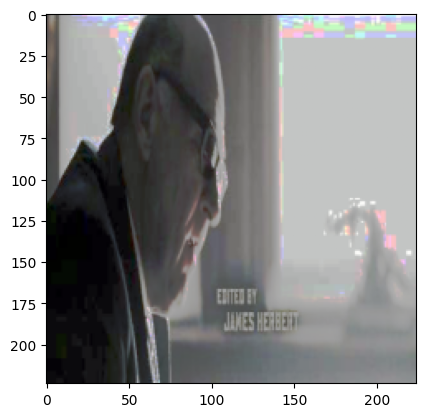

In [ ]:
"""
A sanity check cell to verify the data pipeline.
It grabs a single batch from the training dataset and prints the shapes of the returned tensors (images, descriptions, etc.) to ensure everything is loaded correctly.
"""
#Modified
# Single sample check
sample = sp_train_dataset[np.random.randint(0,400)]
frames, image_target, roi1, roi2, roi_valid, roi_frame, ent_id, text_dict, obj_labels = sample


print("Description: ", image_target.shape)
figure, ax = plt.subplots(1,1)
show_image(ax, image_target)

# Do some tests on the batches (try with batch size small)
frames, descriptions, image_target, text_target, roi1, roi2, roi_valid, roi_frame, ent_id = next(iter(train_dataloader))
print(frames.shape)
print(descriptions.shape)

I will leave the test of the other datasets to you.

# **Models**


---



In [ ]:
import math
import torch
import torch.nn as nn
from transformers import RobertaModel

# =========================================================
# Sinusoidal Positional Encoding
# =========================================================
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2048):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len]


# =========================================================
# RoBERTa Encoder
# =========================================================
class RobertaEncoder(nn.Module):
    def __init__(
        self,
        model_name="roberta-base",
        unfreeze_layers=8,
        memory_dropout=0.1
    ):
        super().__init__()

        self.roberta = RobertaModel.from_pretrained(model_name)

        # Freeze everything first
        for param in self.roberta.parameters():
            param.requires_grad = False

        # Unfreeze final encoder layers
        if unfreeze_layers > 0:
            for layer in self.roberta.encoder.layer[-unfreeze_layers:]:
                for param in layer.parameters():
                    param.requires_grad = True

        self.memory_dropout = nn.Dropout(memory_dropout)

    def forward(self, input_ids, attention_mask=None):

        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        memory = outputs.last_hidden_state

        # Better regularization than noise injection
        memory = self.memory_dropout(memory)

        return memory


# =========================================================
# Causal Mask
# =========================================================
def generate_square_subsequent_mask(sz, device):

    mask = torch.triu(
        torch.ones(sz, sz, device=device),
        diagonal=1
    ).bool()

    return mask


# =========================================================
# Transformer Decoder
# =========================================================
class TransformerDecoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=768,
        nhead=8,
        num_layers=6,
        dropout=0.15,
        max_len=2048
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)

        self.pos_encoding = SinusoidalPositionalEncoding(
            d_model=d_model,
            max_len=max_len
        )

        self.input_norm = nn.LayerNorm(d_model)

        self.embed_dropout = nn.Dropout(dropout)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=num_layers
        )

        # Final stabilization layer
        self.final_norm = nn.LayerNorm(d_model)

        # Output projection
        self.out = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying
        self.out.weight = self.embedding.weight

    def forward(
        self,
        tgt,
        memory,
        tgt_mask=None,
        tgt_key_padding_mask=None,
        memory_key_padding_mask=None
    ):

        # Token embedding scaling
        x = self.embedding(tgt) * math.sqrt(
            self.embedding.embedding_dim
        )

        # Positional encoding
        x = self.pos_encoding(x)

        # Input normalization
        x = self.input_norm(x)

        # Embedding dropout
        x = self.embed_dropout(x)

        # Decoder
        x = self.decoder(
            tgt=x,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )

        # Final normalization
        x = self.final_norm(x)

        # Vocabulary logits
        logits = self.out(x)

        return logits


# =========================================================
# Full Seq2Seq Model
# =========================================================
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(
        self,
        src,
        tgt,
        src_attention_mask=None,
        tgt_mask=None,
        src_key_padding_mask=None,
        tgt_key_padding_mask=None
    ):

        # Encoder memory
        memory = self.encoder(
            input_ids=src,
            attention_mask=src_attention_mask
        )

        # Generate causal mask automatically
        if tgt_mask is None:
            tgt_mask = generate_square_subsequent_mask(
                tgt.size(1),
                device=tgt.device
            )

        # Decoder forward
        return self.decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )


## The Vision models

In [ ]:
# =========================================================
# Predictive Visual Latent Autoencoder (CLIP-based)
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import CLIPModel
from torchvision import models

# =========================================================
# Residual Block
# =========================================================

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.GroupNorm(8, channels),
            nn.GELU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.GroupNorm(8, channels)
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


# =========================================================
# Attention Block
# =========================================================

class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=8):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.attn = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            batch_first=True
        )

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x).view(B, C, H * W).transpose(1, 2)
        attn_out, _ = self.attn(h, h, h)
        return x + attn_out.transpose(1, 2).view(B, C, H, W)


# =========================================================
# CLIP Encoder (Predictive + Stochastic)
# =========================================================

class CLIPEncoderWrapper(nn.Module):
    def __init__(self, latent_dim=256, spatial_dim=256, unfreeze_layers=4):
        super().__init__()

        self.clip = CLIPModel.from_pretrained(
            "openai/clip-vit-base-patch16"
        )

        self.clip.vision_model.config.output_hidden_states = True

        for p in self.clip.parameters():
            p.requires_grad = False

        for layer in self.clip.vision_model.encoder.layers[-unfreeze_layers:]:
            for p in layer.parameters():
                p.requires_grad = True

        hidden = self.clip.config.vision_config.hidden_size

        # -------- VAE heads --------
        self.mu = nn.Sequential(
            nn.Linear(hidden, 512),
            nn.GELU(),
            nn.Linear(512, latent_dim)
        )

        self.logvar = nn.Sequential(
            nn.Linear(hidden, 512),
            nn.GELU(),
            nn.Linear(512, latent_dim)
        )

        # -------- spatial latent --------
        self.spatial = nn.Sequential(
            nn.Conv2d(768, 512, 1),
            nn.GroupNorm(8, 512),
            nn.GELU(),
            nn.Conv2d(512, spatial_dim, 1)
        )

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):

        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)

        mean = torch.tensor([0.481, 0.457, 0.408], device=x.device).view(1,3,1,1)
        std  = torch.tensor([0.268, 0.261, 0.275], device=x.device).view(1,3,1,1)
        x = (x - mean) / std

        out = self.clip.vision_model(pixel_values=x, return_dict=True, output_hidden_states=True)

        pooled = out.pooler_output

        mu = self.mu(pooled)
        logvar = self.logvar(pooled)
        z = self.reparam(mu, logvar)

        # Ensure hidden_states exist (needed for torchinfo)
        h_states = out.hidden_states if out.hidden_states is not None else [out.last_hidden_state]
        patches = h_states[-1][:, 1:, :].transpose(1, 2)
        B = patches.shape[0]
        patches = patches.reshape(B, 768, 14, 14)

        spatial_z = self.spatial(patches)

        return z, mu, logvar, spatial_z


# =========================================================
# Decoder
# =========================================================

class VisualDecoder(nn.Module):
    def __init__(self, latent_dim=256, spatial_dim=256):
        super().__init__()

        self.fc = nn.Linear(latent_dim, 256 * 14 * 14)

        self.fuse = nn.Conv2d(256 + spatial_dim, 256, 3, padding=1)

        self.up = nn.Sequential(
            ResidualBlock(256),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.GELU(),
            ResidualBlock(128),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.GELU(),
            ResidualBlock(64),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.GELU(),
            ResidualBlock(32),

            nn.ConvTranspose2d(32, 16, 4, 2, 1),
            nn.GELU(),
            ResidualBlock(16),

            nn.Conv2d(16, 3, 3, padding=1),
            nn.Tanh()
        )

    def forward(self, z, spatial_z):

        B = z.size(0)

        x = self.fc(z).view(B, 256, 14, 14)

        x = torch.cat([x, spatial_z], dim=1)

        x = self.fuse(x)

        return self.up(x)


# =========================================================
# FULL AUTOENCODER (NOW PREDICTIVE)
# =========================================================

class VisualAutoencoder(nn.Module):
    def __init__(self, latent_dim=256, spatial_dim=256):
        super().__init__()

        self.encoder = CLIPEncoderWrapper(latent_dim, spatial_dim)
        self.decoder = VisualDecoder(latent_dim, spatial_dim)

        # -------- CRITICAL ADDITION --------
        # latent predictor (temporal modeling)
        self.latent_predictor = nn.Sequential(
            nn.Linear(latent_dim, latent_dim),
            nn.GELU(),
            nn.Linear(latent_dim, latent_dim)
        )

    def forward(self, x):

        z, mu, logvar, spatial = self.encoder(x)

        x_hat = self.decoder(z, spatial)

        return x_hat, z, mu, logvar, spatial

    # predict next latent (KEY FOR SEQUENCE MODEL)
    def predict_next_latent(self, z_t):
        return self.latent_predictor(z_t)


# =========================================================
# LOSSES
# =========================================================

class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_FEATURES)
        self.features = nn.Sequential(*list(vgg.features[:16])).eval()
        for p in self.features.parameters():
            p.requires_grad = False

    def forward(self, pred, target):
        return F.l1_loss(self.features(pred), self.features(target))


class KLLoss(nn.Module):
    def forward(self, mu, logvar):
        return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())


class ReconstructionLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.perc = PerceptualLoss()
        self.kl = KLLoss()

    def forward(self, pred, target, mu, logvar):

        pixel = 0.5 * F.mse_loss(pred, target) + 0.5 * F.l1_loss(pred, target)
        perceptual = self.perc(pred, target)
        kl = self.kl(mu, logvar)

        return {
            "total": pixel + 0.3 * perceptual + 0.01 * kl,
            "pixel": pixel,
            "perceptual": perceptual,
            "kl": kl
        }

## 2.3 The main architecture


In [ ]:
# =========================================================
# Learnable Attention Pooling
# =========================================================

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.score = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Tanh(),
            nn.Linear(dim, 1)
        )

    def forward(self, x):
        """
        x: [B, T, D]
        """

        scores = self.score(x)                    # [B, T, 1]
        weights = torch.softmax(scores, dim=1)   # [B, T, 1]

        pooled = (x * weights).sum(dim=1)        # [B, D]

        return pooled, weights


# =========================================================
# Cross Attention Fusion
# =========================================================

class CrossAttentionFusion(nn.Module):
    def __init__(
        self,
        vision_dim,
        text_dim,
        hidden_dim,
        num_heads=8,
        dropout=0.1
    ):
        super().__init__()

        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.vision_proj = nn.Linear(vision_dim, hidden_dim)

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, vision_seq, text_seq):
        """
        vision_seq: [B, T, vision_dim]
        text_seq:   [B, L, text_dim]
        """

        q = self.vision_proj(vision_seq)
        k = self.text_proj(text_seq)
        v = self.text_proj(text_seq)

        attn_out, attn_weights = self.cross_attn(
            query=q,
            key=k,
            value=v
        )

        fused = self.norm(q + attn_out)

        return fused, attn_weights


# =========================================================
# Multi Scale Temporal Transformer
# =========================================================

class MultiScaleTemporalTransformer(nn.Module):
    def __init__(
        self,
        dim,
        num_heads=8,
        num_layers=4,
        dropout=0.1
    ):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=num_heads,
            dim_feedforward=dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.layers = nn.ModuleList([
            nn.TransformerEncoder(encoder_layer, num_layers=1)
            for _ in range(num_layers)
        ])

        self.scale_fusion = nn.Sequential(
            nn.Linear(dim * num_layers, dim),
            nn.GELU(),
            nn.LayerNorm(dim)
        )

    def forward(self, x):
        """
        x: [B, T, D]
        """

        multi_scale_features = []

        for layer in self.layers:

            x = layer(x)

            multi_scale_features.append(x)

        fused = torch.cat(multi_scale_features, dim=-1)

        fused = self.scale_fusion(fused)

        return fused


# =========================================================
# Spatial Preserving Visual Projection
# =========================================================

class SpatialFeatureProjector(nn.Module):
    def __init__(
        self,
        in_channels=256,
        hidden_channels=256,
        output_dim=512
    ):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                hidden_channels,
                kernel_size=3,
                padding=1
            ),

            nn.GroupNorm(8, hidden_channels),
            nn.GELU(),

            nn.Conv2d(
                hidden_channels,
                hidden_channels,
                kernel_size=3,
                padding=1
            ),

            nn.GroupNorm(8, hidden_channels),
            nn.GELU()
        )

        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        self.final_proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels * 4 * 4, output_dim),
            nn.GELU(),
            nn.LayerNorm(output_dim)
        )

    def forward(self, x):

        x = self.conv(x)

        x = self.pool(x)

        x = self.final_proj(x)

        return x



### Implementation Note
By using `MultiHeadTemporalAttention`, we ensure that the `SequencePredictor` doesn't just rely on the final GRU hidden state (which can lose information over long sequences), but instead learns which specific frames in the context are most relevant for denoising the target frame.

In [ ]:
import math
import torch
import torch.nn as nn


# =========================================================
# Internal Latent Dynamics Model
# =========================================================

class LatentDynamicsModel(nn.Module):
    """
    Refines the predicted next latent by combining:
      - z_t   : the last temporal hidden state  [B, hidden_dim]
      - context: attention-pooled sequence mean  [B, hidden_dim]
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim * 2),
            nn.GELU(),
            nn.LayerNorm(hidden_dim * 2),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
        )

    def forward(self, z_t: torch.Tensor, context: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([z_t, context], dim=-1))


# =========================================================
# Sequence Predictor
# =========================================================

class SequencePredictor(nn.Module):
    """
    Predicts the next image AND next text given a sequence of
    (image, text) pairs (default window = 4 steps).

    Args:
        visual_autoencoder : VisualAutoencoder  – provides .encoder / .decoder
        text_autoencoder   : Seq2Seq            – provides .encoder / .decoder
        latent_dim         : visual VAE latent size (default 256)
        hidden_dim         : shared working dimension across all temporal /
                             fusion modules (default 512)
        temporal_layers    : depth of MultiScaleTemporalTransformer (default 4)
        temporal_heads     : attention heads in temporal transformer (default 8)
        cross_attention_heads : heads in CrossAttentionFusion (default 8)
        dropout            : dropout rate throughout (default 0.1)

    Forward inputs:
        image_seq               [B, T, C, H, W]
        input_ids_text_encoder  [B, T, L]   – token ids for each timestep
        attention_mask_text_enc [B, T, L]   – padding mask for encoder
        target_seq_text_decoder [B, S]      – decoder input ids (teacher-forced)

    Forward outputs (dict):
        pred_image       [B, 3, H, W]   – reconstructed next frame
        pred_text_logits [B, S, vocab]  – next-text logits (teacher-forced)
        z_next           [B, hidden_dim]
        spatial_z        [B, spatial_dim, 14, 14]
        mu               [B, latent_dim]   – for KL loss
        logvar           [B, latent_dim]   – for KL loss
    """

    def __init__(
        self,
        visual_autoencoder,
        text_autoencoder,
        latent_dim: int = 256,
        hidden_dim: int = 512,
        temporal_layers: int = 4,
        temporal_heads: int = 8,
        cross_attention_heads: int = 8,
        dropout: float = 0.1,
    ):
        super().__init__()

        # ── frozen / partially-frozen backbones ──────────────────────────
        # (do NOT modify these sub-modules)
        self.image_encoder = visual_autoencoder.encoder   # CLIPEncoderWrapper
        self.image_decoder = visual_autoencoder.decoder   # VisualDecoder

        self.text_encoder  = text_autoencoder.encoder    # RobertaEncoder
        self.text_decoder  = text_autoencoder.decoder    # TransformerDecoder

        # infer text encoder output dim (RoBERTa-base → 768)
        text_enc_dim: int = self.text_encoder.roberta.config.hidden_size  # 768

        # ── projections into shared hidden_dim ───────────────────────────
        # visual latent z (latent_dim) → hidden_dim
        self.visual_projector = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
        )

        # RoBERTa token sequence (text_enc_dim) → hidden_dim
        # Applied per-token before temporal modeling
        self.text_projector = nn.Sequential(
            nn.Linear(text_enc_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
        )

        # ── spatial feature projector ─────────────────────────────────────
        # SpatialFeatureProjector: [B, 256, 14, 14] → [B, hidden_dim]
        # (used to build the per-step spatial token fed into temporal model)
        self.spatial_projector = SpatialFeatureProjector(
            in_channels=256,
            hidden_channels=256,
            output_dim=hidden_dim,
        )

        # ── temporal transformers ─────────────────────────────────────────
        # Visual: operates on sequence of projected z vectors [B, T, hidden_dim]
        self.visual_temporal = MultiScaleTemporalTransformer(
            dim=hidden_dim,
            num_heads=temporal_heads,
            num_layers=temporal_layers,
            dropout=dropout,
        )

        # Text: operates on sequence of mean-pooled text tokens [B, T, hidden_dim]
        self.text_temporal = MultiScaleTemporalTransformer(
            dim=hidden_dim,
            num_heads=temporal_heads,
            num_layers=temporal_layers,
            dropout=dropout,
        )

        # ── attention pooling ─────────────────────────────────────────────
        # Collapses [B, T, hidden_dim] → [B, hidden_dim] with learned weights
        self.visual_attn_pool = AttentionPooling(dim=hidden_dim)
        self.text_attn_pool   = AttentionPooling(dim=hidden_dim)

        # ── cross-modal fusion ────────────────────────────────────────────
        # Queries: pooled visual features  [B, 1, hidden_dim]
        # Keys/Values: pooled text features [B, 1, hidden_dim]
        # Output: fused visual representation [B, 1, hidden_dim]
        self.cross_attention_fusion = CrossAttentionFusion(
            vision_dim=hidden_dim,
            text_dim=hidden_dim,
            hidden_dim=hidden_dim,
            num_heads=cross_attention_heads,
            dropout=dropout,
        )

        # ── latent dynamics model ─────────────────────────────────────────
        # Maps (fused_z, context) → z_next in hidden_dim space
        self.dynamics_model = LatentDynamicsModel(hidden_dim=hidden_dim)

        # ── projection back to latent_dim for the image decoder ──────────
        # VisualDecoder expects z of size latent_dim (256)
        self.z_to_latent = nn.Sequential(
            nn.Linear(hidden_dim, latent_dim),
            nn.LayerNorm(latent_dim),
        )

        # ── projection to text decoder memory dim (768) ──────────────────
        # TransformerDecoder.memory must be [B, *, 768] (d_model of RoBERTa)
        self.z_to_text_memory = nn.Sequential(
            nn.Linear(hidden_dim, text_enc_dim),
            nn.GELU(),
            nn.LayerNorm(text_enc_dim),
        )

    # ─────────────────────────────────────────────────────────────────────
    def forward(
        self,
        image_seq: torch.Tensor,               # [B, T, C, H, W]
        input_ids_text_encoder: torch.Tensor,  # [B, T, L]
        attention_mask_text_encoder: torch.Tensor,  # [B, T, L]
        target_seq_text_decoder: torch.Tensor, # [B, S]  teacher-forced target
    ) -> dict:

        B, T, C, H, W = image_seq.shape
        device = image_seq.device

        # ── 1. Encode every frame ─────────────────────────────────────────
        z_list, mu_list, logvar_list, spatial_list = [], [], [], []

        for t in range(T):
            z, mu, logvar, spatial_z = self.image_encoder(image_seq[:, t])
            z_list.append(z)           # each [B, latent_dim]
            mu_list.append(mu)
            logvar_list.append(logvar)
            spatial_list.append(spatial_z)  # each [B, 256, 14, 14]

        # Stack along time axis
        z_seq      = torch.stack(z_list, dim=1)       # [B, T, latent_dim]
        spatial_seq = torch.stack(spatial_list, dim=1) # [B, T, 256, 14, 14]

        # Keep mu/logvar of LAST frame for KL loss during sequence training
        mu_last     = mu_list[-1]
        logvar_last = logvar_list[-1]

        # ── 2. Project visual latents into hidden_dim ─────────────────────
        z_seq_proj = self.visual_projector(z_seq)     # [B, T, hidden_dim]

        # ── 3. Encode each text step, project, and mean-pool tokens ───────
        text_seq_list = []
        for t in range(T):
            # input_ids / attention_mask: [B, L]
            mem = self.text_encoder(
                input_ids=input_ids_text_encoder[:, t],
                attention_mask=attention_mask_text_encoder[:, t],
            )                                          # [B, L, 768]
            mem_proj = self.text_projector(mem)        # [B, L, hidden_dim]
            # Mean-pool over token dim to get a single vector per step
            mask = attention_mask_text_encoder[:, t].unsqueeze(-1).float()
            pooled = (mem_proj * mask).sum(1) / mask.sum(1).clamp(min=1)
            text_seq_list.append(pooled)               # [B, hidden_dim]

        text_seq_proj = torch.stack(text_seq_list, dim=1)  # [B, T, hidden_dim]

        # ── 4. Temporal modeling ──────────────────────────────────────────
        visual_temp = self.visual_temporal(z_seq_proj)     # [B, T, hidden_dim]
        text_temp   = self.text_temporal(text_seq_proj)    # [B, T, hidden_dim]

        # ── 5. Attention pooling over the T-step sequence ─────────────────
        # attn_weights shape: [B, T, 1]  — how much each timestep contributed
        visual_pooled, visual_attn_w = self.visual_attn_pool(visual_temp)  # [B, hidden_dim], [B, T, 1]
        text_pooled,   text_attn_w   = self.text_attn_pool(text_temp)      # [B, hidden_dim], [B, T, 1]

        # ── 6. Cross-modal fusion (vision queries text) ───────────────────
        # CrossAttentionFusion expects [B, seq, dim]; unsqueeze to add seq=1
        fused, _ = self.cross_attention_fusion(
            vision_seq=visual_pooled.unsqueeze(1),   # [B, 1, hidden_dim]
            text_seq=text_pooled.unsqueeze(1),        # [B, 1, hidden_dim]
        )                                             # [B, 1, hidden_dim]
        fused = fused.squeeze(1)                      # [B, hidden_dim]

        # ── 7. Latent dynamics: predict z_next ────────────────────────────
        # z_t    = last temporal visual hidden state
        # context = attention-pooled visual summary
        z_t     = visual_temp[:, -1]                  # [B, hidden_dim]
        context = visual_pooled                        # [B, hidden_dim]
        z_next  = self.dynamics_model(fused, context) # [B, hidden_dim]

        # ── 8. Spatial feature for image decoder ─────────────────────────
        # Project each frame's spatial map, then take the last one
        # (could be extended to a temporal fusion over spatial features)
        spatial_proj_list = [
            self.spatial_projector(spatial_seq[:, t])  # [B, hidden_dim]
            for t in range(T)
        ]
        # We still pass raw spatial of last frame to VisualDecoder
        # (decoder expects [B, spatial_dim=256, 14, 14])
        spatial_t = spatial_seq[:, -1]                 # [B, 256, 14, 14]

        # ── 9. Decode image ────────────────────────────────────────────────
        z_for_decoder = self.z_to_latent(z_next)       # [B, latent_dim]
        pred_image = self.image_decoder(z_for_decoder, spatial_t)
        # pred_image: [B, 3, H', W']

        # ── 10. Decode text ───────────────────────────────────────────────
        # Build memory for the TransformerDecoder from z_next
        # Memory shape must be [B, *, 768]; we use a single summary token
        text_memory = self.z_to_text_memory(z_next).unsqueeze(1)  # [B, 1, 768]

        # Causal mask for teacher-forced decoding
        S = target_seq_text_decoder.size(1)
        tgt_mask = _generate_causal_mask(S, device=device)

        pred_text_logits = self.text_decoder(
            tgt=target_seq_text_decoder,
            memory=text_memory,
            tgt_mask=tgt_mask,
        )                                              # [B, S, vocab_size]

        return {
            "pred_image":          pred_image,            # [B, 3, H', W']
            "pred_text_logits":    pred_text_logits,      # [B, S, vocab_size]
            "z_next":              z_next,                # [B, hidden_dim]
            "z_for_decoder":       z_for_decoder,         # [B, latent_dim]
            "spatial_z":           spatial_t,             # [B, 256, 14, 14]
            "mu":                  mu_last,               # [B, latent_dim]  for KL
            "logvar":              logvar_last,            # [B, latent_dim]  for KL
            # Learnable pooler weights – how much each of the T timesteps
            # contributed to the prediction. Shape [B, T], sums to ~1 over T.
            "visual_attn_weights": visual_attn_w.squeeze(-1),  # [B, T]
            "text_attn_weights":   text_attn_w.squeeze(-1),    # [B, T]
        }


# ─────────────────────────────────────────────────────────────────────────────
# Helper: causal mask (moved here so the class is self-contained)
# ─────────────────────────────────────────────────────────────────────────────

def _generate_causal_mask(sz: int, device: torch.device) -> torch.Tensor:
    return torch.triu(torch.ones(sz, sz, device=device), diagonal=1).bool()



# **Chapter 3: Training routines**


---




In [ ]:
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        # Use a slightly higher gain for leaky_relu to boost signal
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.01) # Small positive bias to keep neurons alive
    elif isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.constant_(m.bias, 0)

## 3.1 Initialization and setup

In [ ]:
# @title Initializing the NLP models
"""
1. Instantiates the `RobertaEncoder`, `DecoderLSTM`, and `Seq2SeqLSTM`.
2. Loads pre-trained weights from Google Drive (`text_autoencoder.pth`).
3. Freezes the text autoencoder parameters to keep them fixed during the main training phase.
"""
torch.cuda.empty_cache()
gc.collect()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
d_model = 768
text_encoder = RobertaEncoder(unfreeze_layers=4)
text_decoder = TransformerDecoder(
    vocab_size=tokenizer.vocab_size,
    d_model=d_model,
    nhead=8,
    num_layers=6
)

text_autoencoder = Seq2Seq(text_encoder, text_decoder).to(device)
#text_autoencoder, _, _, _ = load_checkpoint_from_drive(text_autoencoder, None, filename='text_autoencoder.pth')

trainable_params = sum(p.numel() for p in text_autoencoder.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in text_autoencoder.parameters())

print(f"Trainable params: {trainable_params}")
print(f"Total params: {total_params}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 123668736
Total params: 219962880


In [ ]:
# @title Initializing visual models
"""
1. Instantiates the `VisualAutoencoder`.
2. Applies the custom weight initialization.
"""

visual_autoencoder = VisualAutoencoder(latent_dim=256).to(device)
visual_autoencoder.decoder.apply(init_weights)
visual_autoencoder, _, _, _ = load_checkpoint_from_drive(visual_autoencoder, None, filename='visual_autoencoder.pth')
total_params = sum(p.numel() for p in visual_autoencoder.parameters() if p.requires_grad)
print(f"Total trainable parameters in visual autoencoder: {total_params}")

config.json:   0%|          | 0.00/4.10k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Checkpoint loaded from: /content/drive/MyDrive/DL_Checkpoints/visual_autoencoder.pth (epoch 14)
Total trainable parameters in visual autoencoder: 46405699


In [ ]:
dummy_input = torch.randint(0, tokenizer.vocab_size, (batch_size, max_seq_len)).to(device)
dummy_mask = torch.ones((batch_size, max_seq_len)).to(device)  # all tokens "valid"

print("===== Roberta Text Autoencoder Summary =====")

summary(
    text_autoencoder,
    input_data=(dummy_input, dummy_input, dummy_mask),  #
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=3
)

===== Roberta Text Autoencoder Summary =====


Layer (type:depth-idx)                                            Input Shape               Output Shape              Param #                   Trainable
Seq2Seq                                                           [16, 120]                 [16, 120, 50265]          --                        Partial
├─RobertaEncoder: 1-1                                             --                        [16, 120, 768]            --                        Partial
│    └─RobertaModel: 2-1                                          --                        [16, 768]                 --                        Partial
│    │    └─RobertaEmbeddings: 3-1                                --                        [16, 120, 768]            (39,000,576)              False
│    │    └─RobertaEncoder: 3-2                                   [16, 120, 768]            [16, 120, 768]            85,054,464                Partial
│    │    └─RobertaPooler: 3-3                                    [16, 120, 768]        

In [ ]:
# 3-channel RGB image, 64x64 resolution
dmy_image = torch.randn(batch_size, 3, 224, 224).to(device)

print("===== CLIP Visual Autoencoder Summary =====")
summary(
    visual_autoencoder,
    input_data=dmy_image,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=3
)

===== CLIP Visual Autoencoder Summary =====


Layer (type:depth-idx)                                                 Input Shape               Output Shape              Param #                   Trainable
VisualAutoencoder                                                      [16, 3, 224, 224]         [16, 3, 224, 224]         131,584                   Partial
├─CLIPEncoderWrapper: 1-1                                              [16, 3, 224, 224]         [16, 256]                 --                        Partial
│    └─CLIPModel: 2-1                                                  --                        --                        63,821,313                Partial
│    │    └─CLIPVisionTransformer: 3-1                                 --                        [16, 768]                 85,799,424                Partial
│    └─Sequential: 2-2                                                 [16, 768]                 [16, 256]                 --                        True
│    │    └─Linear: 3-2                                    

In [ ]:
# @title Loading the dataset
from datasets import load_dataset

train_dataset = load_dataset("daniel3303/StoryReasoning", split="train")
test_dataset = load_dataset("daniel3303/StoryReasoning", split="test")

# @title For the Sequence prediction task
"""
This cell sets up the data pipeline for the main sequence prediction task.
1. Initializes the BERT tokenizer.
2. Creates `SequencePredictionDataset` instances for training and testing.
3. Splits the training data into `train_subset` and `val_subset`.
4. Creates `DataLoader` objects (`train_dataloader`, `val_dataloader`, `test_dataloader`) to batch and shuffle the data.
"""
#Modified
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base") #
sp_train_dataset = SequencePredictionDataset(train_dataset, tokenizer) # Instantiate the train dataset
sp_test_dataset = SequencePredictionDataset(test_dataset, tokenizer) # Instantiate the test dataset

# Let's do things properly, we will also have a validation split
# Split the training dataset into training and validation sets
train_size = int(0.8 * len(sp_train_dataset))
val_size = len(sp_train_dataset) - train_size
train_subset, val_subset = random_split(sp_train_dataset, [train_size, val_size])

# Instantiate the dataloaders
train_dataloader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
# We will use the validation set to visualize the progress.
val_dataloader = DataLoader(val_subset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(sp_test_dataset, batch_size=batch_size, shuffle=False)

"""
Sets up the data pipeline for the auxiliary text autoencoding task.
Creates the `TextTaskDataset` and its corresponding `DataLoader`.
"""
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
text_dataset = TextTaskDataset(train_dataset, tokenizer, max_len=128)
text_dataloader = DataLoader(text_dataset, batch_size=batch_size, shuffle=True)


for batch in text_dataloader:
    print(batch["input_ids"].shape, batch["attention_mask"].shape)
    break

torch.cuda.empty_cache()
gc.collect()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
d_model = 768
text_encoder = RobertaEncoder(unfreeze_layers=4)
text_decoder = TransformerDecoder(
    vocab_size=tokenizer.vocab_size,
    d_model=d_model,
    nhead=8,
    num_layers=6
)

text_autoencoder = Seq2Seq(text_encoder, text_decoder).to(device)
#text_autoencoder, _, _, _ = load_checkpoint_from_drive(text_autoencoder, None, filename='text_autoencoder.pth')

trainable_params = sum(p.numel() for p in text_autoencoder.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in text_autoencoder.parameters())

print(f"Trainable params: {trainable_params}")
print(f"Total params: {total_params}")

## 3.2 Training loops

In [ ]:
# @title Early stopping
class EarlyStopping:
    """
    Early stops the training if validation loss doesn't improve after a given patience.
    """
    def __init__(self, patience=5, min_delta=0, verbose=False):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.best_loss = None
        self.num_bad_epochs = 0
        self.stop = False

    def step(self, current_loss):
        if self.best_loss is None:
            self.best_loss = current_loss
        elif current_loss < self.best_loss - self.min_delta:
            if self.verbose:
                print(f"Loss improved from {self.best_loss:.4f} to {current_loss:.4f}. Resetting patience.")
            self.best_loss = current_loss
            self.num_bad_epochs = 0
        else:
            self.num_bad_epochs += 1
            if self.verbose:
                print(f"Loss did not improve. Patience: {self.num_bad_epochs}/{self.patience}")
            if self.num_bad_epochs >= self.patience:
                self.stop = True
        return self.stop

In [ ]:
# =========================================================
# IMPORTS
# =========================================================
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
from transformers import get_cosine_schedule_with_warmup

import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

nltk.download("punkt")
nltk.download("wordnet")
nltk.download('punkt_tab')
# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Using device: cuda


No checkpoint found – training from scratch.

  Text Autoencoder Pretraining
  epochs=70  lr_enc=1e-05  lr_dec=0.0001
  batches/epoch=222
  label_smoothing=0.1  diversity_weight=0.15



Epoch 1/70:   0%|          | 0/222 [00:00<?, ?it/s]/tmp/ipykernel_2423/141570062.py:420: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Epoch 1/70: 100%|██████████| 222/222 [02:21<00:00,  1.57it/s, ce=43.4316, div=0.1304, enc_lr=1.79e-06, dec_lr=1.79e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 1/70 complete
  CE loss      : 139.53328
  Diversity    : 0.13021  (→ 0 means encoder reps are already diverse)
  Total loss   : 139.55281
──────────────────────────────────────────────────────────────────────

  EPOCH 1 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
   the the the the$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$,$

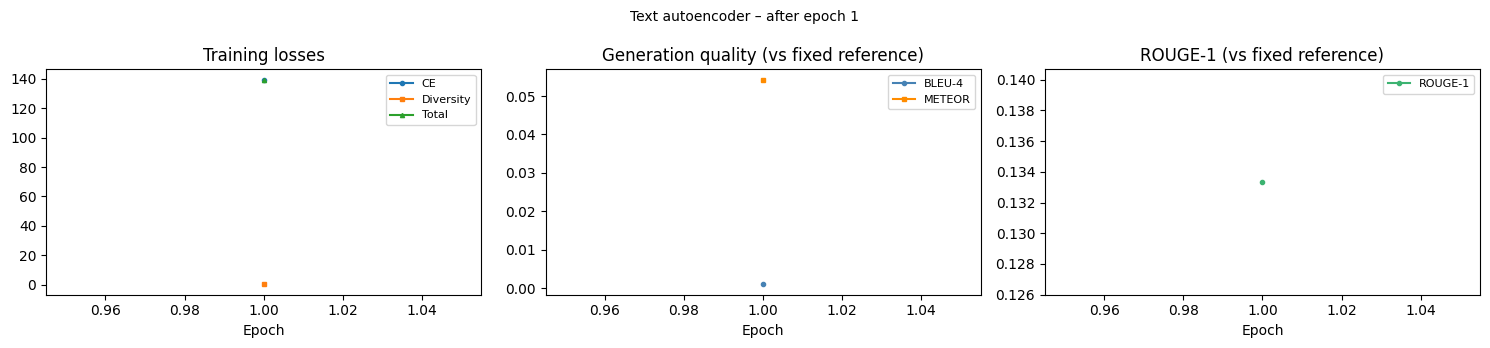

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 1
  Checkpoint saved  ✓ new best  (best=139.55281)



Epoch 2/70: 100%|██████████| 222/222 [02:15<00:00,  1.63it/s, ce=30.6570, div=0.1262, enc_lr=3.57e-06, dec_lr=3.57e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 2/70 complete
  CE loss      : 36.02203
  Diversity    : 0.12795  (→ 0 means encoder reps are already diverse)
  Total loss   : 36.04123
──────────────────────────────────────────────────────────────────────

  EPOCH 2 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The tension in the tension in the tension. The tension in the room, and the background background background background background background background background background background backgroun

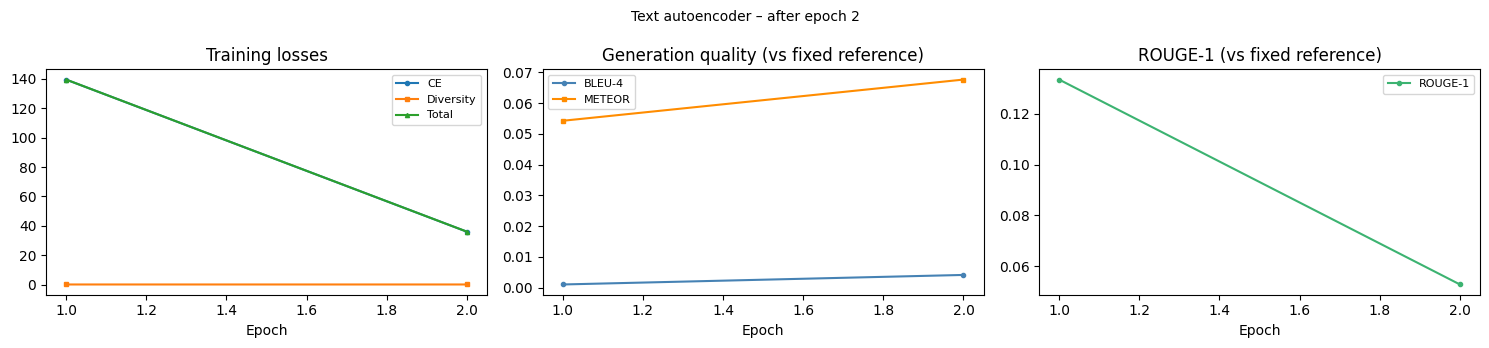

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 2
  Checkpoint saved  ✓ new best  (best=36.04123)



Epoch 3/70: 100%|██████████| 222/222 [02:35<00:00,  1.43it/s, ce=23.1448, div=0.0899, enc_lr=5.36e-06, dec_lr=5.36e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 3/70 complete
  CE loss      : 27.14325
  Diversity    : 0.10928  (→ 0 means encoder reps are already diverse)
  Total loss   : 27.15964
──────────────────────────────────────────────────────────────────────

  EPOCH 3 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The scene scene scene scene scene scene scene scene scene scene scene as the room, the situation. The tension in the situation. The tension in the background, the background, the situation. The w

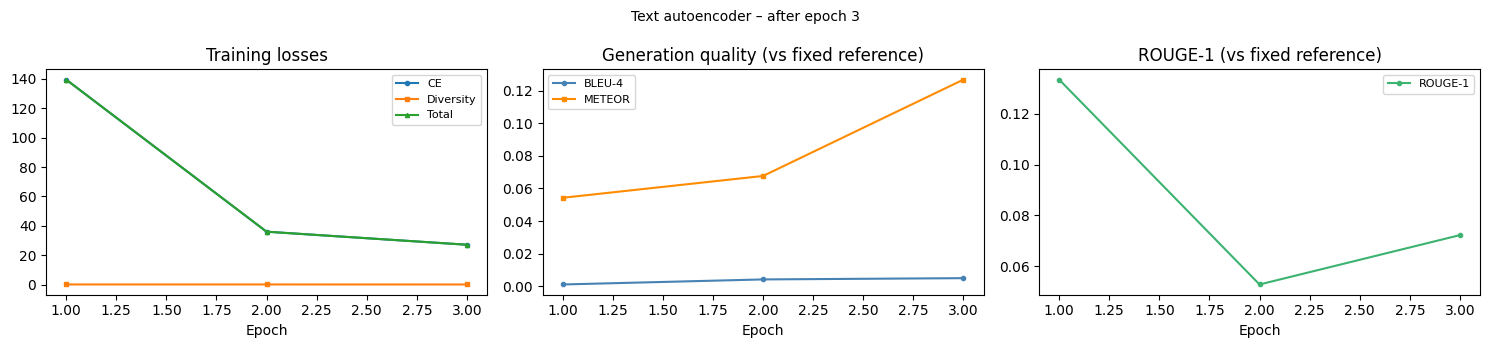

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 3
  Checkpoint saved  ✓ new best  (best=27.15964)



Epoch 4/70: 100%|██████████| 222/222 [02:34<00:00,  1.44it/s, ce=18.2034, div=0.0608, enc_lr=7.14e-06, dec_lr=7.14e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 4/70 complete
  CE loss      : 20.81815
  Diversity    : 0.07065  (→ 0 means encoder reps are already diverse)
  Total loss   : 20.82874
──────────────────────────────────────────────────────────────────────

  EPOCH 4 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The tension reached a room was a room was a room was a room was a room. The room was a room was a sense of the room was a sense of the room, her eyes. The tension in the room was a sense of the r

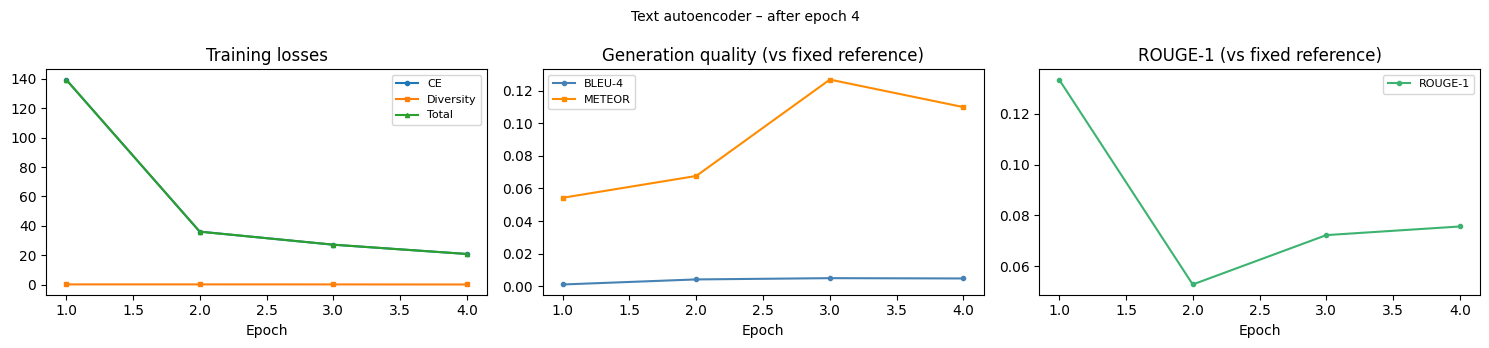

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 4
  Checkpoint saved  ✓ new best  (best=20.82874)



Epoch 5/70: 100%|██████████| 222/222 [02:35<00:00,  1.42it/s, ce=14.3192, div=0.0160, enc_lr=8.93e-06, dec_lr=8.93e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 5/70 complete
  CE loss      : 16.10302
  Diversity    : 0.03031  (→ 0 means encoder reps are already diverse)
  Total loss   : 16.10756
──────────────────────────────────────────────────────────────────────

  EPOCH 5 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The tension reached a the room was a the room, the room. The room was a sense of the tension in the background seemed to the room was a sense of the room was a sense of the situation. The room wa

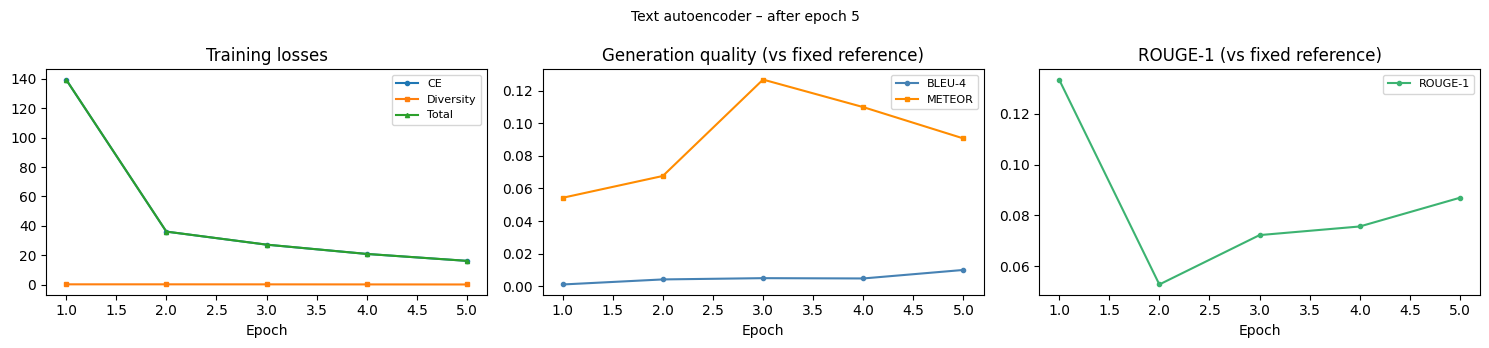

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 5
  Checkpoint saved  ✓ new best  (best=16.10756)



Epoch 6/70: 100%|██████████| 222/222 [03:01<00:00,  1.22it/s, ce=12.3859, div=0.0020, enc_lr=1.00e-05, dec_lr=1.00e-04]



──────────────────────────────────────────────────────────────────────
  Epoch 6/70 complete
  CE loss      : 13.09845
  Diversity    : 0.00746  (→ 0 means encoder reps are already diverse)
  Total loss   : 13.09957
──────────────────────────────────────────────────────────────────────

  EPOCH 6 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The scene shifted to the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the th

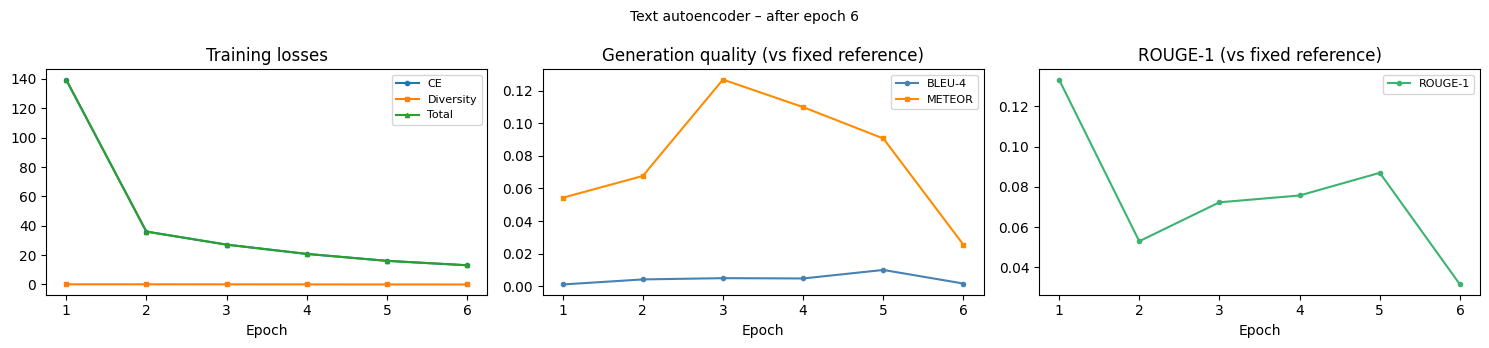

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 6
  Checkpoint saved  ✓ new best  (best=13.09957)



Epoch 7/70: 100%|██████████| 222/222 [02:51<00:00,  1.30it/s, ce=10.3857, div=0.0001, enc_lr=9.99e-06, dec_lr=9.99e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 7/70 complete
  CE loss      : 11.36164
  Diversity    : 0.00098  (→ 0 means encoder reps are already diverse)
  Total loss   : 11.36179
──────────────────────────────────────────────────────────────────────

  EPOCH 7 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The tension reached its peak as the tension in the background, the background, the background, the background, the background, the background, the background, the background, the background, the 

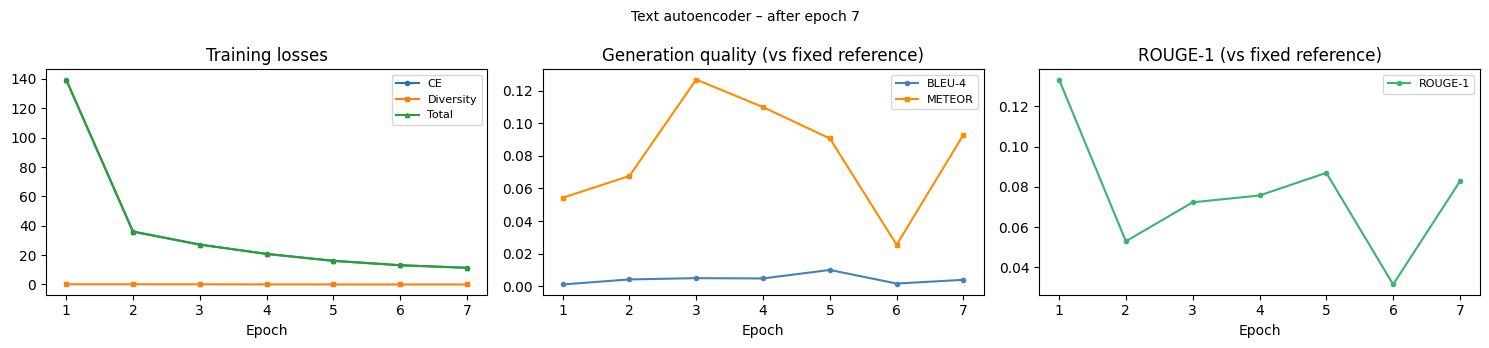

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 7
  Checkpoint saved  ✓ new best  (best=11.36179)



Epoch 8/70: 100%|██████████| 222/222 [02:45<00:00,  1.34it/s, ce=9.1275, div=0.0000, enc_lr=9.97e-06, dec_lr=9.97e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 8/70 complete
  CE loss      : 10.31234
  Diversity    : 0.00013  (→ 0 means encoder reps are already diverse)
  Total loss   : 10.31236
──────────────────────────────────────────────────────────────────────

  EPOCH 8 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  As the scene, the the the the the wall, the wall, the wall. The wall, a symbol of the tension in the background, a symbol of the background, a place of the background, a place of the background, 

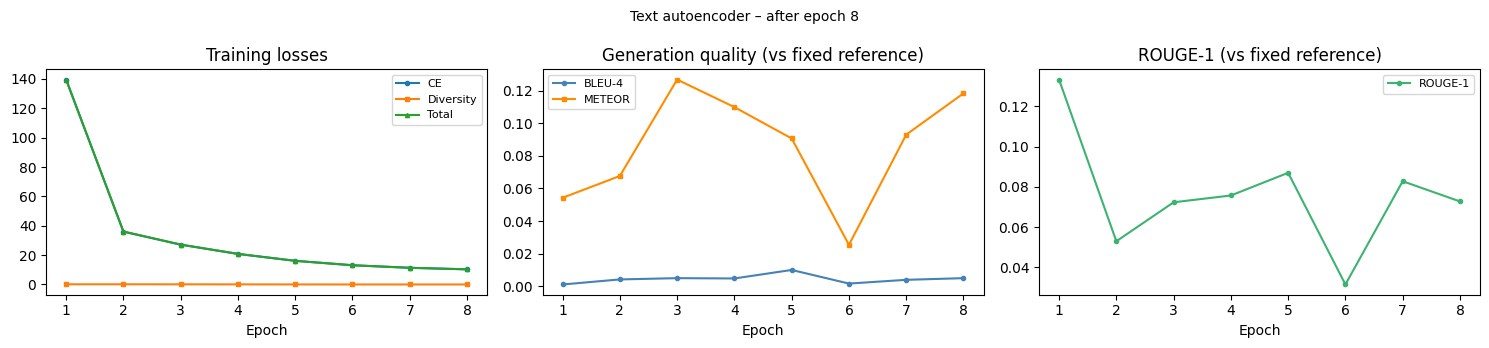

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 8
  Checkpoint saved  ✓ new best  (best=10.31236)



Epoch 9/70: 100%|██████████| 222/222 [02:43<00:00,  1.36it/s, ce=9.4293, div=0.0000, enc_lr=9.93e-06, dec_lr=9.93e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 9/70 complete
  CE loss      : 9.58600
  Diversity    : 0.00001  (→ 0 means encoder reps are already diverse)
  Total loss   : 9.58600
──────────────────────────────────────────────────────────────────────

  EPOCH 9 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The tension escalated as the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the 

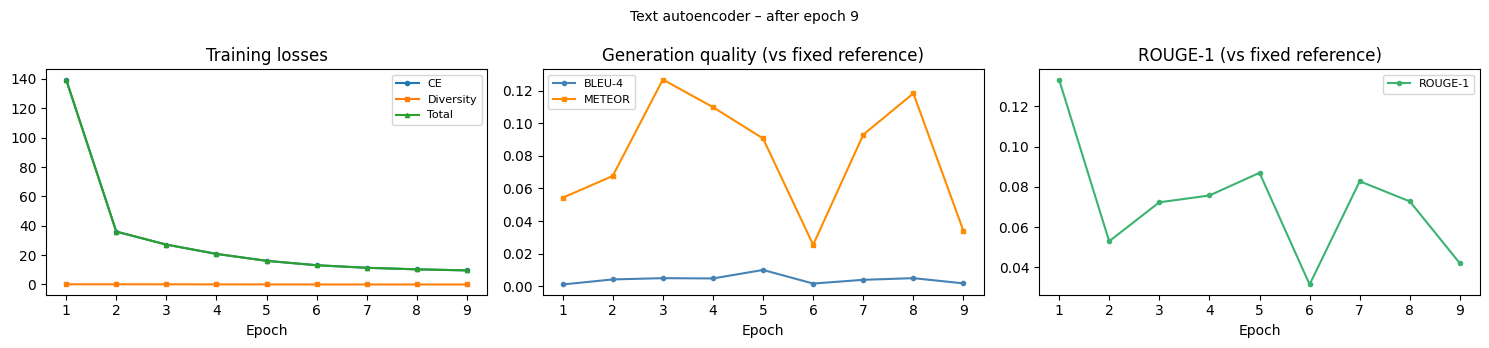

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 9
  Checkpoint saved  ✓ new best  (best=9.58600)



Epoch 10/70: 100%|██████████| 222/222 [02:39<00:00,  1.40it/s, ce=9.1012, div=0.0000, enc_lr=9.89e-06, dec_lr=9.89e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 10/70 complete
  CE loss      : 9.08604
  Diversity    : 0.00000  (→ 0 means encoder reps are already diverse)
  Total loss   : 9.08604
──────────────────────────────────────────────────────────────────────

  EPOCH 10 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The scene shifted to the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the th

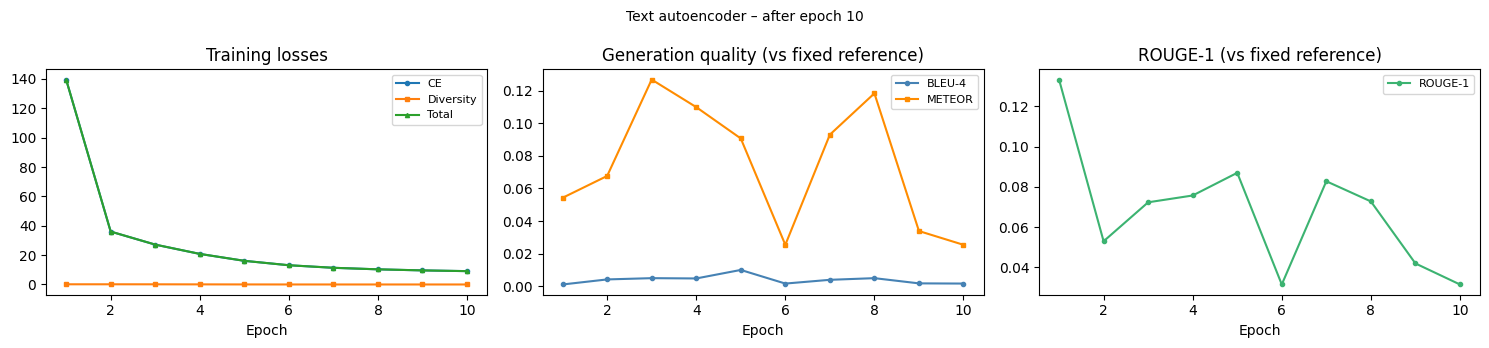

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 10
  Checkpoint saved  ✓ new best  (best=9.08604)



Epoch 11/70: 100%|██████████| 222/222 [02:40<00:00,  1.39it/s, ce=8.4039, div=0.0000, enc_lr=9.83e-06, dec_lr=9.83e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 11/70 complete
  CE loss      : 8.67815
  Diversity    : 0.00000  (→ 0 means encoder reps are already diverse)
  Total loss   : 8.67815
──────────────────────────────────────────────────────────────────────

  EPOCH 11 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The tension in the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the 

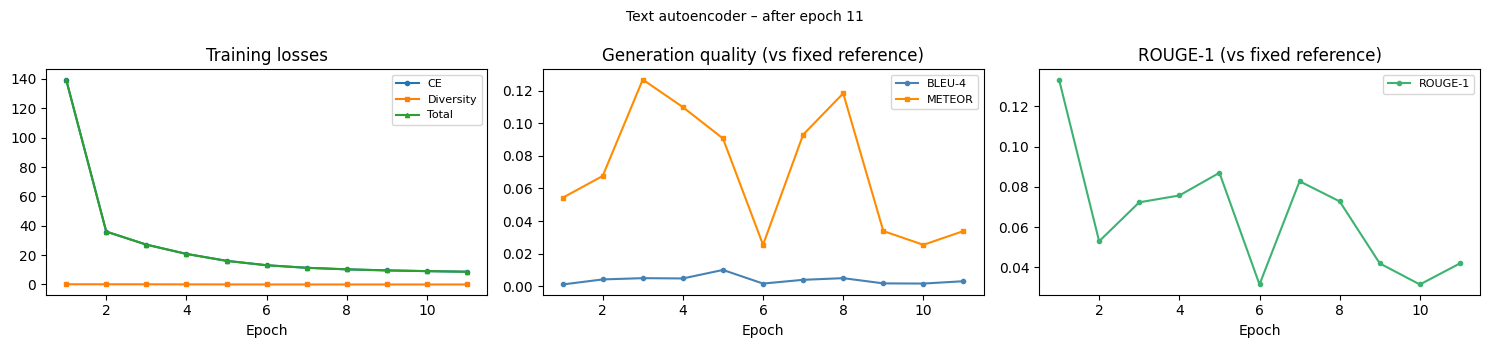

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 11
  Checkpoint saved  ✓ new best  (best=8.67815)



Epoch 12/70: 100%|██████████| 222/222 [02:44<00:00,  1.35it/s, ce=8.3392, div=0.0000, enc_lr=9.76e-06, dec_lr=9.76e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 12/70 complete
  CE loss      : 8.35121
  Diversity    : 0.00000  (→ 0 means encoder reps are already diverse)
  Total loss   : 8.35121
──────────────────────────────────────────────────────────────────────

  EPOCH 12 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The scene shifted to the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the th

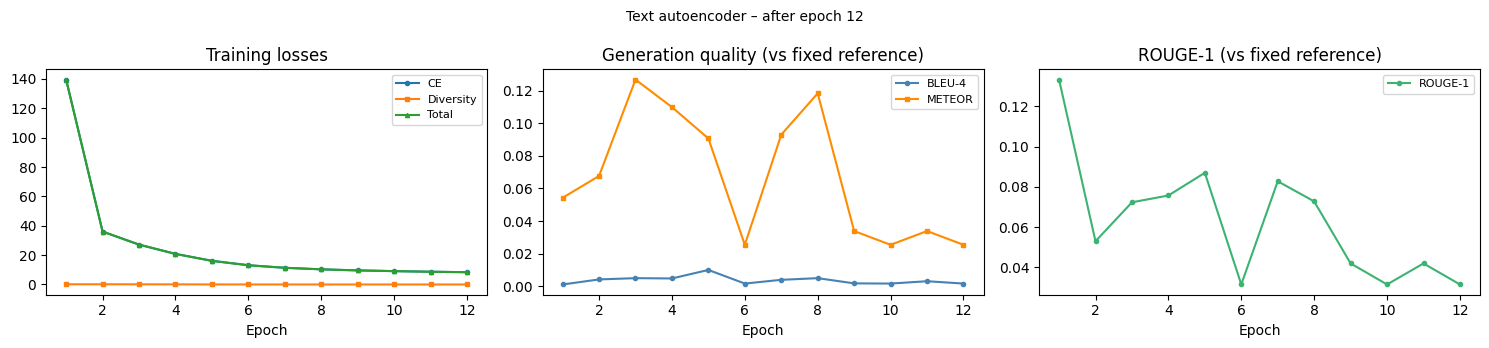

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 12
  Checkpoint saved  ✓ new best  (best=8.35121)



Epoch 13/70: 100%|██████████| 222/222 [02:44<00:00,  1.35it/s, ce=7.6550, div=0.0000, enc_lr=9.68e-06, dec_lr=9.68e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 13/70 complete
  CE loss      : 7.99757
  Diversity    : 0.00000  (→ 0 means encoder reps are already diverse)
  Total loss   : 7.99757
──────────────────────────────────────────────────────────────────────

  EPOCH 13 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The tension in the forest was palpable as the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the t

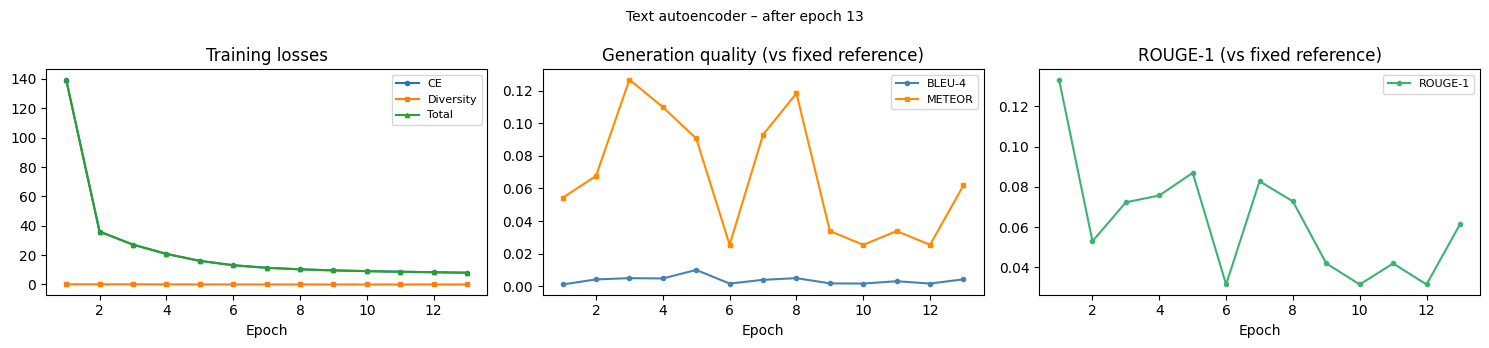

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 13
  Checkpoint saved  ✓ new best  (best=7.99757)



Epoch 14/70: 100%|██████████| 222/222 [02:43<00:00,  1.36it/s, ce=7.8626, div=0.0000, enc_lr=9.59e-06, dec_lr=9.59e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 14/70 complete
  CE loss      : 7.73151
  Diversity    : 0.00000  (→ 0 means encoder reps are already diverse)
  Total loss   : 7.73151
──────────────────────────────────────────────────────────────────────

  EPOCH 14 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The tension in the same same same same same same same same same same same same same same same same same same same same same same same same same same same same same same same same same same same s

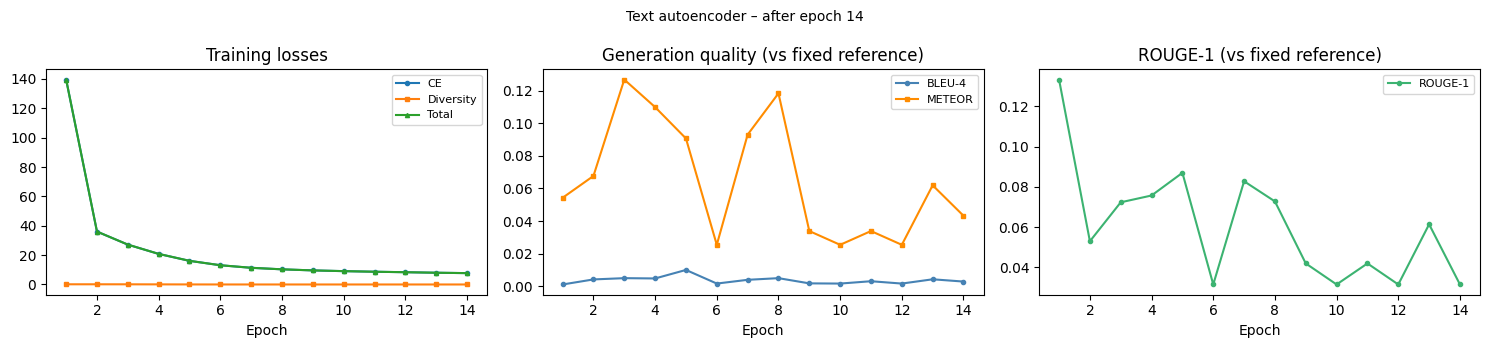

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 14
  Checkpoint saved  ✓ new best  (best=7.73151)



Epoch 15/70: 100%|██████████| 222/222 [02:44<00:00,  1.35it/s, ce=7.1182, div=0.0000, enc_lr=9.48e-06, dec_lr=9.48e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 15/70 complete
  CE loss      : 7.40348
  Diversity    : 0.00000  (→ 0 means encoder reps are already diverse)
  Total loss   : 7.40348
──────────────────────────────────────────────────────────────────────

  EPOCH 15 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The tension in the forest, the the the the the distance, and the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the th

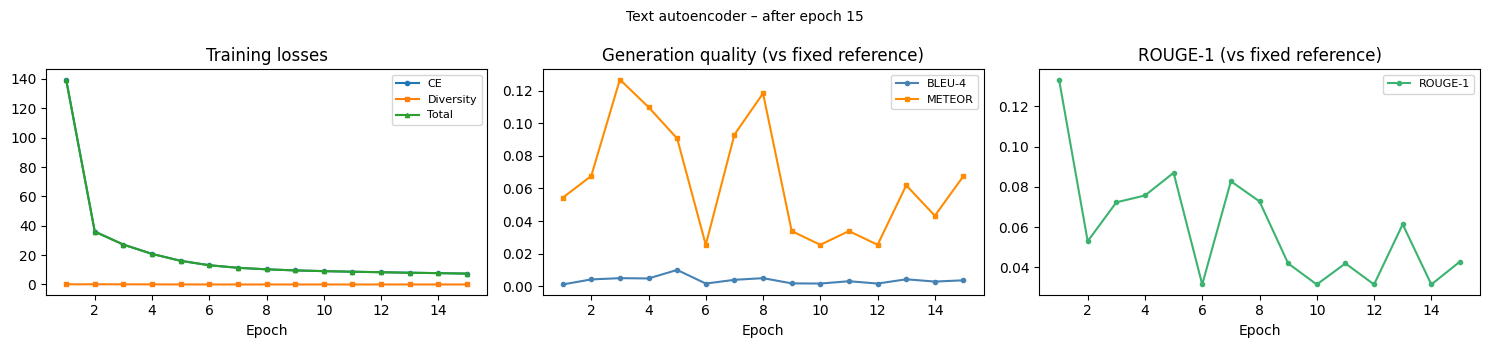

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 15
  Checkpoint saved  ✓ new best  (best=7.40348)



Epoch 16/70: 100%|██████████| 222/222 [02:46<00:00,  1.33it/s, ce=6.9188, div=0.0000, enc_lr=9.37e-06, dec_lr=9.37e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 16/70 complete
  CE loss      : 7.16006
  Diversity    : 0.00000  (→ 0 means encoder reps are already diverse)
  Total loss   : 7.16006
──────────────────────────────────────────────────────────────────────

  EPOCH 16 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The final was the final moments of the, the the the the final moments of the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the th

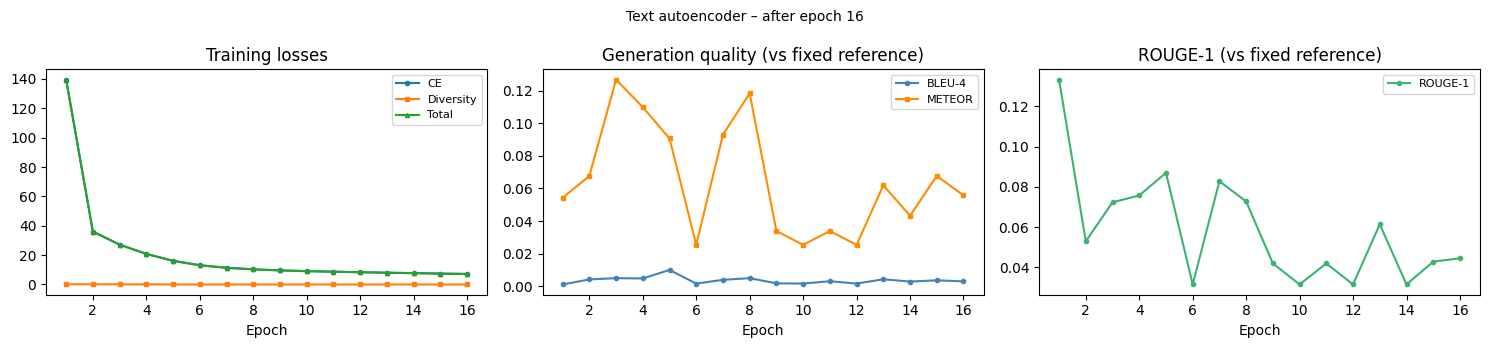

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 16
  Checkpoint saved  ✓ new best  (best=7.16006)



Epoch 17/70: 100%|██████████| 222/222 [02:43<00:00,  1.35it/s, ce=6.7621, div=0.0000, enc_lr=9.25e-06, dec_lr=9.25e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 17/70 complete
  CE loss      : 6.84606
  Diversity    : 0.00000  (→ 0 means encoder reps are already diverse)
  Total loss   : 6.84606
──────────────────────────────────────────────────────────────────────

  EPOCH 17 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The final moments of the forest, who was thick with the forest, and the forest. The forest, and the forest of the forest that danced across the others of the others, and the others.

  Scores vs 

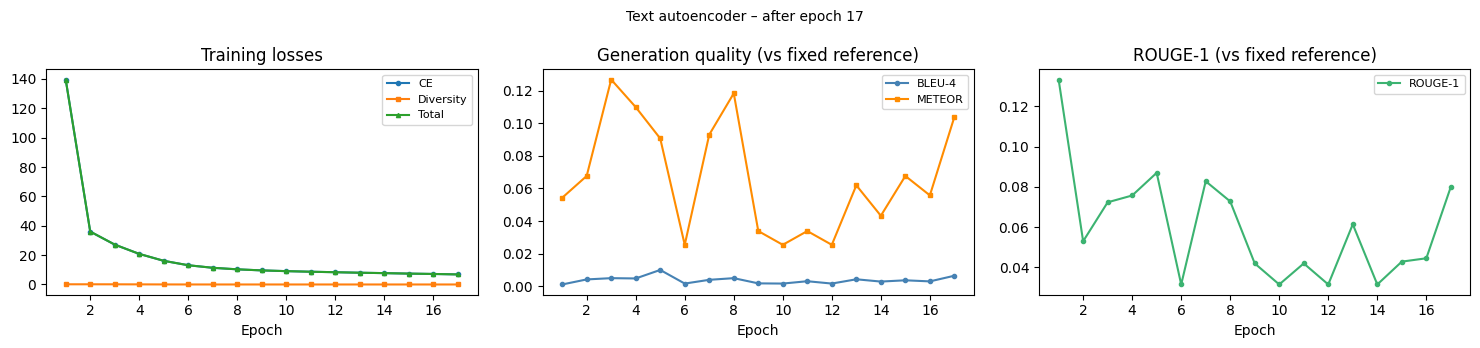

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 17
  Checkpoint saved  ✓ new best  (best=6.84606)



Epoch 18/70: 100%|██████████| 222/222 [02:44<00:00,  1.35it/s, ce=6.3238, div=0.0000, enc_lr=9.11e-06, dec_lr=9.11e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 18/70 complete
  CE loss      : 6.56432
  Diversity    : 0.00000  (→ 0 means encoder reps are already diverse)
  Total loss   : 6.56432
──────────────────────────────────────────────────────────────────────

  EPOCH 18 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The final was the forest of the forest, the forest and the forest. A and the forest, the the the forest that danced across the the the the the the the city. The forest of the the the the city, an

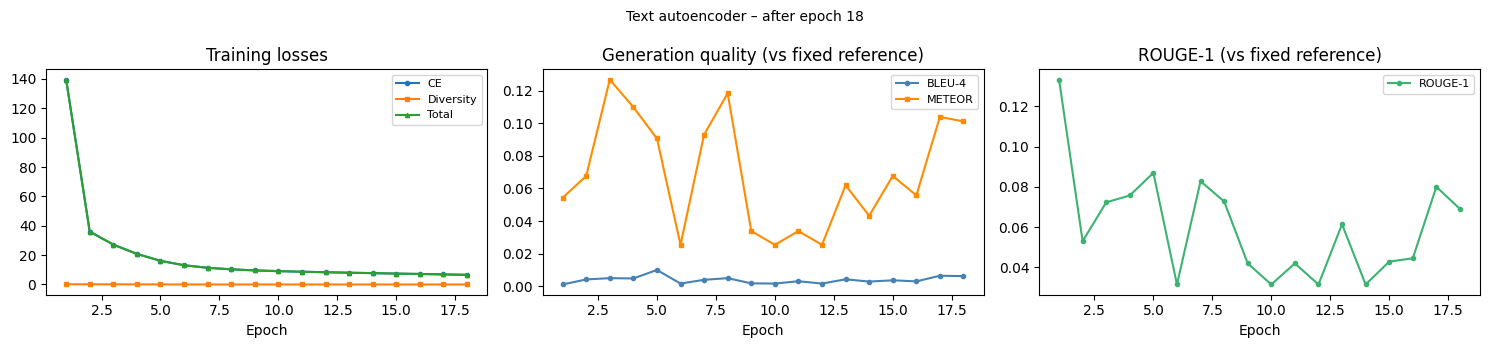

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 18
  Checkpoint saved  ✓ new best  (best=6.56432)



Epoch 19/70: 100%|██████████| 222/222 [02:47<00:00,  1.32it/s, ce=6.1264, div=0.0000, enc_lr=8.97e-06, dec_lr=8.97e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 19/70 complete
  CE loss      : 6.30384
  Diversity    : 0.00000  (→ 0 means encoder reps are already diverse)
  Total loss   : 6.30384
──────────────────────────────────────────────────────────────────────

  EPOCH 19 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The evening was the, the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the. The forest of the the for

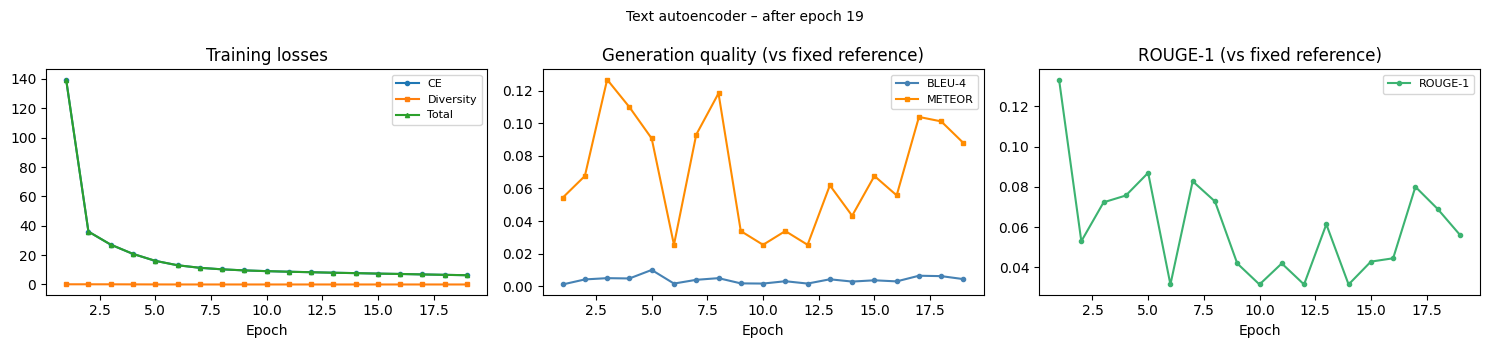

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 19
  Checkpoint saved  ✓ new best  (best=6.30384)



Epoch 20/70: 100%|██████████| 222/222 [02:45<00:00,  1.34it/s, ce=5.9972, div=0.0000, enc_lr=8.82e-06, dec_lr=8.82e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 20/70 complete
  CE loss      : 5.98341
  Diversity    : 0.00000  (→ 0 means encoder reps are already diverse)
  Total loss   : 5.98341
──────────────────────────────────────────────────────────────────────

  EPOCH 20 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was the calm and the calm and the in the serene backdrop of the, casting long shadows across the. The water, casting long shadows across the the the of the the the.

  Scores vs referen

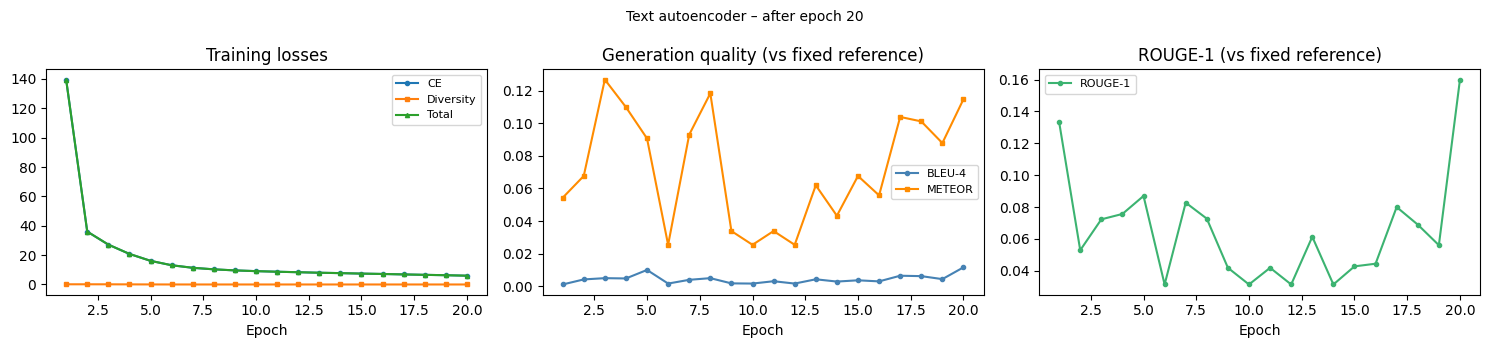

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 20
  Checkpoint saved  ✓ new best  (best=5.98341)



Epoch 21/70: 100%|██████████| 222/222 [02:44<00:00,  1.35it/s, ce=5.6280, div=0.0000, enc_lr=8.65e-06, dec_lr=8.65e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 21/70 complete
  CE loss      : 5.77671
  Diversity    : 0.00000  (→ 0 means encoder reps are already diverse)
  Total loss   : 5.77671
──────────────────────────────────────────────────────────────────────

  EPOCH 21 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was the water and sky, casting long shadows across the the soft and the the forest. The water, casting long shadows across the the the forest of the forest, and casting long shadows tha

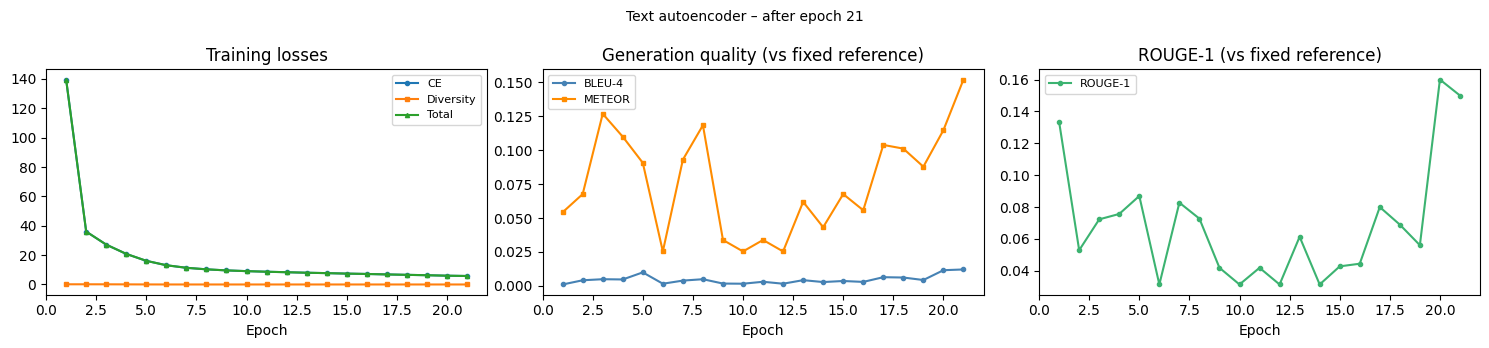

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 21
  Checkpoint saved  ✓ new best  (best=5.77671)



Epoch 22/70: 100%|██████████| 222/222 [02:50<00:00,  1.30it/s, ce=5.1697, div=0.0000, enc_lr=8.48e-06, dec_lr=8.48e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 22/70 complete
  CE loss      : 5.51120
  Diversity    : 0.00001  (→ 0 means encoder reps are already diverse)
  Total loss   : 5.51121
──────────────────────────────────────────────────────────────────────

  EPOCH 22 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was the water and the sun in the serene backdrop, the shadows. The water, casting shadows that danced across the surface, and casting shadows across the surface. The water of the surfac

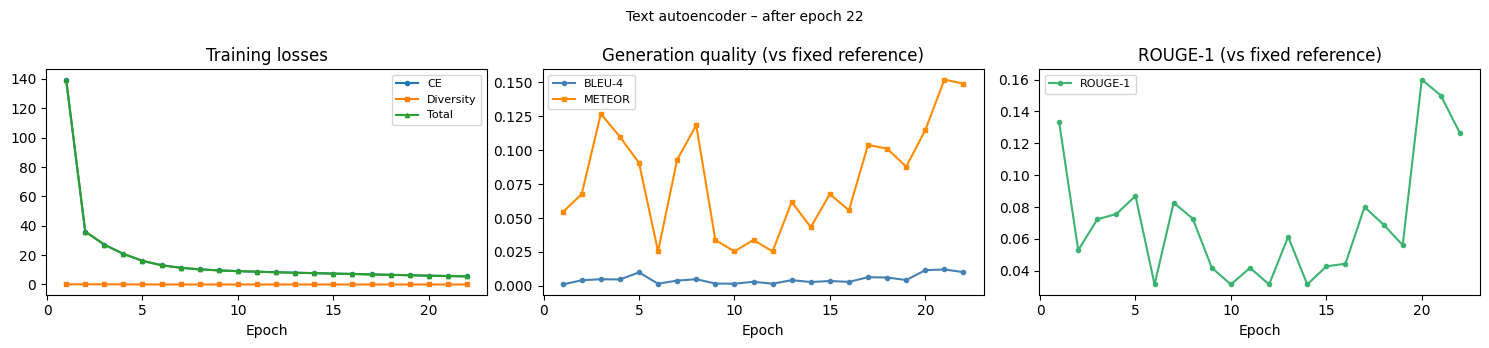

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 22
  Checkpoint saved  ✓ new best  (best=5.51121)



Epoch 23/70: 100%|██████████| 222/222 [02:47<00:00,  1.33it/s, ce=5.5427, div=0.0005, enc_lr=8.30e-06, dec_lr=8.30e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 23/70 complete
  CE loss      : 5.34250
  Diversity    : 0.00004  (→ 0 means encoder reps are already diverse)
  Total loss   : 5.34251
──────────────────────────────────────────────────────────────────────

  EPOCH 23 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was still and bright and bright and bright, casting eerie, casting eerie glow of the surface, casting eerie glow of the water. The water, and casting eerie glow of bright daylight the w

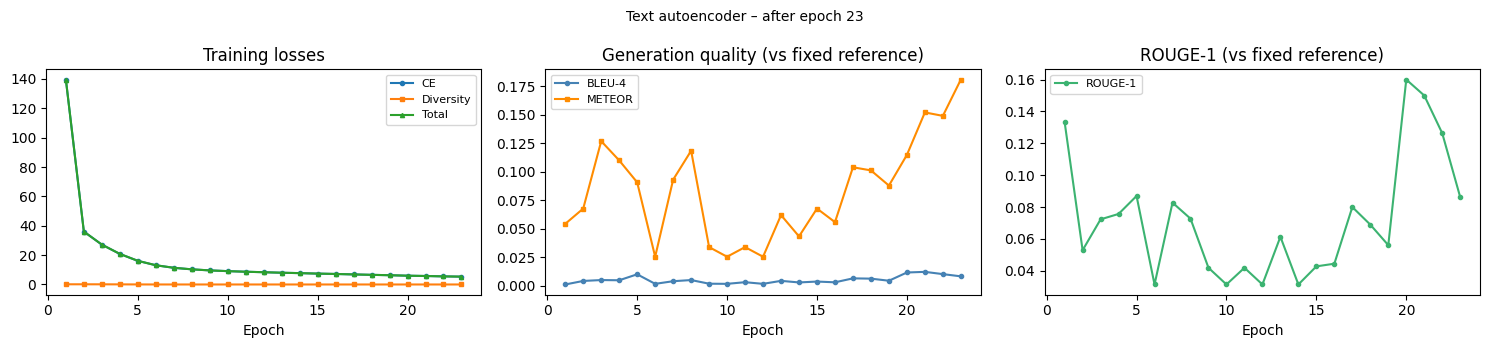

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 23
  Checkpoint saved  ✓ new best  (best=5.34251)



Epoch 24/70: 100%|██████████| 222/222 [02:45<00:00,  1.34it/s, ce=5.4616, div=0.0000, enc_lr=8.12e-06, dec_lr=8.12e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 24/70 complete
  CE loss      : 5.18057
  Diversity    : 0.00006  (→ 0 means encoder reps are already diverse)
  Total loss   : 5.18058
──────────────────────────────────────────────────────────────────────

  EPOCH 24 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright, casting shadows across the water in the cool cool cool cool cool cool cool. A, casting shadows of bright, and casting shadows across the cool cool cool,

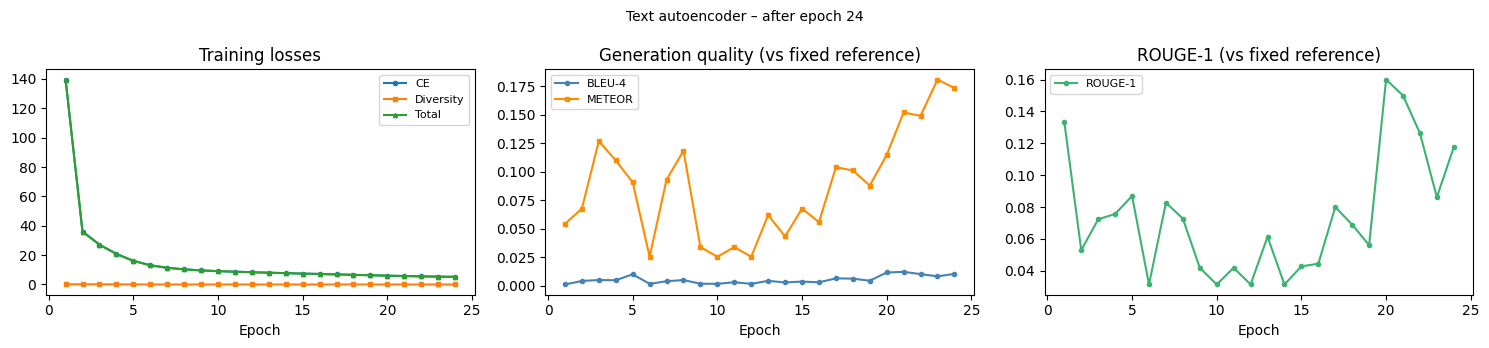

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 24
  Checkpoint saved  ✓ new best  (best=5.18058)



Epoch 25/70: 100%|██████████| 222/222 [02:46<00:00,  1.34it/s, ce=5.0297, div=0.0001, enc_lr=7.92e-06, dec_lr=7.92e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 25/70 complete
  CE loss      : 5.00396
  Diversity    : 0.00012  (→ 0 means encoder reps are already diverse)
  Total loss   : 5.00397
──────────────────────────────────────────────────────────────────────

  EPOCH 25 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was the water and bright and bright and bright daylight in the water. A, the water now it through the water, and casting shadows across the water of bright, and casting eerie shadows th

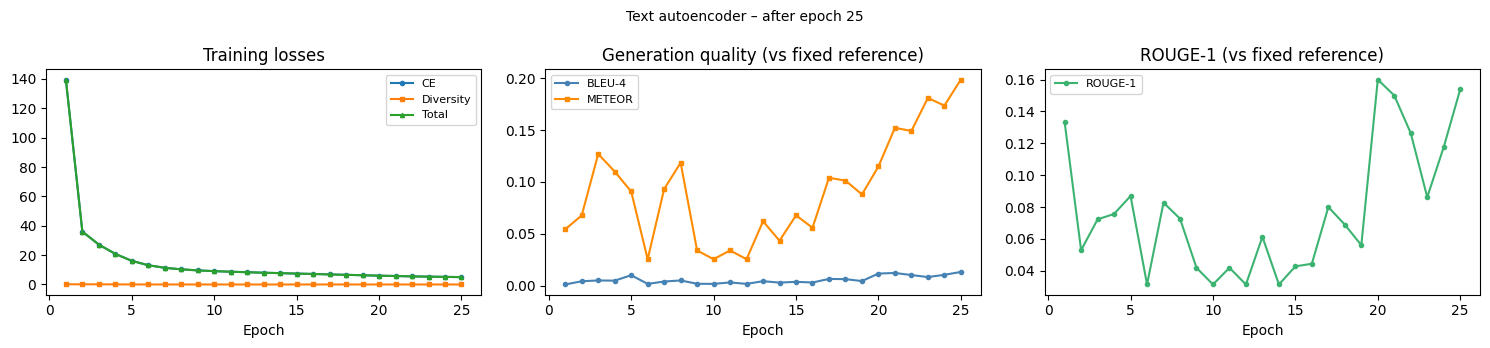

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 25
  Checkpoint saved  ✓ new best  (best=5.00397)



Epoch 26/70: 100%|██████████| 222/222 [02:45<00:00,  1.34it/s, ce=4.4138, div=0.0004, enc_lr=7.72e-06, dec_lr=7.72e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 26/70 complete
  CE loss      : 4.86081
  Diversity    : 0.00020  (→ 0 means encoder reps are already diverse)
  Total loss   : 4.86084
──────────────────────────────────────────────────────────────────────

  EPOCH 26 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright and bright daylight in the dark, casting shadows across the cool. A, the cool surface of the water, and casting shadows that danced across the cool, and 

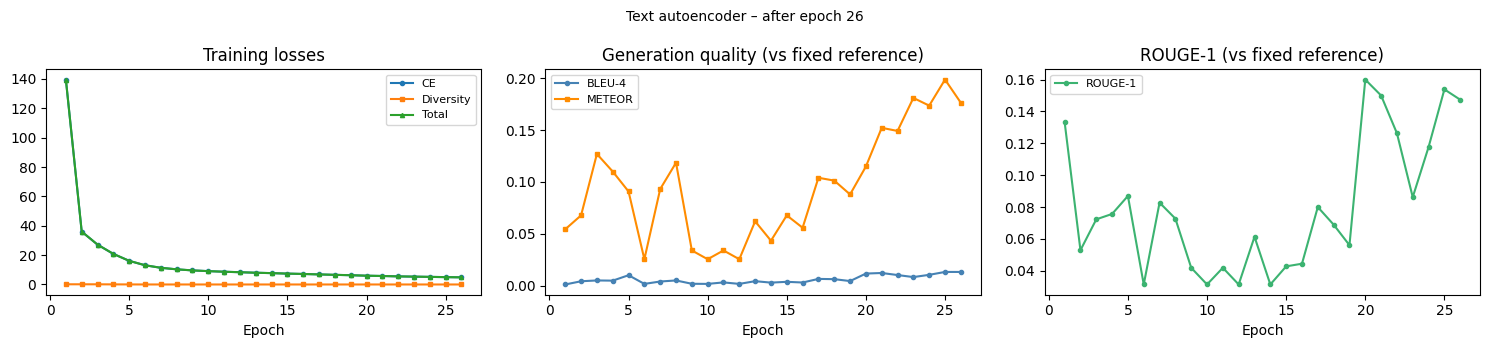

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 26
  Checkpoint saved  ✓ new best  (best=4.86084)



Epoch 27/70: 100%|██████████| 222/222 [02:48<00:00,  1.32it/s, ce=5.0243, div=0.0001, enc_lr=7.51e-06, dec_lr=7.51e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 27/70 complete
  CE loss      : 4.71740
  Diversity    : 0.00030  (→ 0 means encoder reps are already diverse)
  Total loss   : 4.71745
──────────────────────────────────────────────────────────────────────

  EPOCH 27 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright, casting eerie. A, light in the surface, casting shadows across the cool surface, and casting eerie. The water, and casting eerie shadows across the wate

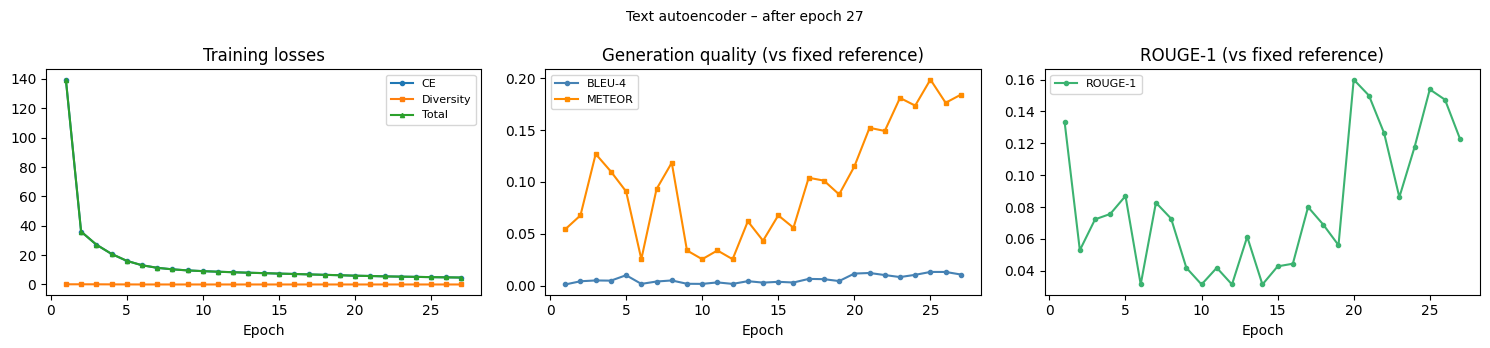

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 27
  Checkpoint saved  ✓ new best  (best=4.71745)



Epoch 28/70: 100%|██████████| 222/222 [02:45<00:00,  1.34it/s, ce=4.8723, div=0.0006, enc_lr=7.30e-06, dec_lr=7.30e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 28/70 complete
  CE loss      : 4.58745
  Diversity    : 0.00045  (→ 0 means encoder reps are already diverse)
  Total loss   : 4.58751
──────────────────────────────────────────────────────────────────────

  EPOCH 28 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright and bright daylight in the harsh over the harsh under the harsh under the. A, the rocky terrain of the rocky terrain of bright, and casting shadows that 

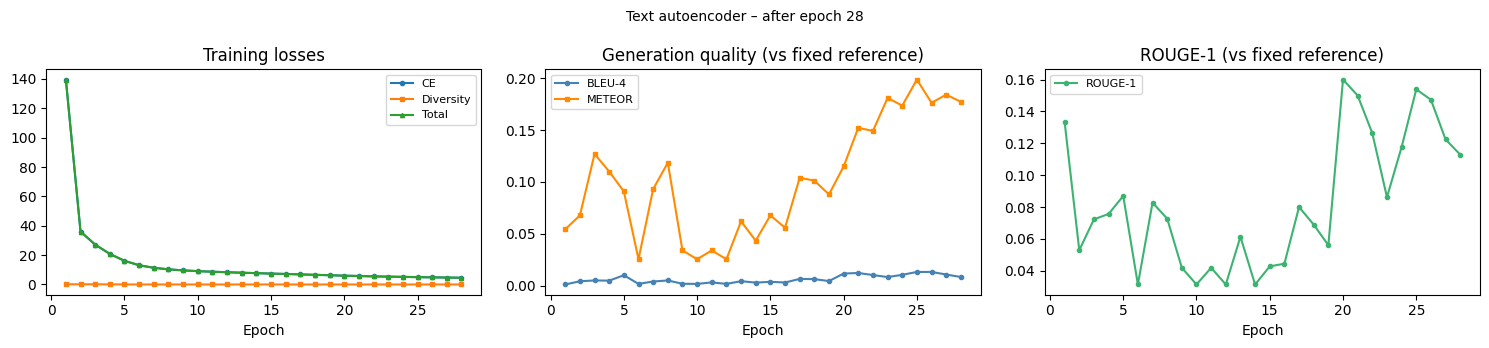

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 28
  Checkpoint saved  ✓ new best  (best=4.58751)



Epoch 29/70: 100%|██████████| 222/222 [02:45<00:00,  1.34it/s, ce=4.9524, div=0.0001, enc_lr=7.08e-06, dec_lr=7.08e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 29/70 complete
  CE loss      : 4.46477
  Diversity    : 0.00070  (→ 0 means encoder reps are already diverse)
  Total loss   : 4.46487
──────────────────────────────────────────────────────────────────────

  EPOCH 29 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright daylight in the cool, casting shadows across the cool. A, light of the cool surface, the cool under the cool, and glow of bright, and casting shadows tha

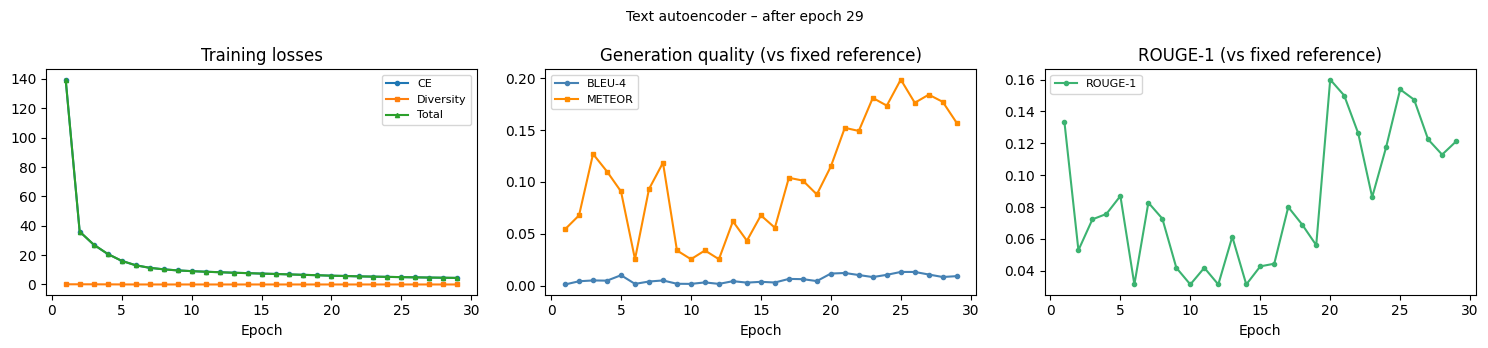

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 29
  Checkpoint saved  ✓ new best  (best=4.46487)



Epoch 30/70: 100%|██████████| 222/222 [02:47<00:00,  1.33it/s, ce=4.4817, div=0.0023, enc_lr=6.86e-06, dec_lr=6.86e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 30/70 complete
  CE loss      : 4.35438
  Diversity    : 0.00079  (→ 0 means encoder reps are already diverse)
  Total loss   : 4.35450
──────────────────────────────────────────────────────────────────────

  EPOCH 30 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright and bright daylight, light of the cool surface of the cool surface, casting shadows across the cool. A, light, light, and glow of bright, and glow of bri

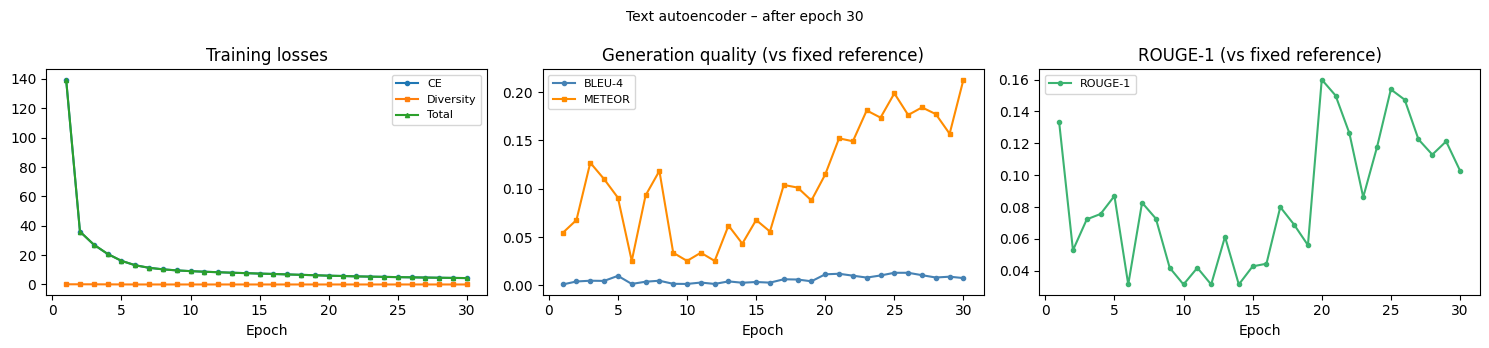

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 30
  Checkpoint saved  ✓ new best  (best=4.35450)



Epoch 31/70: 100%|██████████| 222/222 [02:49<00:00,  1.31it/s, ce=4.3560, div=0.0007, enc_lr=6.63e-06, dec_lr=6.63e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 31/70 complete
  CE loss      : 4.24294
  Diversity    : 0.00117  (→ 0 means encoder reps are already diverse)
  Total loss   : 4.24312
──────────────────────────────────────────────────────────────────────

  EPOCH 31 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright and bright, light in the harsh, casting shadows across the harsh, and casting shadows across the harsh, and casting shadows across the harsh, and casting

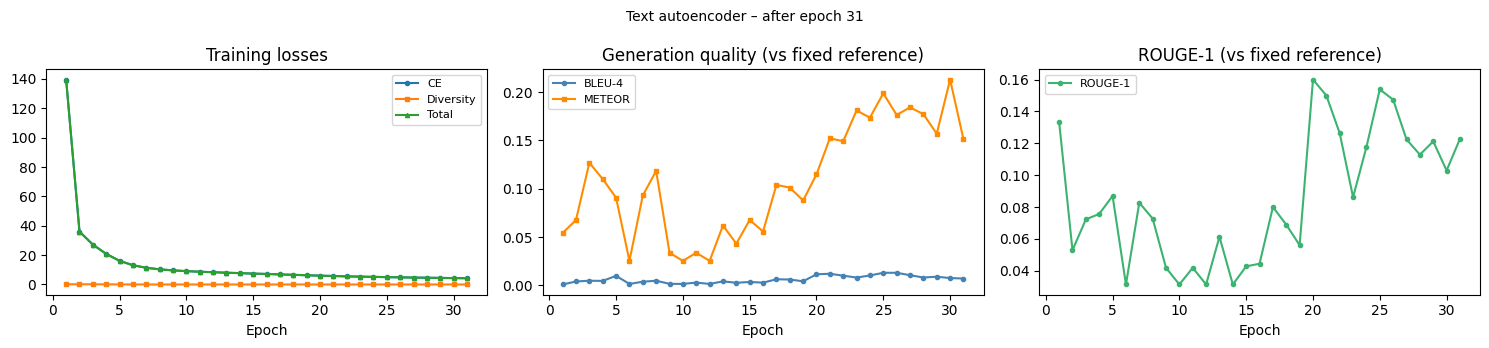

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 31
  Checkpoint saved  ✓ new best  (best=4.24312)



Epoch 32/70: 100%|██████████| 222/222 [02:46<00:00,  1.33it/s, ce=4.0181, div=0.0028, enc_lr=6.40e-06, dec_lr=6.40e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 32/70 complete
  CE loss      : 4.15067
  Diversity    : 0.00159  (→ 0 means encoder reps are already diverse)
  Total loss   : 4.15090
──────────────────────────────────────────────────────────────────────

  EPOCH 32 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright daylight, casting shadows across the harsh surface of the surface. A, light, casting shadows across the surface of bright daylight, and glow of bright da

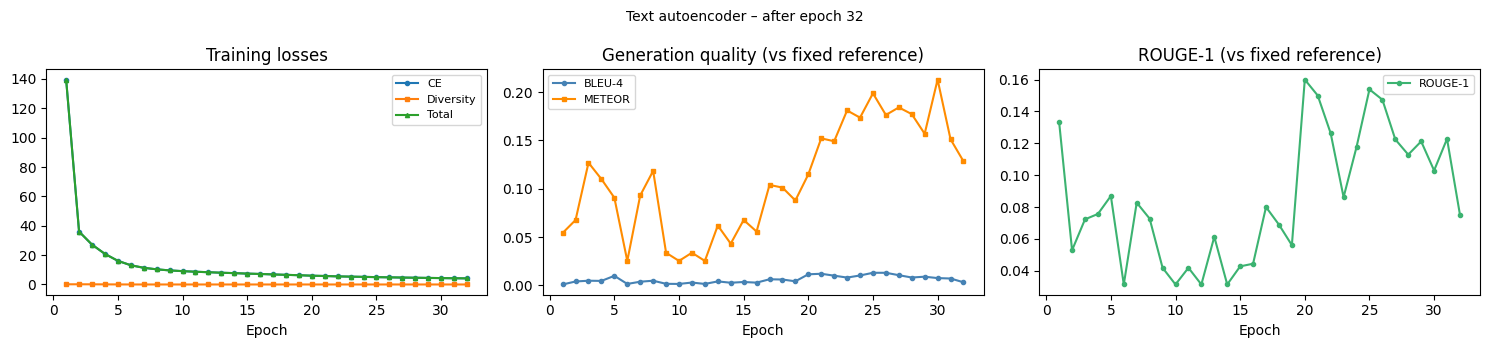

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 32
  Checkpoint saved  ✓ new best  (best=4.15090)



Epoch 33/70: 100%|██████████| 222/222 [02:52<00:00,  1.29it/s, ce=3.9128, div=0.0008, enc_lr=6.16e-06, dec_lr=6.16e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 33/70 complete
  CE loss      : 4.05762
  Diversity    : 0.00187  (→ 0 means encoder reps are already diverse)
  Total loss   : 4.05790
──────────────────────────────────────────────────────────────────────

  EPOCH 33 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright and bright daylight. A A A A, light in the harsh under the rocky terrain of the rocky terrain, and casting shadows that floor. A, casting shadows of brig

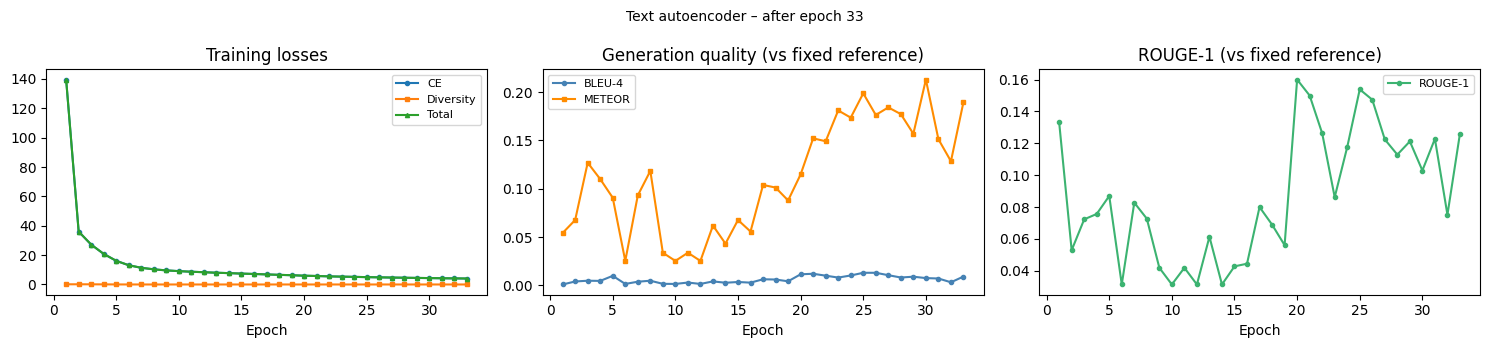

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 33
  Checkpoint saved  ✓ new best  (best=4.05790)



Epoch 34/70: 100%|██████████| 222/222 [02:50<00:00,  1.30it/s, ce=4.2094, div=0.0042, enc_lr=5.92e-06, dec_lr=5.92e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 34/70 complete
  CE loss      : 3.98267
  Diversity    : 0.00184  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.98294
──────────────────────────────────────────────────────────────────────

  EPOCH 34 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright and bright surface in the cool surface, light of the cool surface. A A now, light now through the rocky terrain of bright surface of bright, and glow of 

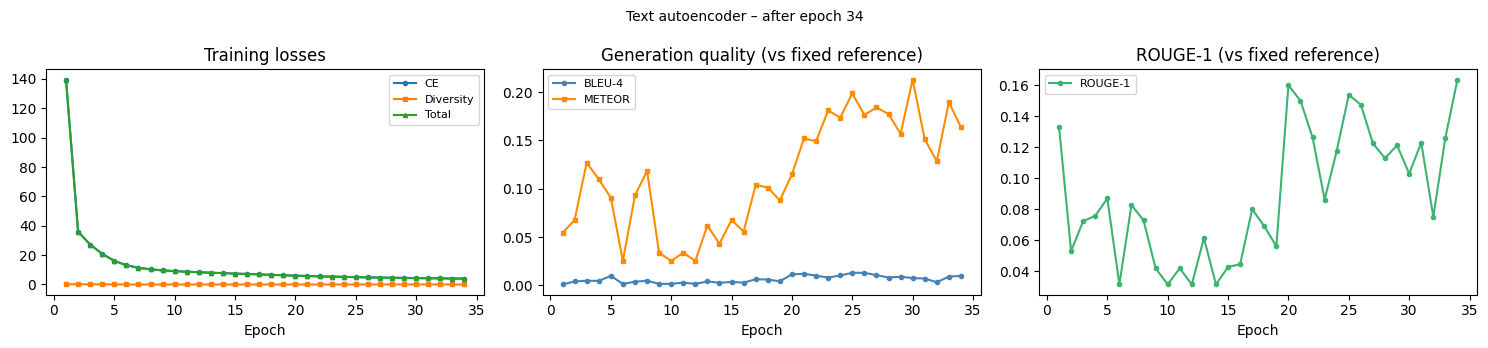

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 34
  Checkpoint saved  ✓ new best  (best=3.98294)



Epoch 35/70: 100%|██████████| 222/222 [02:50<00:00,  1.30it/s, ce=3.7046, div=0.0015, enc_lr=5.68e-06, dec_lr=5.68e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 35/70 complete
  CE loss      : 3.91125
  Diversity    : 0.00224  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.91159
──────────────────────────────────────────────────────────────────────

  EPOCH 35 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface in the cool surface, casting shadows across the cool surface. A, Jonathan now, the cool surface of bright surface, and glow of bright surface of 

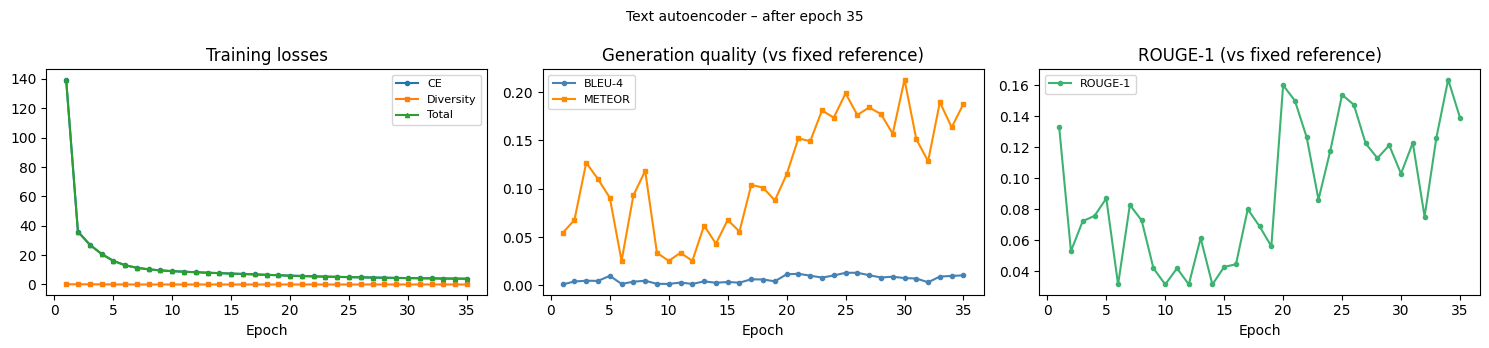

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 35
  Checkpoint saved  ✓ new best  (best=3.91159)



Epoch 36/70: 100%|██████████| 222/222 [02:51<00:00,  1.30it/s, ce=3.5158, div=0.0013, enc_lr=5.44e-06, dec_lr=5.44e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 36/70 complete
  CE loss      : 3.82900
  Diversity    : 0.00234  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.82936
──────────────────────────────────────────────────────────────────────

  EPOCH 36 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface in the cool surface, casting shadows across the rocky terrain of the river. A now, light, the rocky terrain of bright surface of bright, and glow

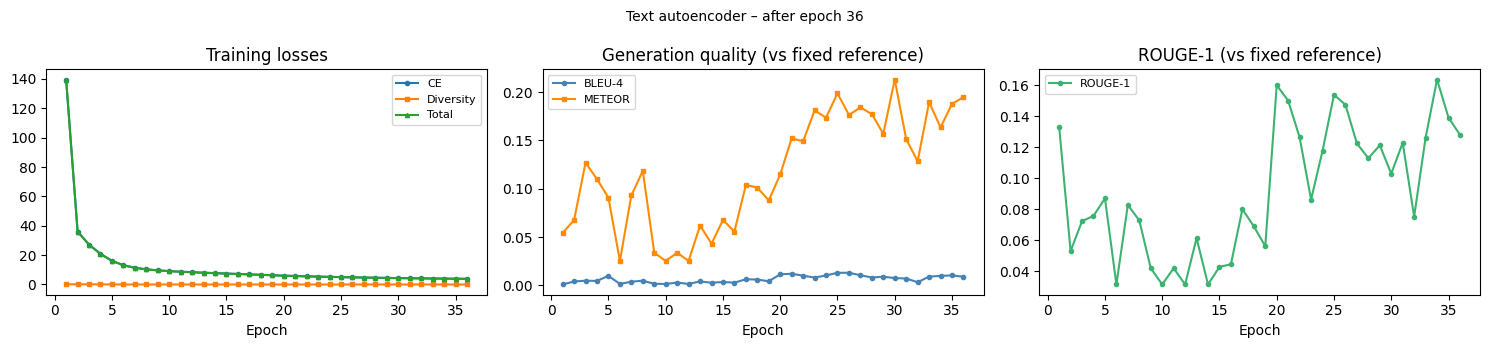

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 36
  Checkpoint saved  ✓ new best  (best=3.82936)



Epoch 37/70: 100%|██████████| 222/222 [02:58<00:00,  1.24it/s, ce=3.7719, div=0.0032, enc_lr=5.19e-06, dec_lr=5.19e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 37/70 complete
  CE loss      : 3.77983
  Diversity    : 0.00289  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.78026
──────────────────────────────────────────────────────────────────────

  EPOCH 37 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright daylight in the cool surface, light of the cool surface, casting shadows across the river of the river. A now, light, and glow of bright daylight of brig

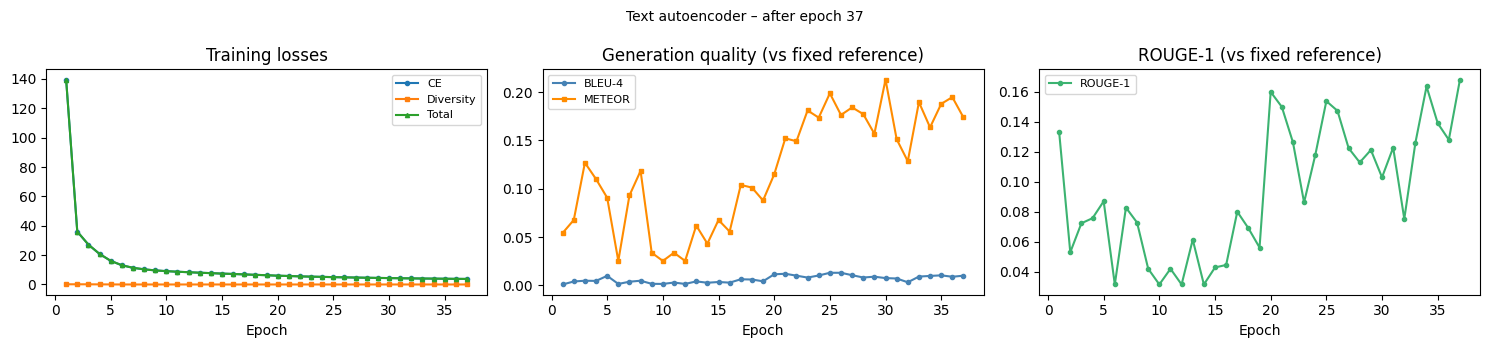

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 37
  Checkpoint saved  ✓ new best  (best=3.78026)



Epoch 38/70: 100%|██████████| 222/222 [02:53<00:00,  1.28it/s, ce=3.7230, div=0.0044, enc_lr=4.95e-06, dec_lr=4.95e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 38/70 complete
  CE loss      : 3.68984
  Diversity    : 0.00321  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.69032
──────────────────────────────────────────────────────────────────────

  EPOCH 38 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface in the cool surface, light. A A, light now through the cool surface, casting shadows across the rocky terrain of bright, and illuminated the rock

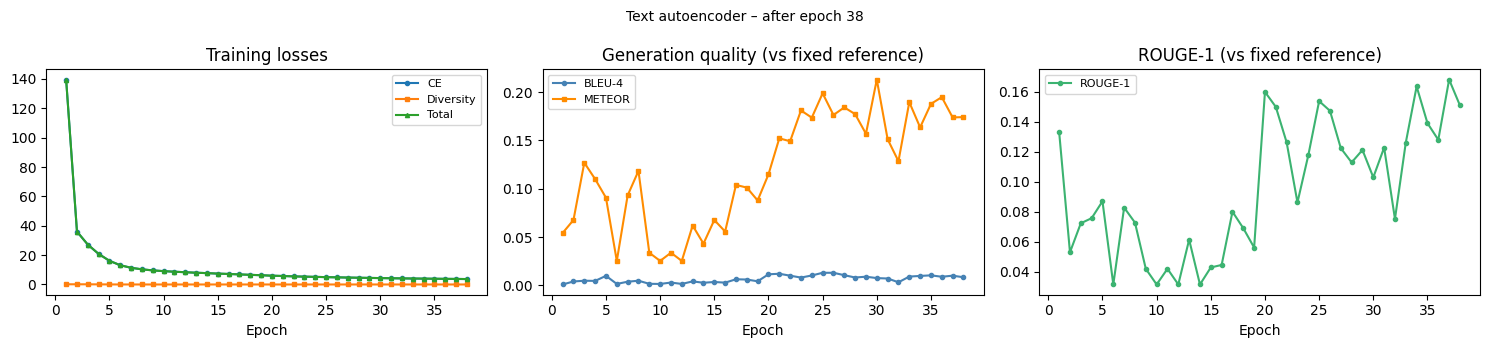

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 38
  Checkpoint saved  ✓ new best  (best=3.69032)



Epoch 39/70: 100%|██████████| 222/222 [02:54<00:00,  1.27it/s, ce=3.6076, div=0.0044, enc_lr=4.71e-06, dec_lr=4.71e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 39/70 complete
  CE loss      : 3.61857
  Diversity    : 0.00376  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.61913
──────────────────────────────────────────────────────────────────────

  EPOCH 39 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface in the cool surface, light of the cool surface. A, illuminating the cool surface, light now, casting shadows of bright surface of bright, and glo

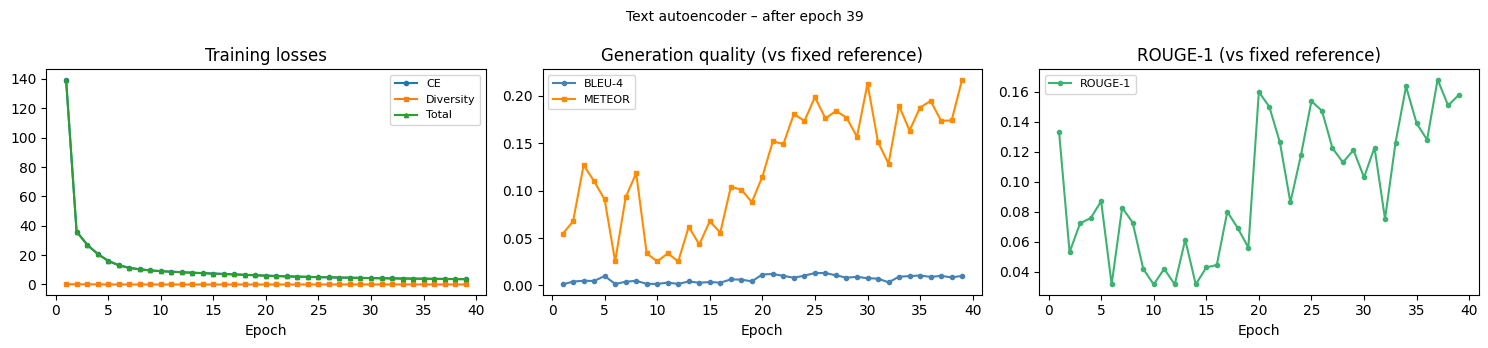

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 39
  Checkpoint saved  ✓ new best  (best=3.61913)



Epoch 40/70: 100%|██████████| 222/222 [02:51<00:00,  1.29it/s, ce=3.4120, div=0.0028, enc_lr=4.46e-06, dec_lr=4.46e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 40/70 complete
  CE loss      : 3.56085
  Diversity    : 0.00398  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.56144
──────────────────────────────────────────────────────────────────────

  EPOCH 40 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface in the cool surface, casting shadows across the cool surface of the river. A A A, light now the cool surface of bright surface, and illuminated t

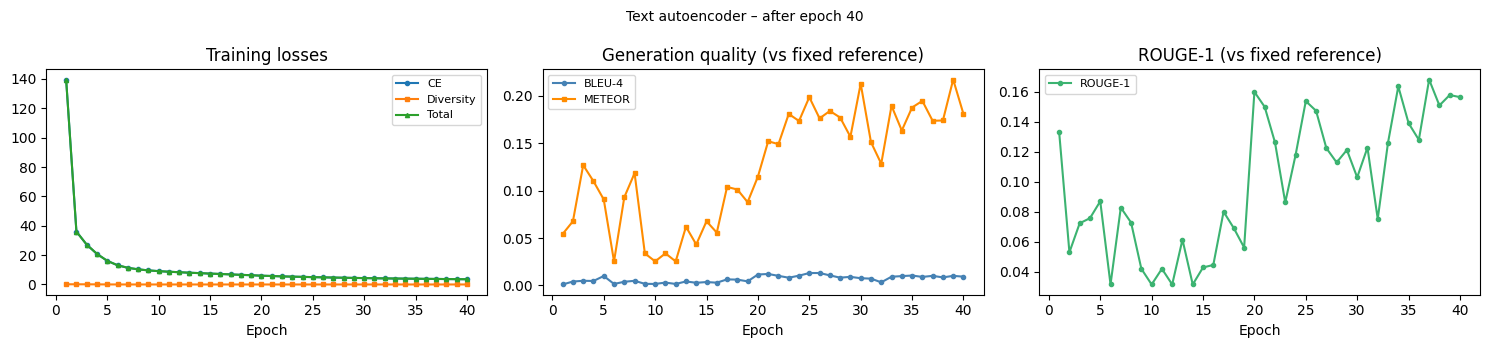

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 40
  Checkpoint saved  ✓ new best  (best=3.56144)



Epoch 41/70: 100%|██████████| 222/222 [02:51<00:00,  1.29it/s, ce=3.7271, div=0.0033, enc_lr=4.22e-06, dec_lr=4.22e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 41/70 complete
  CE loss      : 3.52681
  Diversity    : 0.00385  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.52739
──────────────────────────────────────────────────────────────────────

  EPOCH 41 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface in the cool surface, light of bright surface, casting shadows across the river. A, illuminating the harsh surface, the rocky terrain of bright su

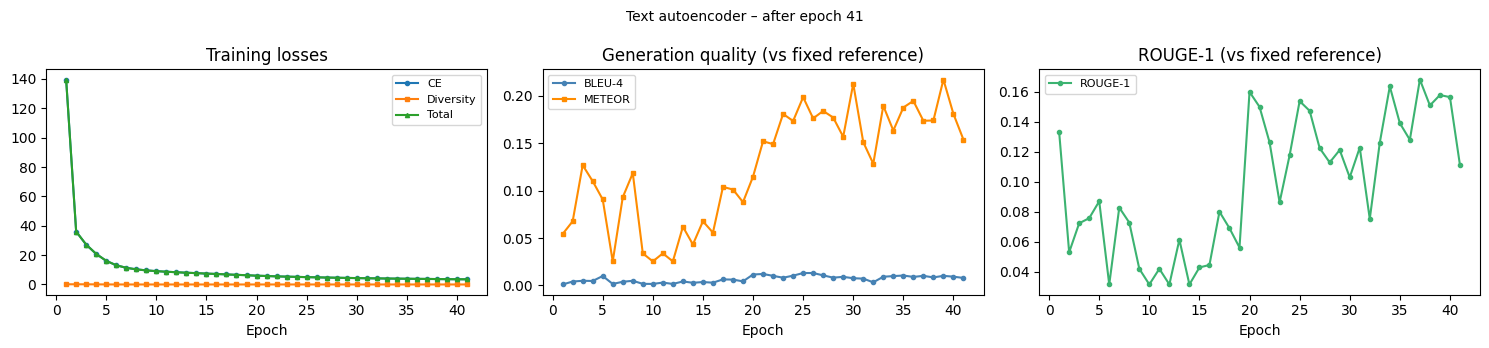

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 41
  Checkpoint saved  ✓ new best  (best=3.52739)



Epoch 42/70: 100%|██████████| 222/222 [02:50<00:00,  1.30it/s, ce=3.7579, div=0.0061, enc_lr=3.98e-06, dec_lr=3.98e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 42/70 complete
  CE loss      : 3.47830
  Diversity    : 0.00421  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.47893
──────────────────────────────────────────────────────────────────────

  EPOCH 42 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface in the cool surface, light now out the rocky terrain of the river. A, light now out the rocky terrain of bright surface, and glow of bright, and 

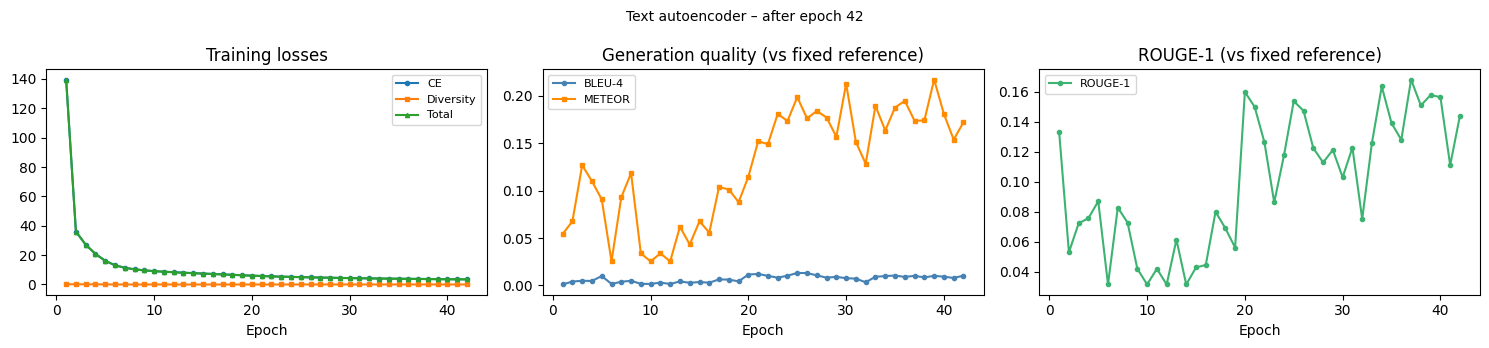

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 42
  Checkpoint saved  ✓ new best  (best=3.47893)



Epoch 43/70: 100%|██████████| 222/222 [02:51<00:00,  1.30it/s, ce=3.1612, div=0.0072, enc_lr=3.75e-06, dec_lr=3.75e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 43/70 complete
  CE loss      : 3.44146
  Diversity    : 0.00437  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.44212
──────────────────────────────────────────────────────────────────────

  EPOCH 43 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface in the cool surface, sun now played across the cool surface of the river, and illuminated the river of the river. A now, sun, and illuminating th

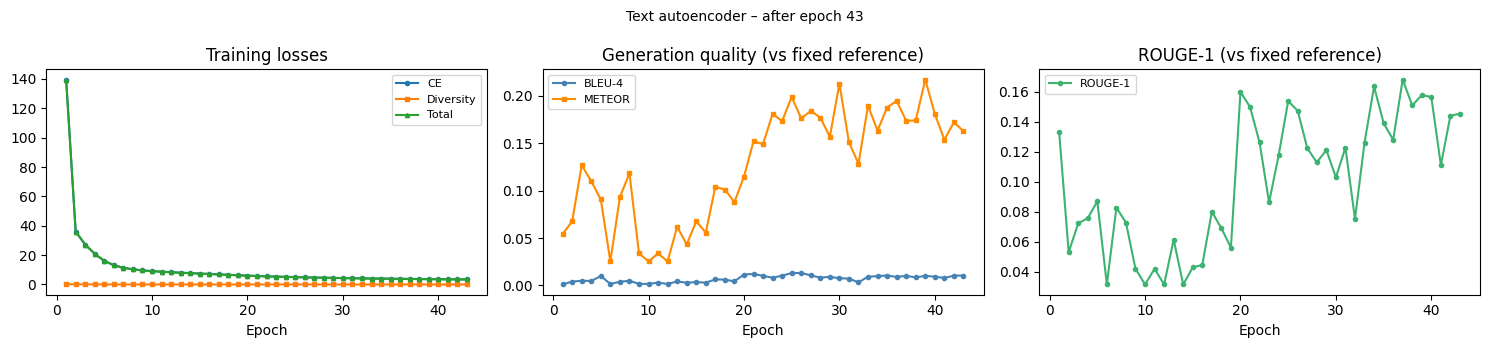

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 43
  Checkpoint saved  ✓ new best  (best=3.44212)



Epoch 44/70: 100%|██████████| 222/222 [02:51<00:00,  1.29it/s, ce=3.1727, div=0.0046, enc_lr=3.51e-06, dec_lr=3.51e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 44/70 complete
  CE loss      : 3.38656
  Diversity    : 0.00454  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.38724
──────────────────────────────────────────────────────────────────────

  EPOCH 44 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface in the cool surface, light now played through the rocky terrain of the river, and illuminating the river of the river. A now, light, and illumina

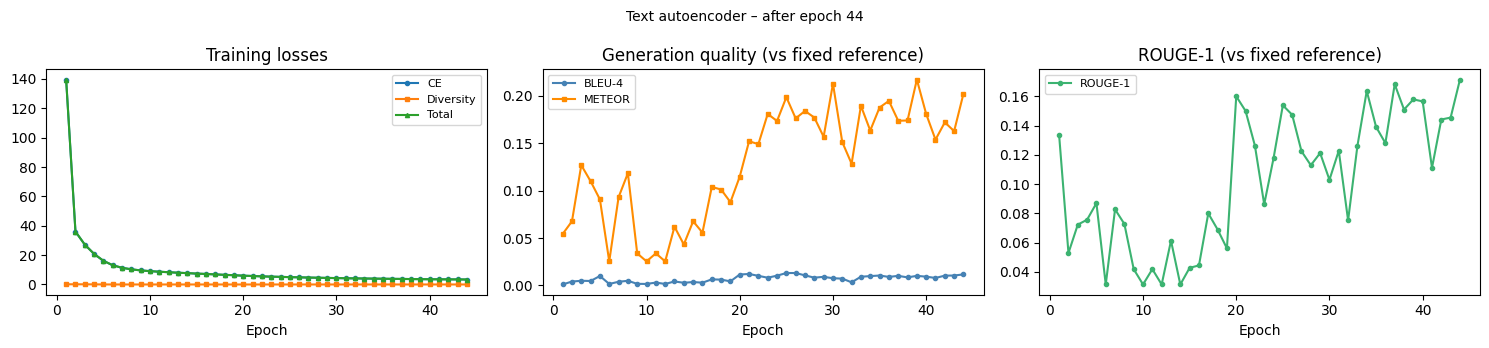

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 44
  Checkpoint saved  ✓ new best  (best=3.38724)



Epoch 45/70: 100%|██████████| 222/222 [02:53<00:00,  1.28it/s, ce=3.2326, div=0.0044, enc_lr=3.28e-06, dec_lr=3.28e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 45/70 complete
  CE loss      : 3.33863
  Diversity    : 0.00470  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.33933
──────────────────────────────────────────────────────────────────────

  EPOCH 45 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface in the cool surface, sun now mirrored the rocky terrain of the river, and glow across the river of the river. A, sun now, sun, and glow of bright

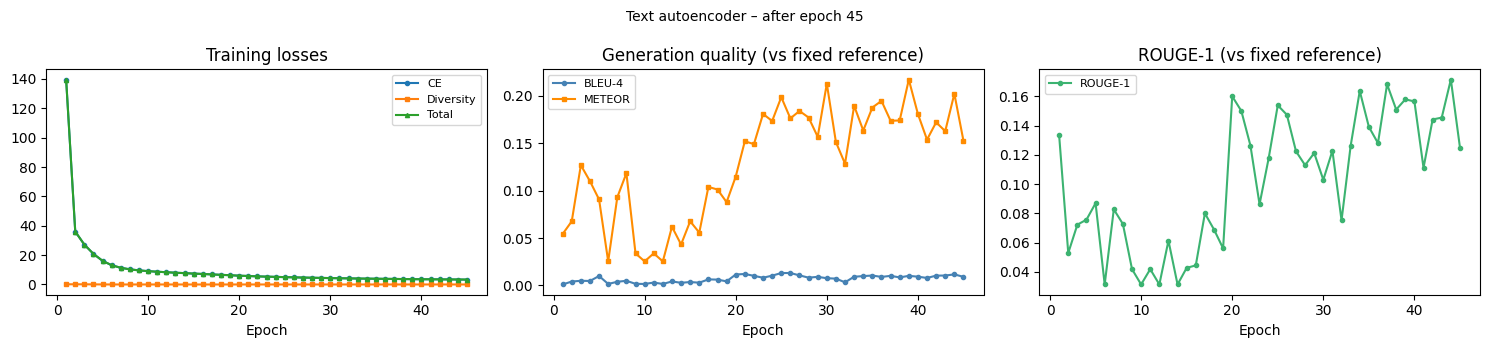

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 45
  Checkpoint saved  ✓ new best  (best=3.33933)



Epoch 46/70: 100%|██████████| 222/222 [02:55<00:00,  1.27it/s, ce=3.2222, div=0.0065, enc_lr=3.05e-06, dec_lr=3.05e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 46/70 complete
  CE loss      : 3.31970
  Diversity    : 0.00475  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.32041
──────────────────────────────────────────────────────────────────────

  EPOCH 46 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A A A A in the cool surface, light now, casting shadows across the rocky terrain of the river of bright surface, and illuminated the rocky terra

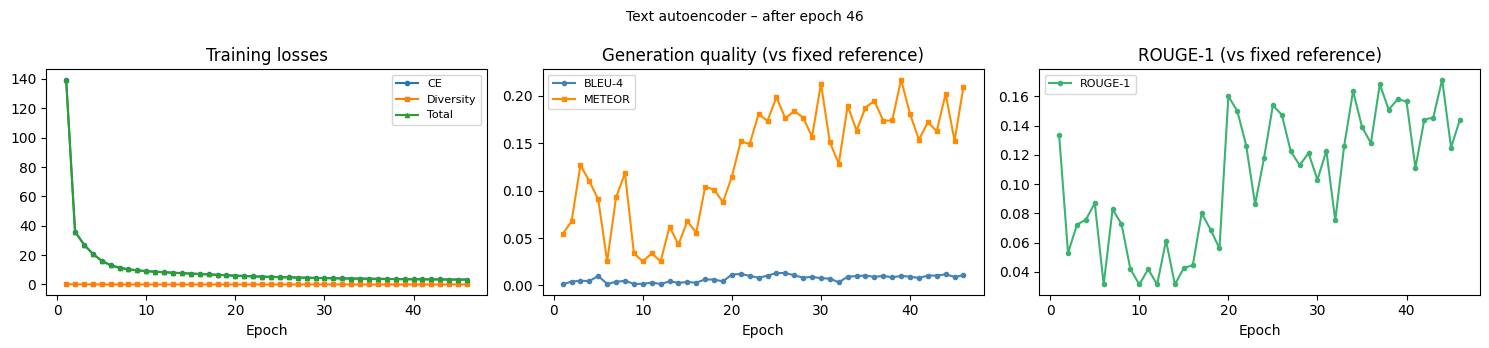

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 46
  Checkpoint saved  ✓ new best  (best=3.32041)



Epoch 47/70: 100%|██████████| 222/222 [02:53<00:00,  1.28it/s, ce=3.2807, div=0.0044, enc_lr=2.83e-06, dec_lr=2.83e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 47/70 complete
  CE loss      : 3.27528
  Diversity    : 0.00516  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.27606
──────────────────────────────────────────────────────────────────────

  EPOCH 47 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface in the cool surface, light now cut through the cool surface of the river. A, Aman Aman Aman Aman Aman Aman Aman Aman Aman Aman Aman Aman Aman Ama

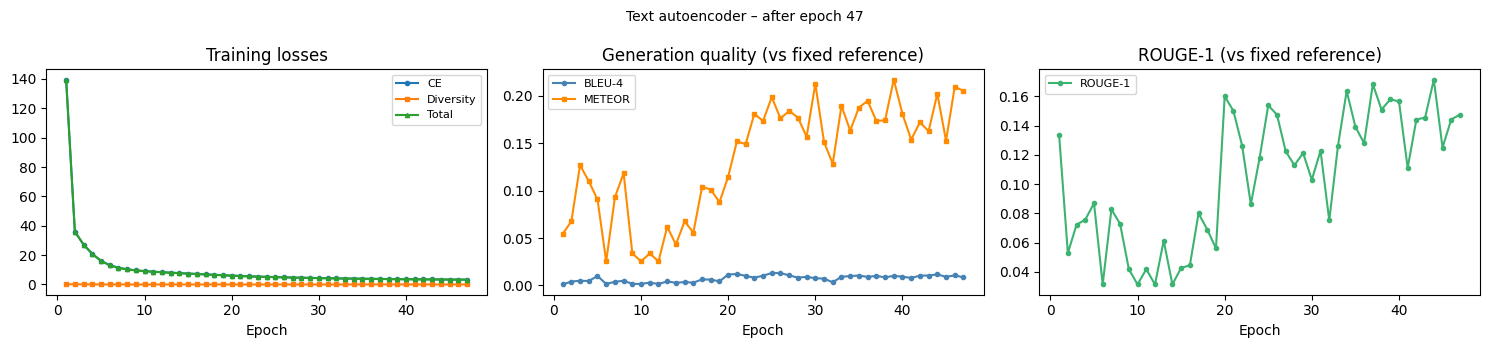

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 47
  Checkpoint saved  ✓ new best  (best=3.27606)



Epoch 48/70: 100%|██████████| 222/222 [02:55<00:00,  1.26it/s, ce=3.3728, div=0.0051, enc_lr=2.61e-06, dec_lr=2.61e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 48/70 complete
  CE loss      : 3.24122
  Diversity    : 0.00530  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.24202
──────────────────────────────────────────────────────────────────────

  EPOCH 48 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A A in the cool surface, light now cut through the cool surface, casting shadows of the river of the river, and illuminated the rock formations 

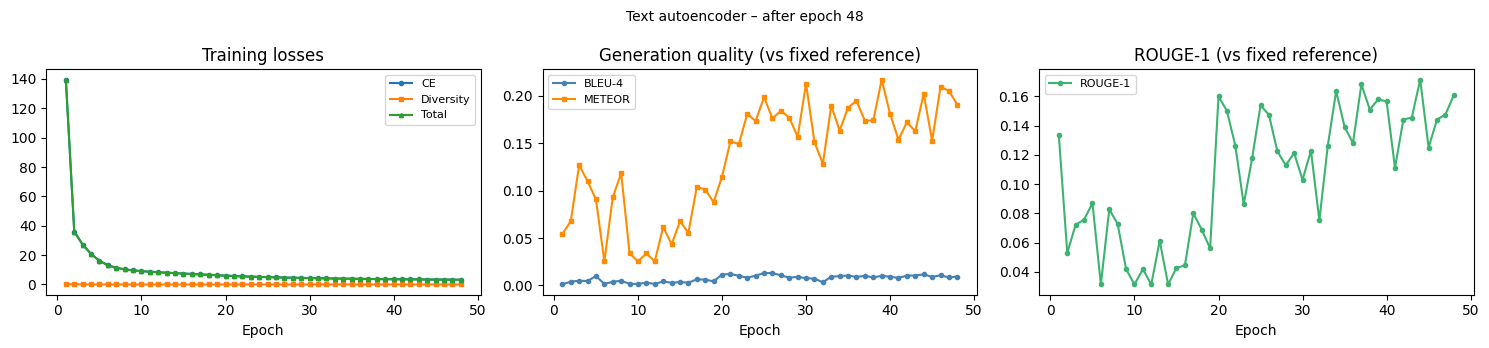

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 48
  Checkpoint saved  ✓ new best  (best=3.24202)



Epoch 49/70: 100%|██████████| 222/222 [02:56<00:00,  1.26it/s, ce=3.5140, div=0.0054, enc_lr=2.40e-06, dec_lr=2.40e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 49/70 complete
  CE loss      : 3.21128
  Diversity    : 0.00569  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.21214
──────────────────────────────────────────────────────────────────────

  EPOCH 49 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface in the cool surface, light now cut through the cool surface, casting glimmer of the river, and illuminated the river of the river, and glow of th

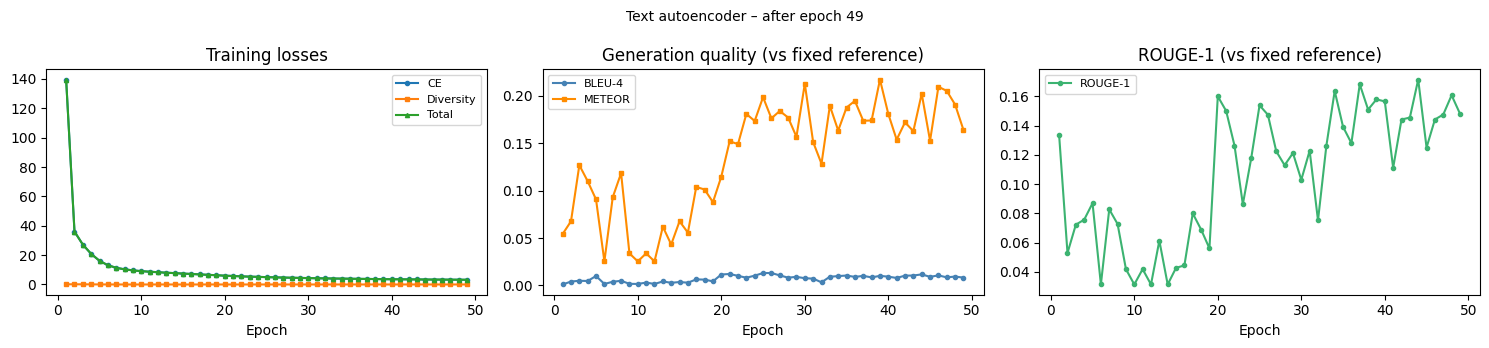

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 49
  Checkpoint saved  ✓ new best  (best=3.21214)



Epoch 50/70: 100%|██████████| 222/222 [02:55<00:00,  1.27it/s, ce=3.1390, div=0.0097, enc_lr=2.20e-06, dec_lr=2.20e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 50/70 complete
  CE loss      : 3.19160
  Diversity    : 0.00554  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.19243
──────────────────────────────────────────────────────────────────────

  EPOCH 50 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface in the cool surface, light now cut through the cool surface of the river, and illuminated the river of the river. A A A, light now, and illuminat

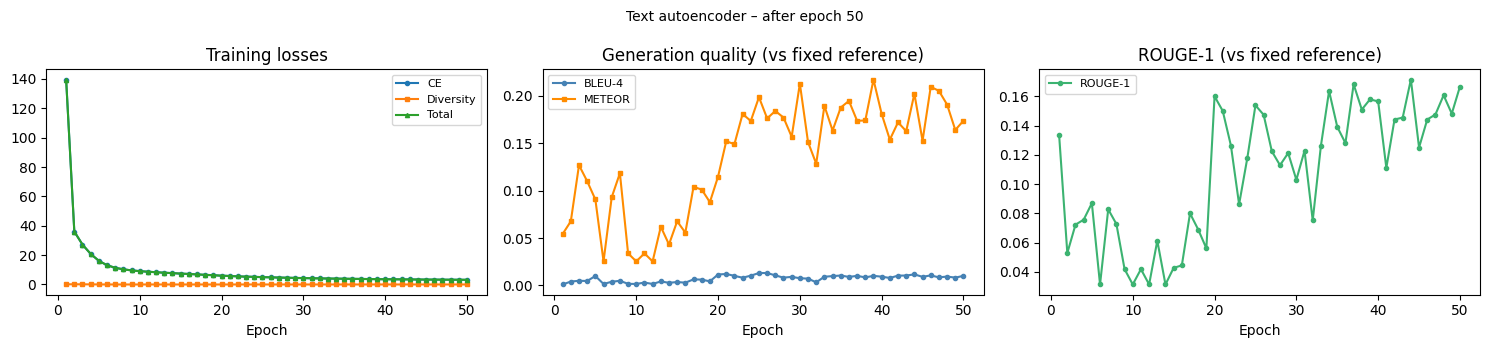

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 50
  Checkpoint saved  ✓ new best  (best=3.19243)



Epoch 51/70: 100%|██████████| 222/222 [02:52<00:00,  1.29it/s, ce=3.0446, div=0.0050, enc_lr=2.00e-06, dec_lr=2.00e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 51/70 complete
  CE loss      : 3.16967
  Diversity    : 0.00546  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.17049
──────────────────────────────────────────────────────────────────────

  EPOCH 51 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface in the cool surface, light now cut through the cool surface of the river, and illuminated the river of the river, and illuminated the rock format

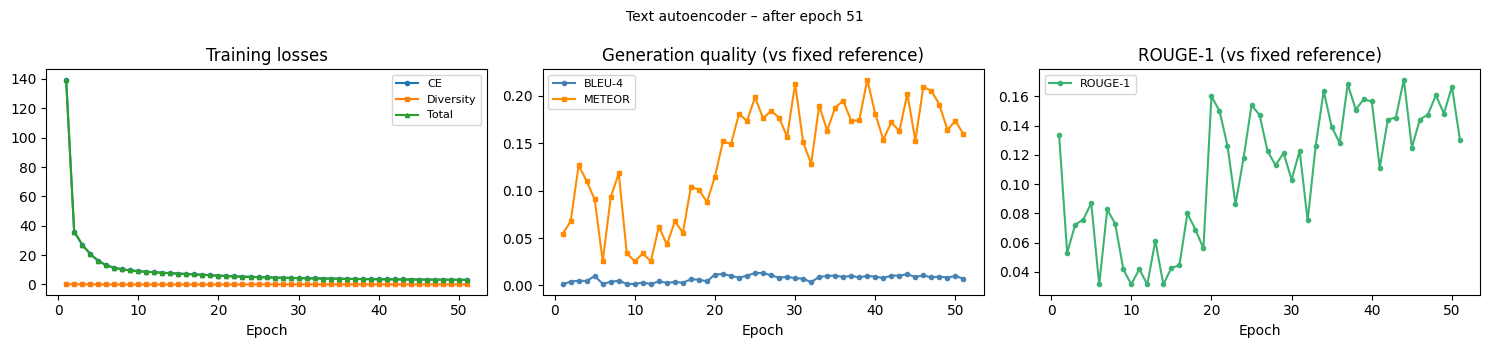

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 51
  Checkpoint saved  ✓ new best  (best=3.17049)



Epoch 52/70: 100%|██████████| 222/222 [02:56<00:00,  1.26it/s, ce=2.9599, div=0.0056, enc_lr=1.81e-06, dec_lr=1.81e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 52/70 complete
  CE loss      : 3.13212
  Diversity    : 0.00560  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.13296
──────────────────────────────────────────────────────────────────────

  EPOCH 52 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A A in the cool surface, light now cut through the cool surface of the rocky terrain, and illuminated the rocky terrain of bright surface of bri

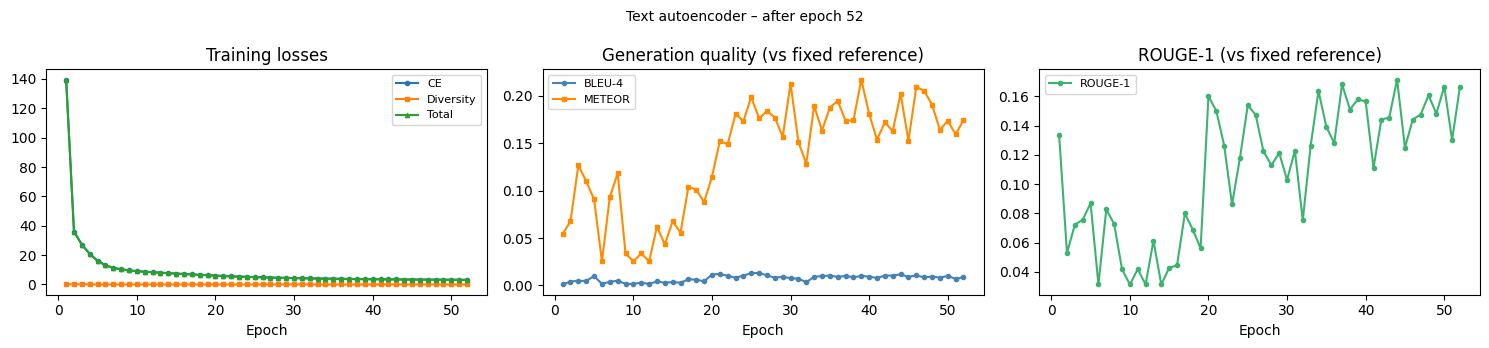

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 52
  Checkpoint saved  ✓ new best  (best=3.13296)



Epoch 53/70: 100%|██████████| 222/222 [02:55<00:00,  1.27it/s, ce=2.8605, div=0.0075, enc_lr=1.62e-06, dec_lr=1.62e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 53/70 complete
  CE loss      : 3.10993
  Diversity    : 0.00550  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.11075
──────────────────────────────────────────────────────────────────────

  EPOCH 53 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright. A, light in the cool surface now cut through the cool surface, casting shadows of the river of the river, and illuminated the river of bright, and illum

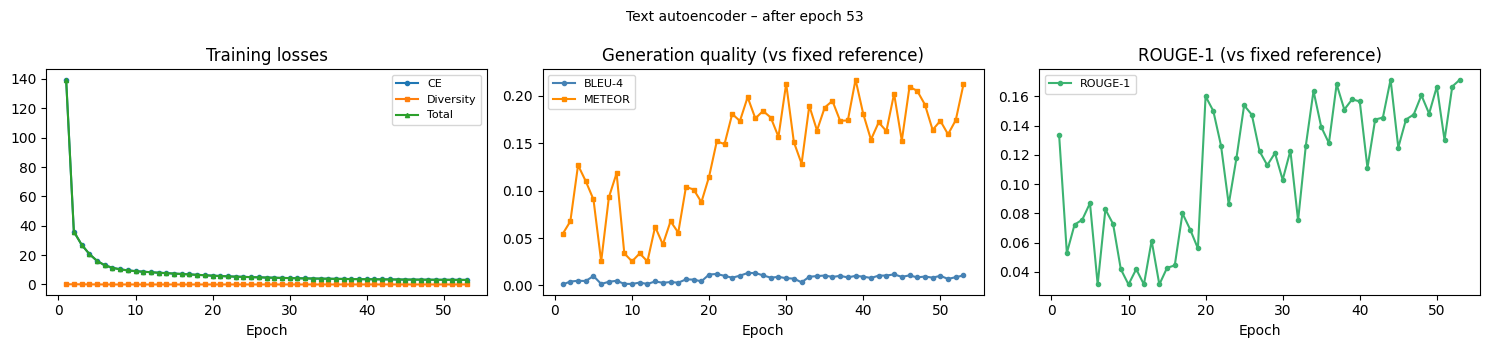

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 53
  Checkpoint saved  ✓ new best  (best=3.11075)



Epoch 54/70: 100%|██████████| 222/222 [02:57<00:00,  1.25it/s, ce=2.9680, div=0.0086, enc_lr=1.45e-06, dec_lr=1.45e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 54/70 complete
  CE loss      : 3.09269
  Diversity    : 0.00565  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.09353
──────────────────────────────────────────────────────────────────────

  EPOCH 54 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface in the cool surface, light now cut through the cool surface of the river, and illuminated the river of the river, and illuminated the rock format

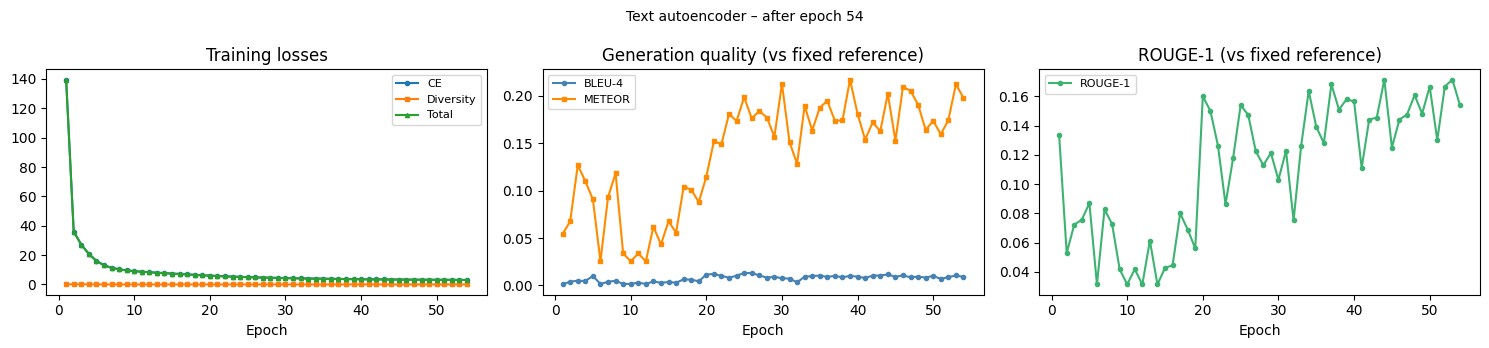

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 54
  Checkpoint saved  ✓ new best  (best=3.09353)



Epoch 55/70: 100%|██████████| 222/222 [02:53<00:00,  1.28it/s, ce=3.2432, div=0.0052, enc_lr=1.28e-06, dec_lr=1.28e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 55/70 complete
  CE loss      : 3.08434
  Diversity    : 0.00554  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.08517
──────────────────────────────────────────────────────────────────────

  EPOCH 55 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A in the water now cut through the cool surface, light now cut through the rocky terrain of the river, and illuminated the rock formations of br

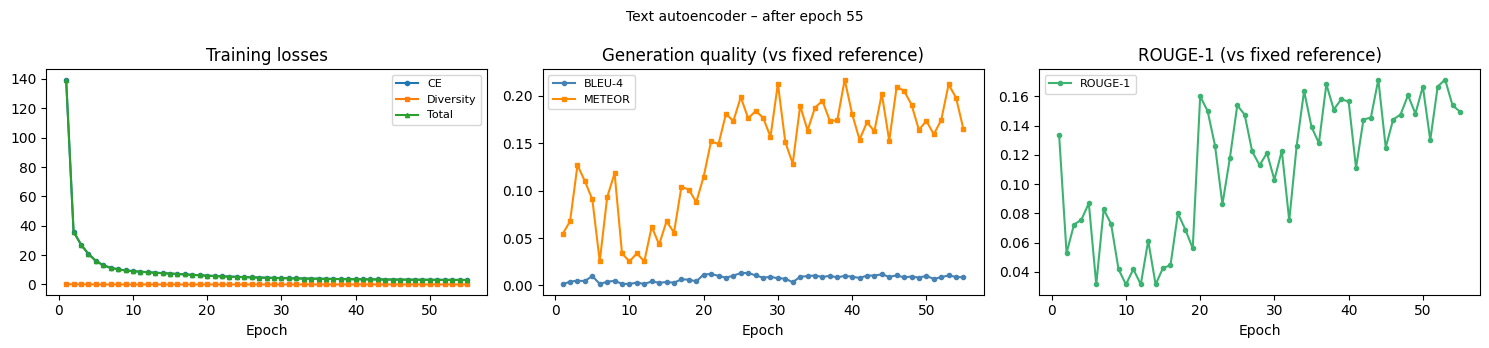

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 55
  Checkpoint saved  ✓ new best  (best=3.08517)



Epoch 56/70: 100%|██████████| 222/222 [02:55<00:00,  1.26it/s, ce=3.0008, div=0.0043, enc_lr=1.12e-06, dec_lr=1.12e-05]



──────────────────────────────────────────────────────────────────────
  Epoch 56/70 complete
  CE loss      : 3.06722
  Diversity    : 0.00594  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.06811
──────────────────────────────────────────────────────────────────────

  EPOCH 56 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A in the water now, light now cut through the cool surface of the rocky terrain, and illuminating the rocky terrain of the river of the river, a

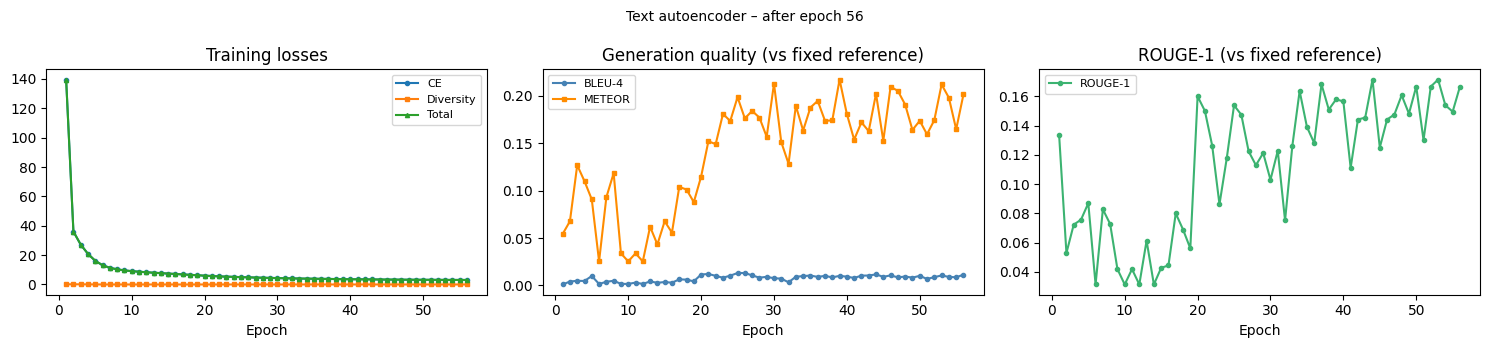

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 56
  Checkpoint saved  ✓ new best  (best=3.06811)



Epoch 57/70: 100%|██████████| 222/222 [02:54<00:00,  1.27it/s, ce=3.3192, div=0.0043, enc_lr=9.72e-07, dec_lr=9.72e-06]



──────────────────────────────────────────────────────────────────────
  Epoch 57/70 complete
  CE loss      : 3.05960
  Diversity    : 0.00572  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.06046
──────────────────────────────────────────────────────────────────────

  EPOCH 57 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A A in the cool surface, light now cut through the cool surface of the rocky terrain, and illuminating the river of bright surface of bright, an

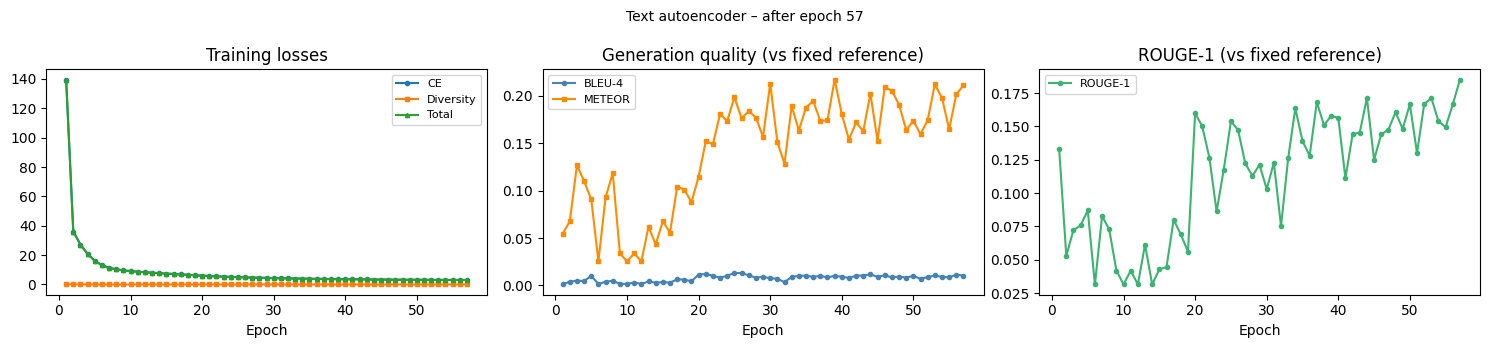

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 57
  Checkpoint saved  ✓ new best  (best=3.06046)



Epoch 58/70: 100%|██████████| 222/222 [02:56<00:00,  1.26it/s, ce=3.1072, div=0.0114, enc_lr=8.32e-07, dec_lr=8.32e-06]



──────────────────────────────────────────────────────────────────────
  Epoch 58/70 complete
  CE loss      : 3.03577
  Diversity    : 0.00609  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.03668
──────────────────────────────────────────────────────────────────────

  EPOCH 58 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A A in the cool surface, light now cut through the cool surface of the river, and illuminated the river of bright surface of bright, and illumin

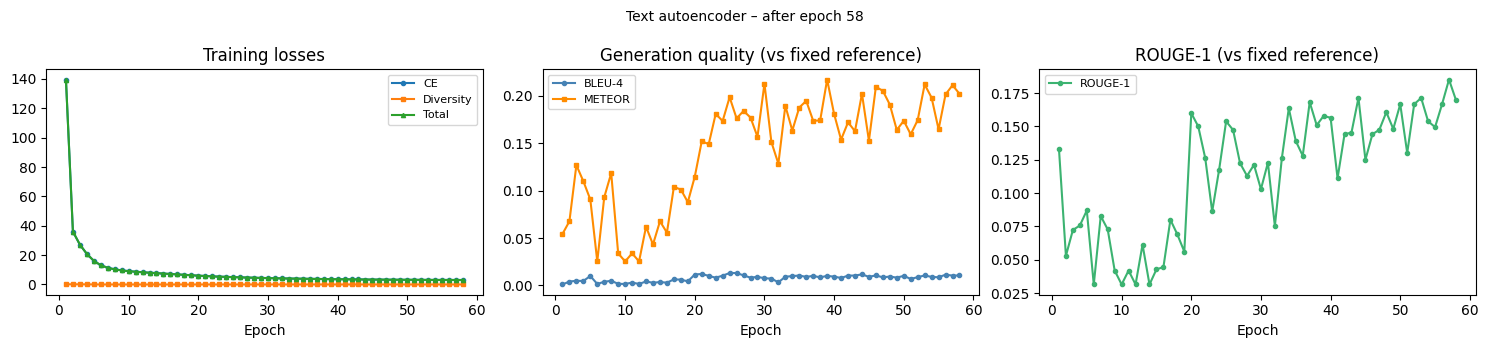

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 58
  Checkpoint saved  ✓ new best  (best=3.03668)



Epoch 59/70: 100%|██████████| 222/222 [02:56<00:00,  1.26it/s, ce=3.2238, div=0.0044, enc_lr=7.03e-07, dec_lr=7.03e-06]



──────────────────────────────────────────────────────────────────────
  Epoch 59/70 complete
  CE loss      : 3.02366
  Diversity    : 0.00605  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.02456
──────────────────────────────────────────────────────────────────────

  EPOCH 59 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A in the water now cut through the cool surface, casting glimmer of the river, and illuminated the rocky terrain of bright surface, and illumina

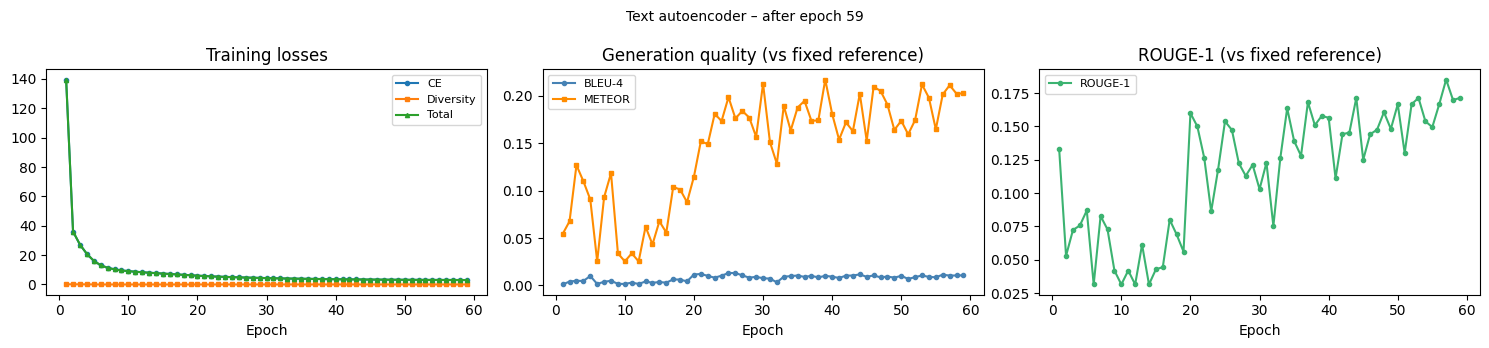

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 59
  Checkpoint saved  ✓ new best  (best=3.02456)



Epoch 60/70: 100%|██████████| 222/222 [02:55<00:00,  1.26it/s, ce=3.1519, div=0.0056, enc_lr=5.83e-07, dec_lr=5.83e-06]



──────────────────────────────────────────────────────────────────────
  Epoch 60/70 complete
  CE loss      : 3.01414
  Diversity    : 0.00608  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.01505
──────────────────────────────────────────────────────────────────────

  EPOCH 60 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A A in the cool surface, light now cut through the cool surface of the river, and illuminating the river of bright, and illuminated the rock for

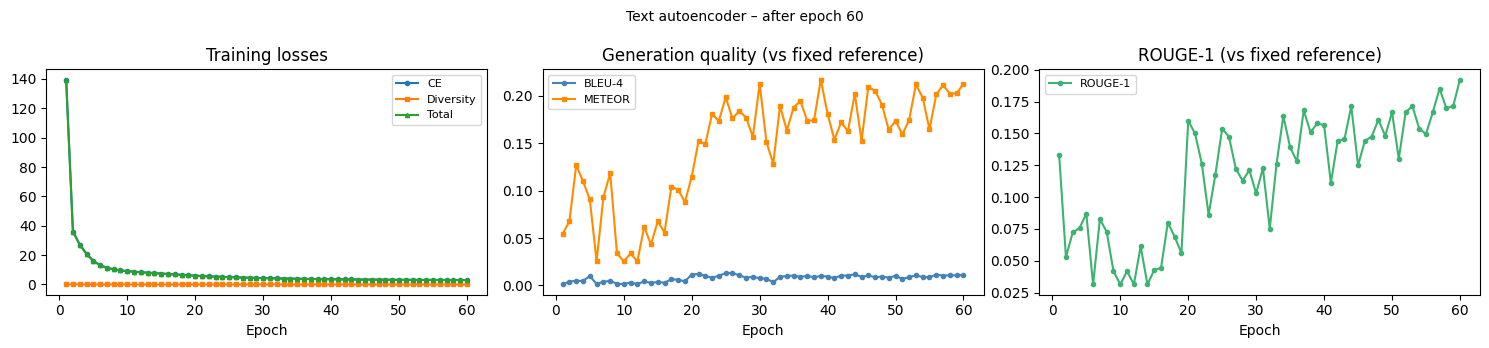

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 60
  Checkpoint saved  ✓ new best  (best=3.01505)



Epoch 61/70: 100%|██████████| 222/222 [02:55<00:00,  1.27it/s, ce=2.9936, div=0.0049, enc_lr=4.74e-07, dec_lr=4.74e-06]



──────────────────────────────────────────────────────────────────────
  Epoch 61/70 complete
  CE loss      : 3.02025
  Diversity    : 0.00584  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.02113
──────────────────────────────────────────────────────────────────────

  EPOCH 61 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A A in the cool surface, light now cut through the cool surface of the river, and illuminating the river of bright surface of bright, and illumi

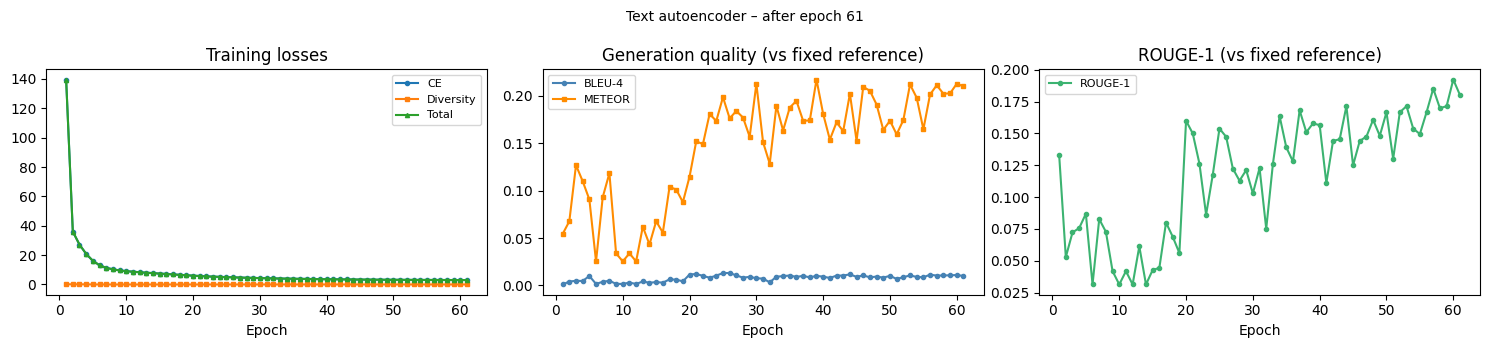

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 61
  Checkpoint saved  –  (best=3.01505)



Epoch 62/70: 100%|██████████| 222/222 [02:55<00:00,  1.27it/s, ce=2.6756, div=0.0079, enc_lr=3.76e-07, dec_lr=3.76e-06]



──────────────────────────────────────────────────────────────────────
  Epoch 62/70 complete
  CE loss      : 2.98438
  Diversity    : 0.00615  (→ 0 means encoder reps are already diverse)
  Total loss   : 2.98530
──────────────────────────────────────────────────────────────────────

  EPOCH 62 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A in the water now cut through the cool surface, casting glimmer of the river, and illuminating the rock formations of bright, and illuminated t

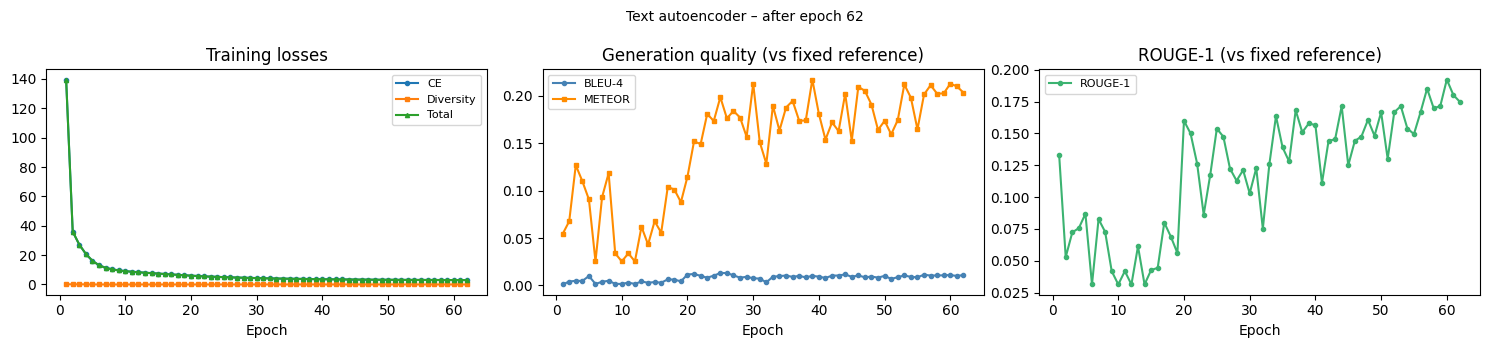

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 62
  Checkpoint saved  ✓ new best  (best=2.98530)



Epoch 63/70: 100%|██████████| 222/222 [02:59<00:00,  1.24it/s, ce=3.0177, div=0.0041, enc_lr=2.89e-07, dec_lr=2.89e-06]



──────────────────────────────────────────────────────────────────────
  Epoch 63/70 complete
  CE loss      : 2.99878
  Diversity    : 0.00602  (→ 0 means encoder reps are already diverse)
  Total loss   : 2.99969
──────────────────────────────────────────────────────────────────────

  EPOCH 63 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A A in the cool surface, light now cut through the cool surface of the rocky terrain, and illuminating the river of bright surface of bright, an

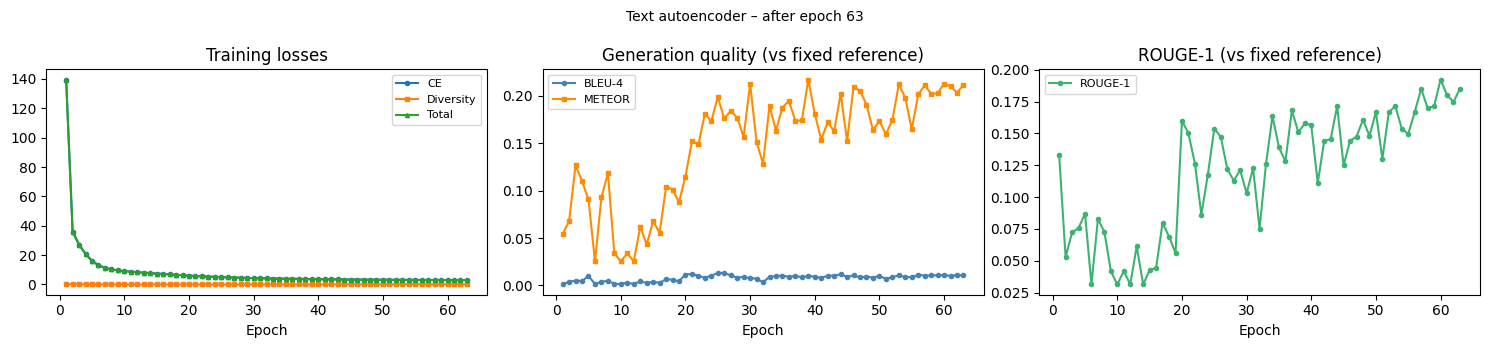

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 63
  Checkpoint saved  –  (best=2.98530)



Epoch 64/70: 100%|██████████| 222/222 [02:57<00:00,  1.25it/s, ce=2.8868, div=0.0073, enc_lr=2.13e-07, dec_lr=2.13e-06]



──────────────────────────────────────────────────────────────────────
  Epoch 64/70 complete
  CE loss      : 3.00011
  Diversity    : 0.00600  (→ 0 means encoder reps are already diverse)
  Total loss   : 3.00101
──────────────────────────────────────────────────────────────────────

  EPOCH 64 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A A in the cool surface, light now cut through the cool surface of the rocky terrain, and illuminating the river of bright, and illuminated the 

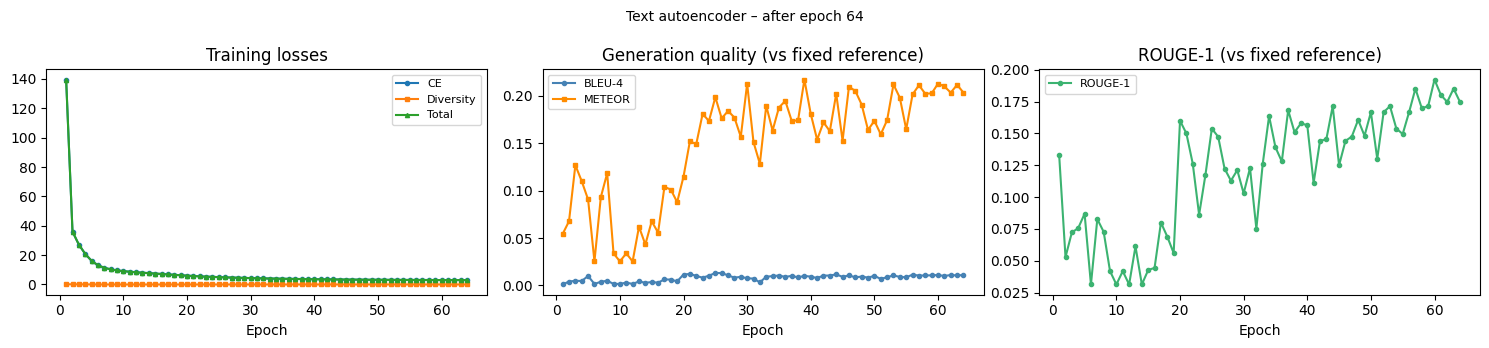

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 64
  Checkpoint saved  –  (best=2.98530)



Epoch 65/70: 100%|██████████| 222/222 [02:58<00:00,  1.24it/s, ce=3.0382, div=0.0061, enc_lr=1.48e-07, dec_lr=1.48e-06]



──────────────────────────────────────────────────────────────────────
  Epoch 65/70 complete
  CE loss      : 2.98043
  Diversity    : 0.00641  (→ 0 means encoder reps are already diverse)
  Total loss   : 2.98139
──────────────────────────────────────────────────────────────────────

  EPOCH 65 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A in the water now cut through the cool surface, casting glimmer of the river, and illuminating the river of bright surface of the river, and il

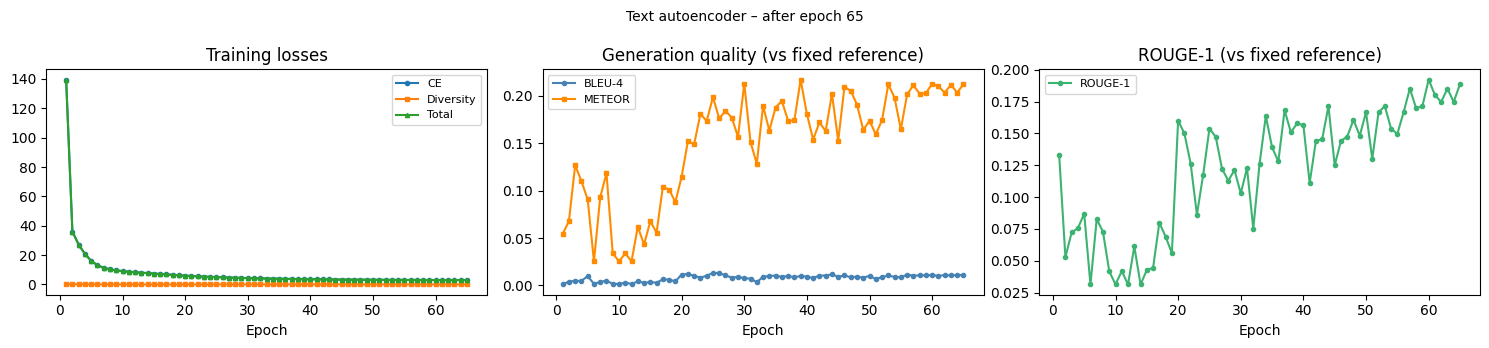

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 65
  Checkpoint saved  ✓ new best  (best=2.98139)



Epoch 66/70: 100%|██████████| 222/222 [03:04<00:00,  1.21it/s, ce=2.9399, div=0.0033, enc_lr=9.49e-08, dec_lr=9.49e-07]



──────────────────────────────────────────────────────────────────────
  Epoch 66/70 complete
  CE loss      : 2.98251
  Diversity    : 0.00612  (→ 0 means encoder reps are already diverse)
  Total loss   : 2.98342
──────────────────────────────────────────────────────────────────────

  EPOCH 66 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A in the water now cut through the cool surface, light now cut through the rocky terrain of the river, and illuminating the rock formations of b

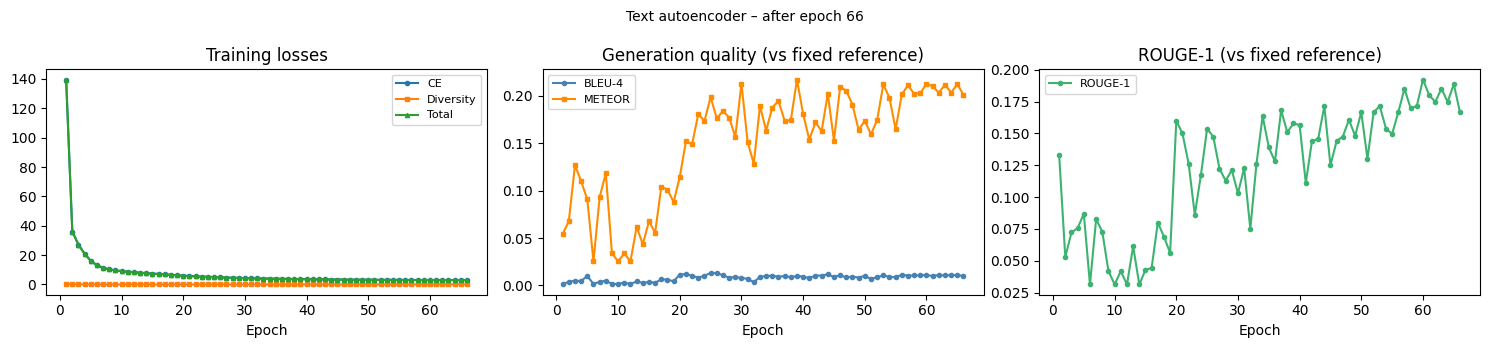

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 66
  Checkpoint saved  –  (best=2.98139)



Epoch 67/70: 100%|██████████| 222/222 [02:58<00:00,  1.24it/s, ce=2.9138, div=0.0062, enc_lr=5.34e-08, dec_lr=5.34e-07]



──────────────────────────────────────────────────────────────────────
  Epoch 67/70 complete
  CE loss      : 2.99620
  Diversity    : 0.00626  (→ 0 means encoder reps are already diverse)
  Total loss   : 2.99714
──────────────────────────────────────────────────────────────────────

  EPOCH 67 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A in the water now cut through the cool surface, casting glimmer of the river, and illuminating the river of bright surface of the river, and il

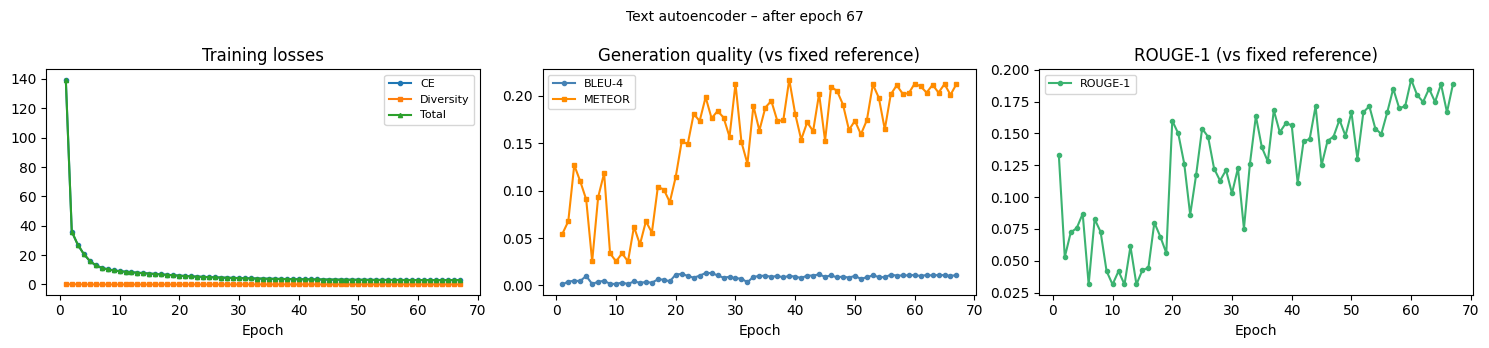

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 67
  Checkpoint saved  –  (best=2.98139)



Epoch 68/70: 100%|██████████| 222/222 [02:57<00:00,  1.25it/s, ce=3.2153, div=0.0018, enc_lr=2.38e-08, dec_lr=2.38e-07]



──────────────────────────────────────────────────────────────────────
  Epoch 68/70 complete
  CE loss      : 2.99013
  Diversity    : 0.00619  (→ 0 means encoder reps are already diverse)
  Total loss   : 2.99106
──────────────────────────────────────────────────────────────────────

  EPOCH 68 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A in the water now cut through the cool surface, light now cut through the rocky terrain of the river, and illuminating the rock formations of b

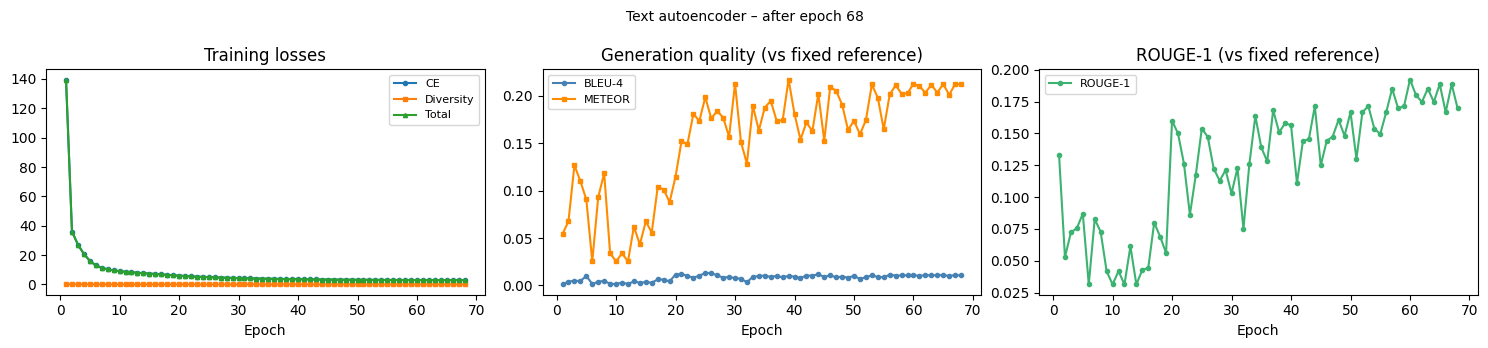

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 68
  Checkpoint saved  –  (best=2.98139)



Epoch 69/70: 100%|██████████| 222/222 [02:57<00:00,  1.25it/s, ce=2.8513, div=0.0056, enc_lr=5.95e-09, dec_lr=5.95e-08]



──────────────────────────────────────────────────────────────────────
  Epoch 69/70 complete
  CE loss      : 2.97051
  Diversity    : 0.00650  (→ 0 means encoder reps are already diverse)
  Total loss   : 2.97148
──────────────────────────────────────────────────────────────────────

  EPOCH 69 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A in the water now cut through the cool surface, light now cut through the rocky terrain of the river, and illuminating the rock formations of b

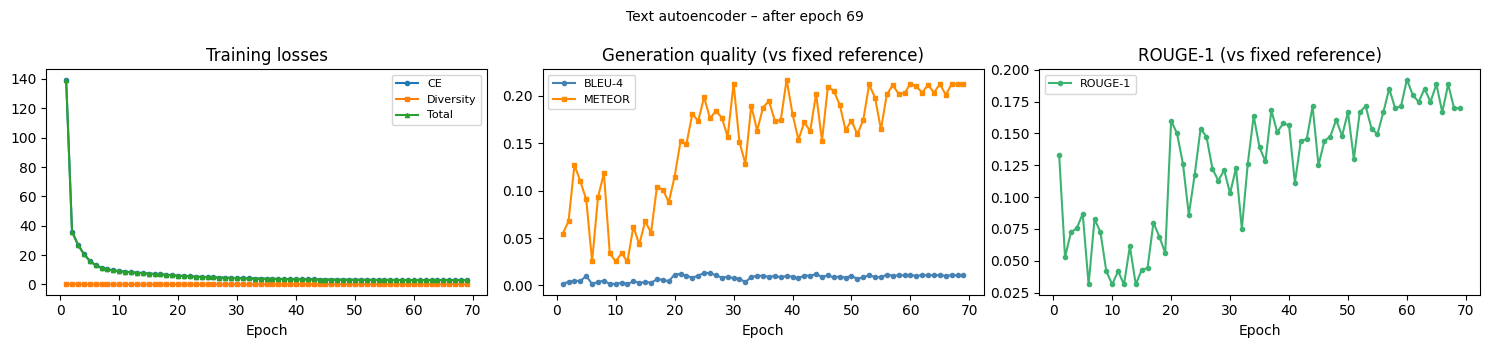

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 69
  Checkpoint saved  ✓ new best  (best=2.97148)



Epoch 70/70: 100%|██████████| 222/222 [03:00<00:00,  1.23it/s, ce=2.9547, div=0.0086, enc_lr=0.00e+00, dec_lr=0.00e+00]



──────────────────────────────────────────────────────────────────────
  Epoch 70/70 complete
  CE loss      : 2.98433
  Diversity    : 0.00638  (→ 0 means encoder reps are already diverse)
  Total loss   : 2.98528
──────────────────────────────────────────────────────────────────────

  EPOCH 70 EVALUATION

  PROMPT  (first 200 chars):
  The water was clear and bright. After days in the shade, sunlight now cut through the rough surface, sending shimmering rays dancing across the rocky bed of the river, and illuminating the patches of ...

  REFERENCE:
  She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

  GENERATED:
  The water was clear and bright and bright surface. A in the water now cut through the cool surface, light now cut through the rocky terrain of the river, and illuminating the rock formations of b

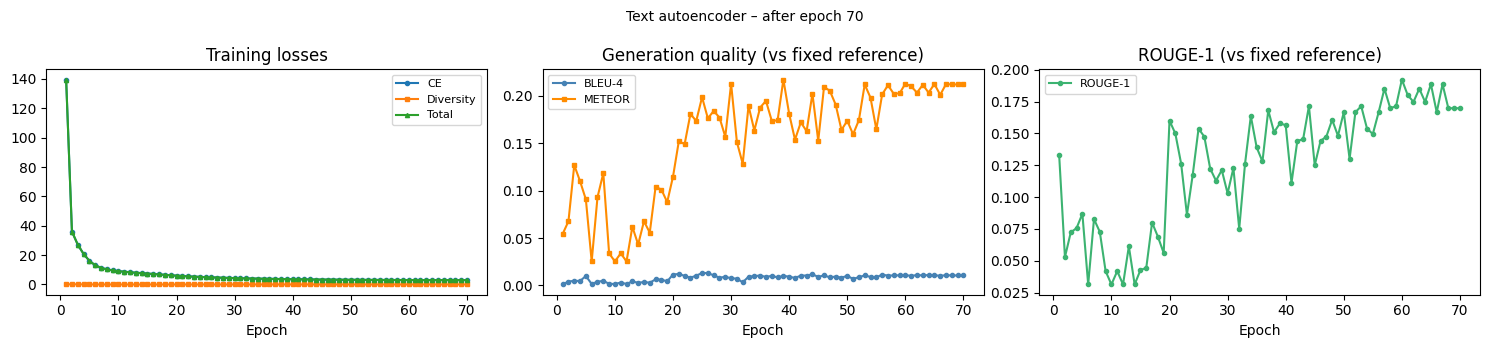

Checkpoint saved to Google Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 70
  Checkpoint saved  –  (best=2.97148)


✓ Pretraining complete.
  You can now rebuild the SequencePredictor with the updated text_autoencoder.
  Nothing in Seq2Seq / RobertaEncoder / TransformerDecoder was changed.
  sequence_predictor = SequencePredictor(visual_autoencoder, text_autoencoder, ...)


In [ ]:
"""
Text Autoencoder – Improved Pretraining
=========================================

Root cause of lazy / identical predictions
-------------------------------------------
1. align_loss forced decoder hidden states → encoder outputs directly,
   training the model to COPY the encoder regardless of input content.
   Removed entirely.
2. memory * 1.1 / 1.2 scaling patches fought each other. Removed.
3. Encoder and decoder shared the same LR. The pretrained RoBERTa encoder
   needs a much lower LR (10×) or it overwrites its pretrained representations.
4. No diversity signal – nothing penalised identical outputs across inputs.

Fixes applied
-------------
- Differential learning rates: encoder=1e-5, decoder=1e-4
- align_loss removed
- ContrastiveDiversityLoss added: pushes representations of different inputs
  apart so the decoder cannot collapse to one generic output
- Label smoothing raised to 0.1
- Cosine schedule with proper linear warmup (8% of steps)
- memory scaling removed from both model and training loop
- Epoch evaluation: same fixed prompts every epoch so you can watch progress

SequencePredictor compatibility
---------------------------------
NOTHING in Seq2Seq, RobertaEncoder, or TransformerDecoder is changed.
The sequence predictor only touches:
  text_autoencoder.encoder  (RobertaEncoder)   → unchanged
  text_autoencoder.decoder  (TransformerDecoder) → unchanged
  text_encoder.roberta.config.hidden_size = 768  → unchanged
"""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

# =========================================================
# FIXED EVALUATION PROMPTS  (same every epoch so you can
# track progress on identical inputs)
# =========================================================
EVAL_PROMPT = (
    "The water was clear and bright. After days in the shade, sunlight now "
    "cut through the rough surface, sending shimmering rays dancing across "
    "the rocky bed of the river, and illuminating the patches of bright green "
    "algae that carpeted the rocks of deeper, slower pools.\n\n"
    "The fish gained speed, then hurled herself above the water line, over "
    "the rocks that created a minor fall in the river."
)

EVAL_REFERENCE = (
    "She had, not so long ago, lived in the deep sea. Her lithe silver body "
    "pulling saltwater through her gills as she explored the dark depths, "
    "feeding on its bounty.\n\nNow, she fought her way upstream in the clear, "
    "saltless water."
)

DIVERSITY_PROMPTS = {
    "river_fish":   "The fish swam against the powerful river current beneath bright morning sunlight.",
    "space":        "The abandoned space station drifted silently through the darkness of deep space.",
    "mansion":      "Thunder rolled over the old mansion as footsteps echoed through the empty halls.",
    "forest":       "Morning mist clung to the ancient trees as birds began their first tentative calls.",
    "desert":       "The sun hammered the cracked earth, and nothing moved for miles in any direction.",
}


# =========================================================
# CONTRASTIVE DIVERSITY LOSS
#
# Purpose: punish the model for mapping different inputs to
# the same encoder representation. If memory_a and memory_b
# are nearly identical despite different inputs, this loss
# is high. Forces the encoder to preserve input distinctions.
#
# Does NOT break the sequence predictor – it only runs
# during standalone text autoencoder training.
# =========================================================

class ContrastiveDiversityLoss(nn.Module):
    """
    Within a batch, compare every pair of (mean-pooled) encoder outputs.
    Penalise pairs whose cosine similarity exceeds `margin`.
    A healthy encoder should embed different texts differently.
    """
    def __init__(self, margin: float = 0.85):
        super().__init__()
        self.margin = margin

    def forward(self, memory: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        """
        memory         : [B, L, 768]
        attention_mask : [B, L]
        """
        # Mean-pool over token dimension respecting padding
        mask   = attention_mask.unsqueeze(-1).float()           # [B, L, 1]
        pooled = (memory * mask).sum(1) / mask.sum(1).clamp(min=1)  # [B, 768]
        pooled = F.normalize(pooled, dim=-1)                    # unit vectors

        # Cosine similarity matrix [B, B]
        sim = torch.matmul(pooled, pooled.T)

        B = pooled.size(0)
        if B < 2:
            return torch.tensor(0.0, device=memory.device)

        # Off-diagonal entries only (don't penalise self-similarity)
        mask_off = ~torch.eye(B, dtype=torch.bool, device=memory.device)
        off_diag = sim[mask_off]

        # Only penalise pairs that are TOO similar (above margin)
        penalty = F.relu(off_diag - self.margin).mean()
        return penalty


# =========================================================
# TRAINING CONFIG
# =========================================================
N_EPOCHS        = 70
LR_DECODER      = 1e-4    # decoder + fresh layers – higher LR fine
LR_ENCODER      = 1e-5    # pretrained RoBERTa – 10× lower to preserve weights
WEIGHT_DECAY    = 0.01
MAX_GRAD_NORM   = 1.0
LABEL_SMOOTHING = 0.10    # raised from 0.05 to discourage overconfident copying
W_CE            = 1.0
W_DIVERSITY     = 0.15    # weight for contrastive diversity loss

checkpoint_filename = "text_autoencoder.pth"

# =========================================================
# LOSS FUNCTIONS
# =========================================================
loss_fn = nn.CrossEntropyLoss(
    ignore_index=tokenizer.pad_token_id,
    label_smoothing=LABEL_SMOOTHING,
)

diversity_loss_fn = ContrastiveDiversityLoss(margin=0.85)

# =========================================================
# OPTIMIZER – differential learning rates
# Encoder params (pretrained RoBERTa) get LR_ENCODER.
# Everything else (decoder, fresh projection layers) gets LR_DECODER.
# =========================================================
encoder_param_ids = {id(p) for p in text_autoencoder.encoder.parameters()}

optimizer = torch.optim.AdamW(
    [
        {
            "params": [p for p in text_autoencoder.parameters()
                       if id(p) in encoder_param_ids],
            "lr": LR_ENCODER,
            "name": "encoder",
        },
        {
            "params": [p for p in text_autoencoder.parameters()
                       if id(p) not in encoder_param_ids],
            "lr": LR_DECODER,
            "name": "decoder",
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

# =========================================================
# SCHEDULER – cosine with linear warmup
# =========================================================
num_training_steps = len(text_dataloader) * N_EPOCHS
num_warmup_steps   = int(0.08 * num_training_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)

scaler = torch.amp.GradScaler("cuda")

# =========================================================
# CHECKPOINT RESUME
# =========================================================
start_epoch = 0
best_loss   = float("inf")

try:
    text_autoencoder, optimizer, start_epoch, best_loss = load_checkpoint_from_drive(
        text_autoencoder, optimizer, filename=checkpoint_filename
    )
    print(f"✓ Resumed from epoch {start_epoch}  (best loss: {best_loss:.4f})")
except FileNotFoundError:
    print("No checkpoint found – training from scratch.")

# =========================================================
# HISTORY
# =========================================================
history = {
    "epoch":      [],
    "ce_loss":    [],
    "div_loss":   [],
    "total_loss": [],
    "bleu":       [],
    "rouge1":     [],
    "meteor":     [],
}


# ─────────────────────────────────────────────────────────────────────────────
# Evaluation helpers
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def generate_text(model, tokenizer, prompt: str, device,
                  max_new_tokens: int = 150) -> str:
    """Autoregressive greedy generation – no teacher forcing."""
    model.eval()

    enc = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=120,
        padding="max_length",
    )
    input_ids  = enc["input_ids"].to(device)
    attn_mask  = enc["attention_mask"].to(device)

    memory = model.encoder(input_ids=input_ids, attention_mask=attn_mask)
    # [1, L, 768]  –  no scaling hacks

    bos_id = tokenizer.bos_token_id or tokenizer.cls_token_id
    eos_id = tokenizer.eos_token_id or tokenizer.sep_token_id
    pad_id = tokenizer.pad_token_id

    dec_in = torch.tensor([[bos_id]], device=device)

    for _ in range(max_new_tokens):
        S      = dec_in.size(1)
        t_mask = torch.triu(torch.ones(S, S, device=device), diagonal=1).bool()
        logits = model.decoder(tgt=dec_in, memory=memory, tgt_mask=t_mask)
        next_t = logits[:, -1, :].argmax(-1, keepdim=True)
        dec_in = torch.cat([dec_in, next_t], dim=1)
        if next_t.item() == eos_id:
            break

    # strip <bos> and special tokens
    return tokenizer.decode(dec_in[0, 1:], skip_special_tokens=True)


def compute_metrics(hypothesis: str, reference: str) -> dict:
    """BLEU-4, METEOR, ROUGE-1/2/L."""
    from nltk.translate.bleu_score   import sentence_bleu, SmoothingFunction
    from nltk.translate.meteor_score import meteor_score
    from rouge_score import rouge_scorer as rs_mod

    hyp_tok = nltk.word_tokenize(hypothesis.lower())
    ref_tok = nltk.word_tokenize(reference.lower())

    bleu = sentence_bleu(
        [ref_tok], hyp_tok,
        smoothing_function=SmoothingFunction().method1,
    )
    met  = meteor_score([ref_tok], hyp_tok)

    scorer = rs_mod.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    rscores = scorer.score(reference, hypothesis)

    return {
        "bleu":   bleu,
        "meteor": met,
        "rouge1": rscores["rouge1"].fmeasure,
        "rouge2": rscores["rouge2"].fmeasure,
        "rougeL": rscores["rougeL"].fmeasure,
    }


def text_overlap(a: str, b: str) -> float:
    """Unigram Jaccard overlap between two strings (diversity check)."""
    sa = set(nltk.word_tokenize(a.lower()))
    sb = set(nltk.word_tokenize(b.lower()))
    if not sa and not sb:
        return 1.0
    return len(sa & sb) / len(sa | sb)


def run_epoch_evaluation(model, tokenizer, device, epoch: int) -> dict:
    """
    Runs after every epoch:
      1. Generates text for EVAL_PROMPT and scores against EVAL_REFERENCE
      2. Generates text for all DIVERSITY_PROMPTS and reports pairwise overlap
         (low overlap = model IS sensitive to input; high = still collapsing)
    """
    print(f"\n{'='*70}")
    print(f"  EPOCH {epoch} EVALUATION")
    print(f"{'='*70}")

    # ── Main prompt ────────────────────────────────────────
    gen_main = generate_text(model, tokenizer, EVAL_PROMPT, device)
    metrics  = compute_metrics(gen_main, EVAL_REFERENCE)

    print(f"\n  PROMPT  (first 200 chars):\n  {EVAL_PROMPT[:200]}...")
    print(f"\n  REFERENCE:\n  {EVAL_REFERENCE[:300]}")
    print(f"\n  GENERATED:\n  {gen_main[:400]}")
    print(f"\n  Scores vs reference:")
    print(f"    BLEU-4  : {metrics['bleu']:.4f}")
    print(f"    METEOR  : {metrics['meteor']:.4f}")
    print(f"    ROUGE-1 : {metrics['rouge1']:.4f}")
    print(f"    ROUGE-2 : {metrics['rouge2']:.4f}")
    print(f"    ROUGE-L : {metrics['rougeL']:.4f}")

    # ── Diversity prompts ──────────────────────────────────
    print(f"\n  DIVERSITY TEST – different prompts should give different outputs")
    print(f"  (Jaccard overlap close to 0 = good; close to 1 = still collapsing)\n")

    gens = {}
    for name, prompt in DIVERSITY_PROMPTS.items():
        g = generate_text(model, tokenizer, prompt, device)
        gens[name] = g
        print(f"  [{name}]\n  PROMPT : {prompt}")
        print(f"  OUTPUT : {g[:200]}\n")

    # Pairwise overlaps
    names = list(gens.keys())
    print("  Pairwise Jaccard overlaps (lower = more diverse):")
    overlap_vals = []
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            ov = text_overlap(gens[names[i]], gens[names[j]])
            overlap_vals.append(ov)
            flag = "⚠ HIGH" if ov > 0.6 else "✓"
            print(f"    {names[i]:15s} ↔ {names[j]:15s} : {ov:.3f}  {flag}")

    avg_overlap = sum(overlap_vals) / max(len(overlap_vals), 1)
    print(f"\n  Average pairwise overlap : {avg_overlap:.3f}")
    if avg_overlap > 0.6:
        print("  ⚠  Model is still generating similar outputs for different inputs.")
        print("     Diversity loss or more training steps may be needed.")
    else:
        print("  ✓  Model is producing meaningfully different outputs per prompt.")

    print(f"{'='*70}\n")

    model.train()
    return metrics


# ─────────────────────────────────────────────────────────────────────────────
# TRAINING LOOP
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"  Text Autoencoder Pretraining")
print(f"  epochs={N_EPOCHS}  lr_enc={LR_ENCODER}  lr_dec={LR_DECODER}")
print(f"  batches/epoch={len(text_dataloader)}")
print(f"  label_smoothing={LABEL_SMOOTHING}  diversity_weight={W_DIVERSITY}")
print(f"{'='*70}\n")

for epoch in range(start_epoch, N_EPOCHS):

    text_autoencoder.train()

    epoch_ce_loss  = []
    epoch_div_loss = []
    epoch_total    = []

    pbar = tqdm(text_dataloader, desc=f"Epoch {epoch+1}/{N_EPOCHS}")

    for batch in pbar:

        input_ids         = batch["input_ids"].to(device)          # [B, L]
        attention_mask    = batch["attention_mask"].to(device)     # [B, L]
        decoder_input_ids = batch["decoder_input_ids"].to(device)  # [B, S]
        target_ids        = batch["target_ids"].to(device)         # [B, S]

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):

            # ── Encoder ─────────────────────────────────
            memory = text_autoencoder.encoder(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )                                          # [B, L, 768]
            # No scaling – let the model learn its own conditioning strength

            # ── Decoder ─────────────────────────────────
            S       = decoder_input_ids.size(1)
            t_mask  = torch.triu(
                torch.ones(S, S, device=device), diagonal=1
            ).bool()

            logits = text_autoencoder.decoder(
                tgt=decoder_input_ids,
                memory=memory,
                tgt_mask=t_mask,
            )                                          # [B, S, vocab]

            # ── CE loss ──────────────────────────────────
            ce_loss = loss_fn(
                logits.reshape(-1, tokenizer.vocab_size),
                target_ids.reshape(-1),
            )

            # ── Diversity loss ────────────────────────────
            # Only meaningful when B > 1
            div_loss = diversity_loss_fn(memory, attention_mask)

            loss = W_CE * ce_loss + W_DIVERSITY * div_loss

        # ── Backward ────────────────────────────────────
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            text_autoencoder.parameters(), MAX_GRAD_NORM
        )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        # ── Accumulate ──────────────────────────────────
        epoch_ce_loss.append(ce_loss.item())
        epoch_div_loss.append(div_loss.item())
        epoch_total.append(loss.item())

        # ── tqdm display ────────────────────────────────
        enc_lr = optimizer.param_groups[0]["lr"]
        dec_lr = optimizer.param_groups[1]["lr"]
        pbar.set_postfix({
            "ce":  f"{ce_loss.item():.4f}",
            "div": f"{div_loss.item():.4f}",
            "enc_lr": f"{enc_lr:.2e}",
            "dec_lr": f"{dec_lr:.2e}",
        })

    # =========================================================
    # EPOCH SUMMARY
    # =========================================================
    avg_ce  = sum(epoch_ce_loss)  / max(len(epoch_ce_loss), 1)
    avg_div = sum(epoch_div_loss) / max(len(epoch_div_loss), 1)
    avg_tot = sum(epoch_total)    / max(len(epoch_total),   1)

    print(f"\n{'─'*70}")
    print(f"  Epoch {epoch+1}/{N_EPOCHS} complete")
    print(f"  CE loss      : {avg_ce:.5f}")
    print(f"  Diversity    : {avg_div:.5f}  (→ 0 means encoder reps are already diverse)")
    print(f"  Total loss   : {avg_tot:.5f}")
    if avg_div > 0.3:
        print("  ⚠  Diversity loss still high – encoder embeddings are too similar.")
        print("     This is expected in early epochs; should drop by epoch 10.")
    print(f"{'─'*70}")

    # =========================================================
    # PER-EPOCH EVALUATION (same prompts every time)
    # =========================================================
    epoch_metrics = run_epoch_evaluation(
        text_autoencoder, tokenizer, device, epoch + 1
    )

    # =========================================================
    # HISTORY + PLOTS
    # =========================================================
    history["epoch"].append(epoch + 1)
    history["ce_loss"].append(avg_ce)
    history["div_loss"].append(avg_div)
    history["total_loss"].append(avg_tot)
    history["bleu"].append(epoch_metrics["bleu"])
    history["rouge1"].append(epoch_metrics["rouge1"])
    history["meteor"].append(epoch_metrics["meteor"])

    ep = history["epoch"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

    axes[0].plot(ep, history["ce_loss"],    label="CE",        marker="o", markersize=3)
    axes[0].plot(ep, history["div_loss"],   label="Diversity", marker="s", markersize=3)
    axes[0].plot(ep, history["total_loss"], label="Total",     marker="^", markersize=3)
    axes[0].set_title("Training losses"); axes[0].set_xlabel("Epoch")
    axes[0].legend(fontsize=8)

    axes[1].plot(ep, history["bleu"],   label="BLEU-4", marker="o", markersize=3, color="steelblue")
    axes[1].plot(ep, history["meteor"], label="METEOR", marker="s", markersize=3, color="darkorange")
    axes[1].set_title("Generation quality (vs fixed reference)")
    axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)

    axes[2].plot(ep, history["rouge1"], label="ROUGE-1", marker="o", markersize=3, color="mediumseagreen")
    axes[2].set_title("ROUGE-1 (vs fixed reference)")
    axes[2].set_xlabel("Epoch"); axes[2].legend(fontsize=8)

    plt.suptitle(f"Text autoencoder – after epoch {epoch+1}", fontsize=10)
    plt.tight_layout()
    plt.show()

    # =========================================================
    # SAVE CHECKPOINT
    # =========================================================
    improved = avg_tot < best_loss
    if improved:
        best_loss = avg_tot

    save_checkpoint_to_drive(
        text_autoencoder,
        optimizer,
        epoch + 1,
        avg_tot,
        filename=checkpoint_filename,
    )
    marker = "✓ new best" if improved else "–"
    print(f"  Checkpoint saved  {marker}  (best={best_loss:.5f})\n")

print("\n✓ Pretraining complete.")
print("  You can now rebuild the SequencePredictor with the updated text_autoencoder.")
print("  Nothing in Seq2Seq / RobertaEncoder / TransformerDecoder was changed.")
print("  sequence_predictor = SequencePredictor(visual_autoencoder, text_autoencoder, ...)")

In [ ]:
def sequence_readiness_test_v3(
    model,
    dataloader,
    device,
    steps=1500,
    lr=1e-4,
    noise_std=0.02,
    visualize_every=200
):
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    # Handle tuple return from dataloader
    batch = next(iter(dataloader))
    if isinstance(batch, (list, tuple)):
        frames = batch[0][:1].to(device)
    else:
        frames = batch[:1].to(device)

    frames = F.interpolate(frames, (224, 224))

    print("\n===== SEQUENCE READINESS TRAINING TEST =====\n")

    for step in range(steps):
        optimizer.zero_grad()

        x_t = frames + torch.randn_like(frames) * noise_std
        x_t1 = frames + torch.randn_like(frames) * noise_std

        # Unpack the 5 values returned by VisualAutoencoder
        z_t, mu_t, log_t, spatial_t = model.encoder(x_t)
        z_t1, mu_t1, log_t1, spatial_t1 = model.encoder(x_t1)

        # Get reconstruction from full forward pass
        recon, _, _, _, _ = model(x_t)

        recon_loss = (
            0.5 * F.mse_loss(recon, frames) +
            0.5 * F.l1_loss(recon, frames)
        )

        latent_consistency = F.mse_loss(z_t, z_t1)

        # Use spatial consistency instead of skip consistency since your model has 'spatial'
        spatial_consistency = F.mse_loss(spatial_t, spatial_t1)

        loss = recon_loss + 0.2 * latent_consistency + 0.1 * spatial_consistency

        loss.backward()
        optimizer.step()

        if step % visualize_every == 0 or step == steps - 1:
            model.eval()
            with torch.no_grad():
                z0, _, _, _ = model.encoder(x_t)
                z1, _, _, _ = model.encoder(x_t1)
                latent_drift = F.mse_loss(z0, z1).item()

                recon_eval, _, _, _, _ = model(x_t)
                recon_error = F.mse_loss(recon_eval, frames).item()

                print(f"Step {step} | Recon: {recon_error:.5f} | Latent drift: {latent_drift:.5f}")

                fig, ax = plt.subplots(1, 2, figsize=(8,4))
                ax[0].imshow(frames[0].permute(1,2,0).cpu().clamp(0,1))
                ax[0].set_title("Target")
                ax[1].imshow(recon_eval[0].permute(1,2,0).cpu().clamp(0,1))
                ax[1].set_title(f"Recon Step {step}")
                plt.show()
            model.train()

    print("\n===== TEST COMPLETE === stone")

In [ ]:
# =========================================================
# VISUAL AUTOENCODER PRETRAINING (SEQUENCE-READY VERSION)
# =========================================================

from tqdm import tqdm

start_epoch_v = 0
N_EPOCHS_V = 50
checkpoint_filename_v = "visual_autoencoder.pth"

for param in visual_autoencoder.parameters():
    param.requires_grad = True

optimizer_v = torch.optim.AdamW(
    [
        {"params": visual_autoencoder.encoder.parameters(), "lr": 1e-5},
        {"params": visual_autoencoder.decoder.parameters(), "lr": 1e-4},
    ],
    weight_decay=1e-4
)

criterion = ReconstructionLoss().to(device)

# =========================================================
# SEQUENCE-READINESS REGULARISATION
# =========================================================
lambda_latent = 0.15      # latent stability
lambda_noise = 0.05       # robustness
lambda_skip = 0.02        # feature stability (unused in current architecture)

early_stopper_v = EarlyStopping(patience=10, verbose=True)

# =========================================================
# LOAD CHECKPOINT
# =========================================================
try:
    visual_autoencoder, optimizer_v, start_epoch_v, initial_loss_v = load_checkpoint_from_drive(
        visual_autoencoder,
        optimizer_v,
        filename=checkpoint_filename_v
    )
    print(f"Resuming from epoch {start_epoch_v + 1}")
    early_stopper_v.best_loss = initial_loss_v
except FileNotFoundError:
    print("No checkpoint found, training from scratch.")

# =========================================================
# TRAINING LOOP
# =========================================================

global_step = 0

for epoch in range(start_epoch_v, N_EPOCHS_V):

    visual_autoencoder.train()
    epoch_loss = 0.0

    pbar = tqdm(
        autoencoder_dataloader,
        desc=f"Epoch {epoch+1}/{N_EPOCHS_V}"
    )

    for batch_idx, batch in enumerate(pbar):

        images = batch[0].to(device)
        images = F.interpolate(
            images,
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        )

        optimizer_v.zero_grad()

        # FORWARD PASS
        z, mu, logvar, spatial = visual_autoencoder.encoder(images)
        recon = visual_autoencoder.decoder(z, spatial)

        losses = criterion(recon, images, mu, logvar)
        rec_loss = losses["total"]

        # LATENT STABILITY
        noise_img = images + torch.randn_like(images) * 0.03
        noise_img = torch.clamp(noise_img, 0, 1)

        z_noisy, _, _, _ = visual_autoencoder.encoder(noise_img)

        latent_consistency = F.mse_loss(z, z_noisy)

        # DECODER ROBUSTNESS
        z_perturbed = z + torch.randn_like(z) * 0.08
        recon_perturbed = visual_autoencoder.decoder(z_perturbed, spatial)

        robustness_loss = F.mse_loss(
            recon_perturbed,
            recon
        )

        # TOTAL LOSS
        loss = (
            rec_loss
            + lambda_latent * latent_consistency
            + lambda_noise * robustness_loss
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            visual_autoencoder.parameters(),
            1.0
        )

        optimizer_v.step()

        epoch_loss += loss.item()

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "recon": f"{losses['pixel']:.4f}",
            "latent": f"{latent_consistency:.4f}",
            "rob": f"{robustness_loss:.4f}"
        })

        if global_step % 50 == 0:
            with torch.no_grad():
                print(
                    f"\n[STEP {global_step}] "
                    f"Recon: {losses['pixel']:.6f} | "
                    f"Latent: {latent_consistency:.6f} | "
                    f"Rob: {robustness_loss:.6f}"
                )

        if global_step % 300 == 0:
            visual_autoencoder.eval()

            with torch.no_grad():

                fig, ax = plt.subplots(1, 2, figsize=(8, 4))

                ax[0].imshow(
                    images[0].cpu().permute(1,2,0).clamp(0,1)
                )
                ax[0].set_title("Original")

                ax[1].imshow(
                    recon[0].cpu().permute(1,2,0).clamp(0,1)
                )
                ax[1].set_title("Reconstruction")

                plt.show()

            visual_autoencoder.train()

        global_step += 1

    avg_train = epoch_loss / len(autoencoder_dataloader)

    print(
        f"\nEpoch {epoch+1}/{N_EPOCHS_V} "
        f"| Avg Loss: {avg_train:.6f}"
    )

    save_checkpoint_to_drive(
        visual_autoencoder,
        optimizer_v,
        epoch + 1,
        avg_train,
        filename=checkpoint_filename_v
    )

    if early_stopper_v.step(avg_train):
        break

### Blind Sequence Inference Test
To ensure zero leakage, this test:
1. Takes only frames 1-4.
2. Passes them through the temporal transformer to get the fused context.
3. Uses the **Dynamics Model** to predict the latent state of Frame 5.
4. Decodes that predicted latent *without* ever passing the real Frame 5 through the encoder.

In [ ]:
# =========================================================
# Instantiation
# =========================================================


sequence_predictor = SequencePredictor(
     visual_autoencoder=visual_autoencoder,
     text_autoencoder=text_autoencoder,
     latent_dim=256,
     hidden_dim=512,          # shared working dimension
     temporal_layers=4,
     temporal_heads=8,
     cross_attention_heads=8,
     dropout=0.1,
).to(device)

In [ ]:

# =========================================================
# Trainable Parameters
# =========================================================

trainable_params = sum(
    p.numel()
    for p in sequence_predictor.parameters()
    if p.requires_grad
)
print(
    f"Total trainable parameters: "
    f"{trainable_params:,}"
)
# =========================================================
# Total Parameters
# =========================================================

total_params = sum(
    p.numel()
    for p in sequence_predictor.parameters()
)
print(
    f"Total parameters: "
    f"{total_params:,}"
)

In [ ]:
import torch
import torch.nn.functional as F

# =========================================================
# Text Generation + Diagnostics
# =========================================================
def generate_text(
    model,
    tokenizer,
    prompt,
    device,
    max_new_tokens=80,
    temperature=0.9,
    top_k=50,
    debug=True
):

    model.eval()

    # -------------------------------------------------
    # Encode source prompt
    # -------------------------------------------------
    encoded = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    src_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    if debug:
        print("=" * 60)
        print("PROMPT")
        print("=" * 60)
        print(prompt)

        print("\nInput shape:", src_ids.shape)
        print("Attention mask shape:", attention_mask.shape)

    # -------------------------------------------------
    # Initialize decoder input
    # -------------------------------------------------
    generated = torch.tensor(
        [[tokenizer.bos_token_id]],
        device=device
    )

    with torch.no_grad():

        # -------------------------------------------------
        # Encoder forward
        # -------------------------------------------------
        memory = model.encoder(
            input_ids=src_ids,
            attention_mask=attention_mask
        )

        if debug:
            print("\nEncoder memory shape:", memory.shape)
            print("Memory mean:", memory.mean().item())
            print("Memory std:", memory.std().item())

        # -------------------------------------------------
        # Autoregressive generation
        # -------------------------------------------------
        for step in range(max_new_tokens):

            tgt_mask = generate_square_subsequent_mask(
                generated.size(1),
                device=device
            )

            decoder_output = model.decoder(
                tgt=generated,
                memory=memory,
                tgt_mask=tgt_mask
            )

            next_token_logits = decoder_output[:, -1, :] / temperature

            # -------------------------------------------------
            # Top-k sampling
            # -------------------------------------------------
            values, indices = torch.topk(next_token_logits, top_k)

            probs = F.softmax(values, dim=-1)

            sampled_index = torch.multinomial(probs, num_samples=1)

            next_token = indices.gather(-1, sampled_index)

            # -------------------------------------------------
            # Diagnostics
            # -------------------------------------------------
            if debug and step < 10:

                top_probs, top_indices = torch.topk(probs[0], 5)

                decoded_tokens = [
                    tokenizer.decode([indices[0][i].item()])
                    for i in top_indices
                ]

                print(f"\nStep {step + 1}")
                print("-" * 40)

                for tok, prob in zip(decoded_tokens, top_probs):
                    print(f"Token: {repr(tok):20} Prob: {prob.item():.4f}")

                print(
                    "Chosen:",
                    repr(tokenizer.decode(next_token[0]))
                )

            # -------------------------------------------------
            # Append token
            # -------------------------------------------------
            generated = torch.cat([generated, next_token], dim=1)

            # Stop at EOS
            if next_token.item() == tokenizer.eos_token_id:
                if debug:
                    print("\nEOS token reached.")
                break

    # -------------------------------------------------
    # Decode final text
    # -------------------------------------------------
    generated_text = tokenizer.decode(
        generated[0],
        skip_special_tokens=True
    )

    return generated_text


# =========================================================
# Evaluation Prompt
# =========================================================
prompt = """
My first night alone was spent sorting through the random loot I grabbed in my mad dash.
As most of it was worthless, I didn’t have much hope for whatever was in the box.
That turned out to be a special kind of worthless.
"""

# =========================================================
# Run Evaluation
# =========================================================
generated_story = generate_text(
    model=text_autoencoder,
    tokenizer=tokenizer,
    prompt=prompt,
    device=device,
    max_new_tokens=100,
    temperature=0.9,
    top_k=50,
    debug=True
)

# =========================================================
# Final Output
# =========================================================
print("\n" + "=" * 60)
print("GENERATED STORY")
print("=" * 60)
print(generated_story)

In [ ]:
"""
Text Autoencoder Evaluation
============================
Tests the Seq2Seq model (RobertaEncoder + TransformerDecoder) in isolation.

Decoding is AUTOREGRESSIVE (greedy) — not teacher-forced — so scores
reflect what the model actually generates token-by-token, which is the
honest measure of quality.

Usage
-----
    baseline_metrics = evaluate_model(text_autoencoder, test_dataloader)

Returns a dict with corpus-level BLEU-1/2/3/4, ROUGE-1/2/L, METEOR,
plus per-sample details for inspection.

Dependencies
------------
    pip install nltk rouge-score
"""

import math
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import nltk

# ── Required NLTK downloads ────────────────────────────────────
nltk.download('wordnet')
nltk.download('punkt_tab')

# ── metric libraries ────────────────────────────────────
try:
    from nltk.translate.bleu_score  import corpus_bleu, sentence_bleu, SmoothingFunction
    from nltk.translate.meteor_score import meteor_score
    from rouge_score import rouge_scorer
except ImportError as e:
    raise ImportError(
        "Missing metric libraries. Run: pip install nltk rouge-score"
    ) from e

# ───────────────────────────────────────────────────────────────────────────
# Helpers
# ───────────────────────────────────────────────────────────────────────────

def _generate_causal_mask(sz: int, device: torch.device) -> torch.Tensor:
    return torch.triu(torch.ones(sz, sz, device=device), diagonal=1).bool()

@torch.no_grad()
def greedy_decode(
    encoder,
    decoder,
    input_ids: torch.Tensor,        # [B, L]
    attention_mask: torch.Tensor,   # [B, L]
    bos_token_id: int,
    eos_token_id: int,
    pad_token_id: int,
    max_new_tokens: int = 128,
    device: torch.device = None,
) -> torch.Tensor:
    if device is None: device = input_ids.device
    B = input_ids.size(0)
    memory = encoder(input_ids=input_ids, attention_mask=attention_mask)
    dec_input = torch.full((B, 1), bos_token_id, dtype=torch.long, device=device)
    finished  = torch.zeros(B, dtype=torch.bool, device=device)
    for _ in range(max_new_tokens):
        S     = dec_input.size(1)
        t_mask = _generate_causal_mask(S, device=device)
        logits = decoder(tgt=dec_input, memory=memory, tgt_mask=t_mask)
        next_token = logits[:, -1, :].argmax(dim=-1)
        next_token = torch.where(finished, torch.full_like(next_token, pad_token_id), next_token)
        dec_input  = torch.cat([dec_input, next_token.unsqueeze(1)], dim=1)
        finished |= (next_token == eos_token_id)
        if finished.all(): break
    return dec_input

def evaluate_model(
    model,
    dataloader: DataLoader,
    tokenizer=None,
    text_batch_key: int = 7,
    max_new_tokens: int = 128,
    max_batches: int = None,
    print_every: int = 10,
    verbose: bool = True,
) -> dict:
    _tok = tokenizer
    device = next(model.parameters()).device
    encoder, decoder = model.encoder, model.decoder
    bos_id = _tok.bos_token_id or _tok.cls_token_id or 0
    eos_id = _tok.eos_token_id or _tok.sep_token_id or 2
    pad_id = _tok.pad_token_id or 1
    encoder.eval(); decoder.eval()
    all_references, all_hypotheses = [], []
    rouge_scores = {"rouge1": [], "rouge2": [], "rougeL": []}
    meteor_scores_, ce_losses, samples = [], [], []
    rs = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    smooth = SmoothingFunction().method1
    if verbose: print("=" * 60); print("  Text Autoencoder Evaluation"); print("=" * 60)
    for batch_idx, batch in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches: break
        text_dict = batch[text_batch_key]
        input_ids, attn_mask = text_dict["input_ids"].to(device), text_dict["attention_mask"].to(device)
        dec_input_batch, target_ids = text_dict["decoder_input_ids"].to(device), text_dict["target_ids"].to(device)
        B = input_ids.size(0)
        with torch.no_grad():
            memory  = encoder(input_ids=input_ids, attention_mask=attn_mask)
            S = dec_input_batch.size(1)
            t_mask  = _generate_causal_mask(S, device=device)
            logits  = decoder(tgt=dec_input_batch, memory=memory, tgt_mask=t_mask)
            ce = F.cross_entropy(logits.reshape(-1, logits.size(-1)), target_ids.reshape(-1), ignore_index=-100)
            ce_losses.append(ce.item())
            pred_ids = greedy_decode(encoder, decoder, input_ids, attn_mask, bos_id, eos_id, pad_id, max_new_tokens, device)
        for i in range(B):
            src_text = _tok.decode(input_ids[i], skip_special_tokens=True)
            valid_tgt = target_ids[i][target_ids[i] != -100]
            tgt_text  = _tok.decode(valid_tgt, skip_special_tokens=True)
            pred_seq  = pred_ids[i][1:]
            pred_text = _tok.decode(pred_seq, skip_special_tokens=True)
            ref_tokens = nltk.word_tokenize(tgt_text.lower())
            hyp_tokens = nltk.word_tokenize(pred_text.lower())
            all_references.append([ref_tokens]); all_hypotheses.append(hyp_tokens)
            rscores = rs.score(tgt_text, pred_text)
            rouge_scores["rouge1"].append(rscores["rouge1"].fmeasure)
            rouge_scores["rouge2"].append(rscores["rouge2"].fmeasure)
            rouge_scores["rougeL"].append(rscores["rougeL"].fmeasure)
            met = meteor_score([ref_tokens], hyp_tokens) if ref_tokens else 0.0
            meteor_scores_.append(met)
            samples.append({"source": src_text, "target": tgt_text, "prediction": pred_text, "rouge1": rscores["rouge1"].fmeasure, "rouge2": rscores["rouge2"].fmeasure, "rougeL": rscores["rougeL"].fmeasure, "meteor": met, "sentence_bleu": sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smooth)})
        if verbose and batch_idx % print_every == 0:
            ex = samples[-1]; print(f"\n[Batch {batch_idx:04d}] CE: {ce.item():.4f} PRED: {ex['prediction'][:120]}")
    metrics = {"bleu_1": corpus_bleu(all_references, all_hypotheses, weights=(1, 0, 0, 0)), "bleu_4": corpus_bleu(all_references, all_hypotheses, weights=(0.25, 0.25, 0.25, 0.25)), "rouge_1": sum(rouge_scores["rouge1"]) / max(len(rouge_scores["rouge1"]), 1), "meteor": sum(meteor_scores_) / max(len(meteor_scores_), 1), "avg_ce_loss": sum(ce_losses) / max(len(ce_losses), 1), "num_samples": len(samples), "samples": samples}
    if verbose: print(f"\nBLEU-4: {metrics['bleu_4']:.4f} ROUGE-1: {metrics['rouge_1']:.4f} METEOR: {metrics['meteor']:.4f}")
    return metrics

# Run evaluation
baseline_metrics = evaluate_model(text_autoencoder, test_dataloader, tokenizer=tokenizer)


In [ ]:
import gc
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =========================================================
# OVERFIT DIAGNOSTIC TEST  –  SequencePredictor
#
# Goal: feed the model ONE fixed story (4 context frames +
#       texts → predict frame 5 and its text), train on it
#       for 1000 steps, and watch reconstruction quality
#       every 100 steps.
#
# A healthy model should:
#   • Image MSE    < 0.01  by step ~400
#   • Text accuracy > 80%  by step ~600
# =========================================================

print("=== SEQUENCE PREDICTION OVERFIT DIAGNOSTIC TEST ===")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sequence_predictor.to(device)

IMG_MSE_THRESHOLD  = 0.01
TEXT_ACC_THRESHOLD = 80.0   # percent
VERDICT_STEP       = 800

# =========================================================
# 1. GRAB ONE FIXED BATCH
# =========================================================
torch.cuda.empty_cache()
gc.collect()

loader      = DataLoader(train_subset, batch_size=1, shuffle=True)
fixed_batch = next(iter(loader))

# ── Confirmed layout from batch inspection: ───────────────
#   [0]  context frames          [B, 4, 3, 224, 224]
#   [1]  target image            [B, 3, 224, 224]      float32
#   [2]  auxiliary image A       [B, 3, 224, 224]      (unused)
#   [3]  auxiliary image B       [B, 3, 224, 224]      (unused)
#   [4]  scalar label            [B]
#   [5]  scalar label            [B]
#   [6]  id tensor               [B, 1]
#   [7]  text dict:
#          input_ids             [B, 4, 120]  one per timestep
#          attention_mask        [B, 4, 120]
#          decoder_input_ids     [B, 119]     <bos>-shifted
#          target_ids            [B, 119]     <eos>-shifted
#   [8]  scene tags list

frames       = fixed_batch[0].to(device)   # [B, 4, 3, 224, 224]
image_target = fixed_batch[1].to(device)   # [B, 3, 224, 224]
text_dict    = fixed_batch[7]

# Dataset already returns one text dict entry per timestep: [B, T, L]
input_ids  = text_dict["input_ids"].to(device)           # [B, 4, 120]
attn_mask  = text_dict["attention_mask"].to(device)      # [B, 4, 120]
dec_input  = text_dict["decoder_input_ids"].to(device)   # [B, 119]
target_ids = text_dict["target_ids"].to(device)          # [B, 119]

B, T, C, H, W = frames.shape  # T == 4

# ── Normalise target image to [-1, 1] to match Tanh decoder ──
# Dataset returns float32 in [0, 1]; VisualDecoder outputs Tanh
if image_target.min() >= 0.0:
    image_target = image_target * 2.0 - 1.0

print("Batch shapes confirmed:")
print(f"  frames        : {tuple(frames.shape)}")
print(f"  image_target  : {tuple(image_target.shape)}  (normalised to [-1, 1])")
print(f"  input_ids     : {tuple(input_ids.shape)}")
print(f"  attn_mask     : {tuple(attn_mask.shape)}")
print(f"  dec_input     : {tuple(dec_input.shape)}")
print(f"  target_ids    : {tuple(target_ids.shape)}")
print()

# =========================================================
# 3. OPTIMIZER + SCALER
# =========================================================
optimizer = torch.optim.AdamW(
    sequence_predictor.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)
scaler = torch.amp.GradScaler("cuda")

# =========================================================
# 4. LOGGING
# =========================================================
log_steps, log_img_mse, log_text_acc, log_total_loss = [], [], [], []

# =========================================================
# 5. TRAINING LOOP
# =========================================================
sequence_predictor.train()

for step in range(1001):

    optimizer.zero_grad(set_to_none=True)

    with torch.amp.autocast("cuda"):
        outputs = sequence_predictor(
            image_seq=frames,
            input_ids_text_encoder=input_ids,
            attention_mask_text_encoder=attn_mask,
            target_seq_text_decoder=dec_input,
        )

        pred_image = outputs["pred_image"]        # [B, 3, H', W']
        logits     = outputs["pred_text_logits"]  # [B, S, vocab]
        mu         = outputs["mu"]
        logvar     = outputs["logvar"]

        # Resize if decoder output spatial size differs from target
        if pred_image.shape[-2:] != image_target.shape[-2:]:
            pred_image = F.interpolate(
                pred_image,
                size=image_target.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        img_loss  = F.mse_loss(pred_image, image_target)
        text_loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            target_ids.reshape(-1),
            ignore_index=-100,
        )
        kl_loss   = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

        # KL annealed: 0 → 0.01 over first 500 steps
        kl_weight = min(step / 500.0, 1.0) * 0.01
        loss      = img_loss + text_loss + kl_weight * kl_loss

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(sequence_predictor.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()

    # ── Checkpoint every 100 steps ────────────────────────
    if step % 100 != 0:
        continue

    sequence_predictor.eval()
    with torch.no_grad(), torch.amp.autocast("cuda"):
        eval_out    = sequence_predictor(
            image_seq=frames,
            input_ids_text_encoder=input_ids,
            attention_mask_text_encoder=attn_mask,
            target_seq_text_decoder=dec_input,
        )
        eval_img    = eval_out["pred_image"]
        eval_logits = eval_out["pred_text_logits"]

        if eval_img.shape[-2:] != image_target.shape[-2:]:
            eval_img = F.interpolate(
                eval_img,
                size=image_target.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        img_mse    = F.mse_loss(eval_img, image_target).item()
        pixel_diff = (eval_img - image_target).abs().mean().item()

        pred_ids   = eval_logits.argmax(dim=-1)     # [B, S]
        valid_mask = (target_ids != -100)
        correct    = ((pred_ids == target_ids) & valid_mask).sum().item()
        total      = valid_mask.sum().item()
        text_acc   = (correct / max(total, 1)) * 100.0

        target_text = tokenizer.decode(target_ids[0][valid_mask[0]], skip_special_tokens=True)
        pred_text   = tokenizer.decode(pred_ids[0][valid_mask[0]],   skip_special_tokens=True)

    # ── Log ───────────────────────────────────────────────
    log_steps.append(step)
    log_img_mse.append(img_mse)
    log_text_acc.append(text_acc)
    log_total_loss.append(loss.item())

    # ── Console ───────────────────────────────────────────
    print(f"\n[STEP {step:04d}] ─────────────────────────────────────")
    print(f"  Total loss    : {loss.item():.6f}")
    print(f"  Image MSE     : {img_mse:.6f}  (avg |pixel diff| = {pixel_diff:.4f})")
    print(f"  Text CE loss  : {text_loss.item():.6f}")
    print(f"  Text accuracy : {text_acc:.2f}%")
    print(f"  Target  : {target_text[:120]}")
    print(f"  Pred    : {pred_text[:120]}")

    # ── Visualisation: 4 context frames + target vs pred ──
    fig = plt.figure(figsize=(14, 4))
    gs  = gridspec.GridSpec(1, T + 2, figure=fig, wspace=0.05)

    for t in range(T):
        ax = fig.add_subplot(gs[0, t])
        frame = (frames[0, t].cpu().float() * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0)
        ax.imshow(frame)
        ax.set_title(f"ctx t={t+1}", fontsize=8)
        ax.axis("off")

    ax_tgt = fig.add_subplot(gs[0, T])
    tgt_disp = (image_target[0].cpu().float() * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0)
    ax_tgt.imshow(tgt_disp)
    ax_tgt.set_title("target t=5", fontsize=8)
    ax_tgt.axis("off")

    ax_prd = fig.add_subplot(gs[0, T + 1])
    prd_disp = (eval_img[0].cpu().float() * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0)
    ax_prd.imshow(prd_disp)
    ax_prd.set_title(f"pred t=5\nMSE={img_mse:.4f}", fontsize=8)
    ax_prd.axis("off")

    fig.suptitle(f"Step {step:04d}  |  Text acc: {text_acc:.1f}%", fontsize=9)
    plt.tight_layout()
    plt.show()

    # ── Per-step verdict ──────────────────────────────────
    if step >= VERDICT_STEP:
        img_ok  = img_mse  < IMG_MSE_THRESHOLD
        text_ok = text_acc > TEXT_ACC_THRESHOLD
        if img_ok and text_ok:
            print("  ✓ PASS  – Both modalities converging.")
        elif not img_ok and not text_ok:
            print("  ✗ FAIL  – Neither modality converging. Check gradient flow.")
        elif not img_ok:
            print(f"  ~ PARTIAL – Text OK, image not converging (MSE={img_mse:.5f}).")
            print("              Check VisualDecoder / spatial latent pipeline.")
        else:
            print(f"  ~ PARTIAL – Image OK, text not converging (acc={text_acc:.1f}%).")
            print("              Check z_to_text_memory / TransformerDecoder memory.")

    sequence_predictor.train()

# =========================================================
# 6. SUMMARY PLOTS
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(log_steps, log_total_loss, marker="o", markersize=3)
axes[0].set_title("Total Loss")
axes[0].set_xlabel("Step")

axes[1].plot(log_steps, log_img_mse, marker="o", markersize=3, color="steelblue")
axes[1].axhline(IMG_MSE_THRESHOLD, color="red", linestyle="--", linewidth=1,
                label=f"target < {IMG_MSE_THRESHOLD}")
axes[1].set_title("Image MSE")
axes[1].set_xlabel("Step")
axes[1].legend(fontsize=8)

axes[2].plot(log_steps, log_text_acc, marker="o", markersize=3, color="darkorange")
axes[2].axhline(TEXT_ACC_THRESHOLD, color="red", linestyle="--", linewidth=1,
                label=f"target > {TEXT_ACC_THRESHOLD}%")
axes[2].set_title("Text Token Accuracy (%)")
axes[2].set_xlabel("Step")
axes[2].set_ylim(0, 105)
axes[2].legend(fontsize=8)

plt.suptitle("Overfit Diagnostic – Full Run Summary", fontsize=11)
plt.tight_layout()
plt.show()

# =========================================================
# 7. FINAL VERDICT
# =========================================================
final_img_mse  = log_img_mse[-1]
final_text_acc = log_text_acc[-1]

print("\n=== FINAL VERDICT ===")
print(f"  Image MSE     (final) : {final_img_mse:.6f}   threshold < {IMG_MSE_THRESHOLD}")
print(f"  Text accuracy (final) : {final_text_acc:.2f}%  threshold > {TEXT_ACC_THRESHOLD}%")

if final_img_mse < IMG_MSE_THRESHOLD and final_text_acc > TEXT_ACC_THRESHOLD:
    print("  ✓ PASS  – SequencePredictor can overfit one sample. Safe to proceed to full training.")
elif final_img_mse >= IMG_MSE_THRESHOLD and final_text_acc <= TEXT_ACC_THRESHOLD:
    print("  ✗ FAIL  – Model failed on both modalities.")
    print("            1. Check grad norms: image_encoder, text_encoder, dynamics_model")
    print("            2. Confirm dataset returns T=4 context frames BEFORE the target step")
    print("            3. Smoke-test with hidden_dim=256, temporal_layers=2")
elif final_img_mse >= IMG_MSE_THRESHOLD:
    print("  ~ PARTIAL FAIL – Text converges but image does not.")
    print("            1. Confirm image_target is in [-1, 1] (Tanh decoder range)")
    print("            2. Check VisualDecoder receives spatial [B, 256, 14, 14]")
else:
    print("  ~ PARTIAL FAIL – Image converges but text does not.")
    print("            1. Confirm decoder_input_ids is <bos>-shifted, target_ids <eos>-shifted")
    print("            2. Check z_to_text_memory output is [B, 1, 768]")

print("\nOverfit test complete.")


In [ ]:
fixed_batch = next(iter(DataLoader(train_subset, batch_size=1, shuffle=True)))

print("Number of items in batch:", len(fixed_batch))
for i, item in enumerate(fixed_batch):
    if isinstance(item, torch.Tensor):
        print(f"  [{i}] Tensor  shape={tuple(item.shape)}  dtype={item.dtype}")
    elif isinstance(item, dict):
        print(f"  [{i}] Dict    keys={list(item.keys())}")
        for k, v in item.items():
            if isinstance(v, torch.Tensor):
                print(f"       '{k}'  shape={tuple(v.shape)}  dtype={v.dtype}")
    else:
        print(f"  [{i}] {type(item).__name__}  value={item}")

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import gc

# =========================================================
# CONFIG
# =========================================================
LR              = 1e-4
WEIGHT_DECAY    = 1e-5
MAX_GRAD_NORM   = 1.0
N_EPOCHS        = 40
LOG_EVERY       = 50       # print loss every N steps
VIS_EVERY       = 200      # show image + text comparison every N steps
KL_WARMUP_STEPS = 2000     # KL weight ramps 0 → KL_MAX over this many steps
KL_MAX          = 0.01
DEVICE          = device

checkpoint_filename = "/content/drive/MyDrive/DL_Checkpoints/sequence_predictor.pth"

# =========================================================
# LOSS WEIGHTS
# =========================================================
W_IMAGE = 3.0    # image reconstruction (most important signal)
W_TEXT  = 1.0    # text cross-entropy
W_KL    = 1.0    # scales the already-annealed KL term

# =========================================================
# OPTIMIZER  (dynamics_model is already inside sequence_predictor
# so listing it separately would double-count its params)
# =========================================================
optimizer = torch.optim.AdamW(
    sequence_predictor.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

# Cosine LR decay across the full training run
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=N_EPOCHS * len(train_dataloader),
    eta_min=LR * 0.05,
)

scaler = torch.amp.GradScaler("cuda")

# =========================================================
# CHECKPOINT RESUME
# =========================================================
start_epoch  = 0
global_step  = 0

try:
    sequence_predictor, optimizer, start_epoch, best_loss = load_checkpoint_from_drive(
        sequence_predictor, optimizer, filename=checkpoint_filename
    )
    global_step = start_epoch * len(train_dataloader)
    print(f"✓ Resumed from epoch {start_epoch + 1}  (best loss so far: {best_loss:.4f})")
except FileNotFoundError:
    best_loss = float("inf")
    print("No checkpoint found – training from scratch.")

# =========================================================
# HISTORY  (for end-of-epoch plots)
# =========================================================
history = {
    "train_total":   [],
    "train_image":   [],
    "train_text":    [],
    "train_kl":      [],
    "val_total":     [],
    "val_image":     [],
    "val_text":      [],
}

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def _denorm(t):
    """[-1,1] tensor → [0,1] numpy HWC for imshow."""
    return (t.cpu().float() * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()


def _token_accuracy(logits, target_ids, ignore_index=-100):
    """Fraction of non-padding tokens predicted correctly."""
    pred   = logits.argmax(dim=-1)                   # [B, S]
    mask   = (target_ids != ignore_index)
    correct = ((pred == target_ids) & mask).sum().item()
    total   = mask.sum().item()
    return correct / max(total, 1)


def _show_image_comparison(pred_img, image_target, frames, step, loss_img):
    """Show 4 context frames + target + prediction in one row."""
    T   = frames.shape[1]
    fig = plt.figure(figsize=(15, 3))
    gs  = gridspec.GridSpec(1, T + 2, figure=fig, wspace=0.04)

    for t in range(T):
        ax = fig.add_subplot(gs[0, t])
        ax.imshow(_denorm(frames[0, t]))
        ax.set_title(f"ctx t={t+1}", fontsize=7)
        ax.axis("off")

    ax_tgt = fig.add_subplot(gs[0, T])
    ax_tgt.imshow(_denorm(image_target[0]))
    ax_tgt.set_title("target t=5", fontsize=7)
    ax_tgt.axis("off")

    ax_prd = fig.add_subplot(gs[0, T + 1])
    ax_prd.imshow(_denorm(pred_img[0].detach()))
    ax_prd.set_title(f"pred t=5\nMSE {loss_img:.4f}", fontsize=7)
    ax_prd.axis("off")

    fig.suptitle(f"Step {step} – image reconstruction", fontsize=9)
    plt.tight_layout()
    plt.show()


def _show_text_comparison(logits, target_ids, step, text_acc):
    """Decode and print target vs predicted text for the first sample."""
    pred_ids    = logits[0].argmax(dim=-1)
    valid_mask  = (target_ids[0] != -100)
    tgt_text    = tokenizer.decode(target_ids[0][valid_mask], skip_special_tokens=True)
    pred_text   = tokenizer.decode(pred_ids[valid_mask],      skip_special_tokens=True)
    print(f"  ├─ TARGET : {tgt_text[:160]}")
    print(f"  └─ PRED   : {pred_text[:160]}")
    print(f"     Token accuracy: {text_acc*100:.1f}%")


def _show_attention_bar(vis_w, text_w, step):
    """Quick bar chart of mean attention weights over the batch."""
    T        = vis_w.shape[1]
    avg_vis  = vis_w.detach().cpu().float().mean(0).numpy()   # [T]
    avg_text = text_w.detach().cpu().float().mean(0).numpy()  # [T]
    labels   = [f"t={i+1}" for i in range(T)]
    x        = np.arange(T)
    w        = 0.35

    fig, ax = plt.subplots(figsize=(6, 2.5))
    ax.bar(x - w/2, avg_vis,  w, label="visual", color="steelblue",  alpha=0.85)
    ax.bar(x + w/2, avg_text, w, label="text",   color="darkorange", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Mean attn weight"); ax.legend(fontsize=8)
    ax.set_title(f"Step {step} – which context step dominated?", fontsize=9)
    plt.tight_layout(); plt.show()


def _run_val_epoch(model, dataloader, device, max_batches=50):
    """Quick val loop: returns avg image MSE and text CE."""
    model.eval()
    img_losses, text_losses = [], []
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= max_batches:
                break
            frames, image_target, *_, text_dict, _ = batch
            frames       = frames.to(device)
            image_target = image_target.to(device)
            if image_target.min() >= 0:
                image_target = image_target * 2.0 - 1.0

            input_ids  = text_dict["input_ids"].to(device)
            attn_mask  = text_dict["attention_mask"].to(device)
            dec_input  = text_dict["decoder_input_ids"].to(device)
            target_ids = text_dict["target_ids"].to(device)

            with torch.amp.autocast("cuda"):
                outputs = model(
                    image_seq=frames,
                    input_ids_text_encoder=input_ids,
                    attention_mask_text_encoder=attn_mask,
                    target_seq_text_decoder=dec_input,
                )
                pred_img = outputs["pred_image"]
                logits   = outputs["pred_text_logits"]

                if pred_img.shape[-2:] != image_target.shape[-2:]:
                    pred_img = F.interpolate(pred_img, size=image_target.shape[-2:],
                                             mode="bilinear", align_corners=False)

                img_losses.append(F.mse_loss(pred_img, image_target).item())
                text_losses.append(F.cross_entropy(
                    logits.reshape(-1, logits.size(-1)),
                    target_ids.reshape(-1), ignore_index=-100).item())

    return (sum(img_losses)  / max(len(img_losses),  1),
            sum(text_losses) / max(len(text_losses), 1))


# =========================================================
# TRAINING LOOP
# =========================================================
print(f"\n{'='*65}")
print(f"  SequencePredictor training  –  {N_EPOCHS} epochs")
print(f"  train batches/epoch : {len(train_dataloader)}")
print(f"  device              : {DEVICE}")
print(f"{'='*65}\n")

for epoch in range(start_epoch, N_EPOCHS):

    sequence_predictor.train()
    gc.collect()
    torch.cuda.empty_cache()

    epoch_img_losses  = []
    epoch_text_losses = []
    epoch_kl_losses   = []
    epoch_total       = []

    print(f"\n{'─'*65}")
    print(f"  EPOCH {epoch+1}/{N_EPOCHS}   lr={scheduler.get_last_lr()[0]:.2e}")
    print(f"{'─'*65}")

    for step, batch in enumerate(train_dataloader):

        optimizer.zero_grad(set_to_none=True)

        # ── Unpack ──────────────────────────────────────
        frames, image_target, *_, text_dict, _ = batch

        frames       = frames.to(DEVICE)                 # [B, 4, 3, H, W]
        image_target = image_target.to(DEVICE)           # [B, 3, H, W]

        # Normalise target to [-1, 1] to match Tanh decoder
        if image_target.min() >= 0.0:
            image_target = image_target * 2.0 - 1.0

        input_ids  = text_dict["input_ids"].to(DEVICE)            # [B, 4, 120]
        attn_mask  = text_dict["attention_mask"].to(DEVICE)       # [B, 4, 120]
        dec_input  = text_dict["decoder_input_ids"].to(DEVICE)    # [B, S]
        target_ids = text_dict["target_ids"].to(DEVICE)           # [B, S]

        # ── Forward ─────────────────────────────────────
        with torch.amp.autocast("cuda"):
            outputs = sequence_predictor(
                image_seq=frames,
                input_ids_text_encoder=input_ids,
                attention_mask_text_encoder=attn_mask,
                target_seq_text_decoder=dec_input,
            )

            pred_img = outputs["pred_image"]          # [B, 3, H', W']
            logits   = outputs["pred_text_logits"]    # [B, S, vocab]
            mu       = outputs["mu"]                  # [B, latent_dim]
            logvar   = outputs["logvar"]              # [B, latent_dim]
            vis_w    = outputs["visual_attn_weights"] # [B, T]
            text_w   = outputs["text_attn_weights"]   # [B, T]

            # Resize if spatial dims differ (e.g. 224 → 60×125)
            if pred_img.shape[-2:] != image_target.shape[-2:]:
                pred_img = F.interpolate(
                    pred_img, size=image_target.shape[-2:],
                    mode="bilinear", align_corners=False,
                )

            # ── Losses ──────────────────────────────────
            loss_image = (
                0.5 * F.mse_loss(pred_img, image_target) +
                0.5 * F.l1_loss(pred_img, image_target)
            )

            loss_text = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                target_ids.reshape(-1),
                ignore_index=-100,
            )

            # KL annealed: 0 → KL_MAX over KL_WARMUP_STEPS
            kl_weight = min(global_step / max(KL_WARMUP_STEPS, 1), 1.0) * KL_MAX
            loss_kl   = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

            loss = (
                W_IMAGE * loss_image +
                W_TEXT  * loss_text  +
                W_KL    * kl_weight  * loss_kl
            )

        # ── Backward ────────────────────────────────────
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(
            sequence_predictor.parameters(), MAX_GRAD_NORM
        )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        global_step += 1

        # ── Accumulate for epoch average ────────────────
        epoch_img_losses.append(loss_image.item())
        epoch_text_losses.append(loss_text.item())
        epoch_kl_losses.append(loss_kl.item())
        epoch_total.append(loss.item())

        # ── Step-level logging ───────────────────────────
        if step % LOG_EVERY == 0:
            text_acc = _token_accuracy(logits.detach(), target_ids)

            # Is the image actually changing from a constant output?
            pred_std  = pred_img.detach().std().item()
            tgt_std   = image_target.std().item()
            img_range = (pred_img.detach().min().item(),
                         pred_img.detach().max().item())

            # Is text generating anything beyond repetition?
            pred_ids   = logits[0].detach().argmax(-1)
            n_unique   = pred_ids.unique().numel()

            print(f"\n  [E{epoch+1} S{step:05d}]  gs={global_step}")
            print(f"  ┌─ LOSSES ──────────────────────────────────────")
            print(f"  │  total      : {loss.item():.5f}")
            print(f"  │  image (×{W_IMAGE}) : {loss_image.item():.5f}   "
                  f"(MSE={F.mse_loss(pred_img.detach(), image_target).item():.5f}  "
                  f"L1={F.l1_loss(pred_img.detach(), image_target).item():.5f})")
            print(f"  │  text  (×{W_TEXT})  : {loss_text.item():.5f}   "
                  f"token acc={text_acc*100:.1f}%  unique_pred_tokens={n_unique}")
            print(f"  │  kl    (×{kl_weight:.4f}) : {loss_kl.item():.5f}")
            print(f"  │  grad norm  : {grad_norm.item():.4f}   "
                  f"lr={scheduler.get_last_lr()[0]:.2e}")
            print(f"  ├─ IMAGE HEALTH ────────────────────────────────")
            print(f"  │  pred  std={pred_std:.4f}  range=[{img_range[0]:.3f}, {img_range[1]:.3f}]")
            print(f"  │  tgt   std={tgt_std:.4f}  "
                  f"{'⚠ pred collapsed (std<0.05)' if pred_std < 0.05 else '✓ output has variance'}")
            print(f"  ├─ ATTENTION ───────────────────────────────────")
            avg_vis  = vis_w.detach().cpu().float().mean(0).numpy()
            avg_text = text_w.detach().cpu().float().mean(0).numpy()
            print(f"  │  visual : " + "  ".join(f"t{i+1}={v:.3f}" for i, v in enumerate(avg_vis)))
            print(f"  │  text   : " + "  ".join(f"t{i+1}={v:.3f}" for i, v in enumerate(avg_text)))
            dom_v = avg_vis.argmax() + 1
            dom_t = avg_text.argmax() + 1
            print(f"  │  dominant visual step=t{dom_v}   dominant text step=t{dom_t}"
                  + ("  (agree)" if dom_v == dom_t else "  (disagree – complementary signals)"))
            print(f"  └───────────────────────────────────────────────")

            # Text comparison (always printed at LOG_EVERY cadence)
            _show_text_comparison(logits.detach(), target_ids, global_step, text_acc)

        # ── Visual comparison (less frequent) ───────────
        if step % VIS_EVERY == 0:
            with torch.no_grad():
                _show_image_comparison(
                    pred_img.detach(), image_target, frames, global_step,
                    F.mse_loss(pred_img.detach(), image_target).item()
                )
                _show_attention_bar(vis_w.detach(), text_w.detach(), global_step)

    # =========================================================
    # EPOCH SUMMARY
    # =========================================================
    avg_total = sum(epoch_total)      / max(len(epoch_total), 1)
    avg_img   = sum(epoch_img_losses) / max(len(epoch_img_losses), 1)
    avg_text  = sum(epoch_text_losses)/ max(len(epoch_text_losses), 1)
    avg_kl    = sum(epoch_kl_losses)  / max(len(epoch_kl_losses), 1)

    # Quick val pass
    val_img, val_text = _run_val_epoch(
        sequence_predictor, test_dataloader, DEVICE, max_batches=50
    )
    sequence_predictor.train()

    history["train_total"].append(avg_total)
    history["train_image"].append(avg_img)
    history["train_text"].append(avg_text)
    history["train_kl"].append(avg_kl)
    history["val_total"].append(val_img + val_text)
    history["val_image"].append(val_img)
    history["val_text"].append(val_text)

    print(f"\n{'='*65}")
    print(f"  EPOCH {epoch+1} SUMMARY")
    print(f"  {'Metric':<22} {'Train':>10}  {'Val':>10}")
    print(f"  {'─'*44}")
    print(f"  {'Total loss':<22} {avg_total:>10.5f}")
    print(f"  {'Image loss':<22} {avg_img:>10.5f}  {val_img:>10.5f}")
    print(f"  {'Text CE loss':<22} {avg_text:>10.5f}  {val_text:>10.5f}")
    print(f"  {'KL loss':<22} {avg_kl:>10.5f}")

    # Warn if either modality is flat-lining
    if avg_img > 0.5:
        print(f"\n  ⚠  Image loss={avg_img:.4f} is high – model may not be learning visuals yet.")
    if avg_text > 5.0:
        print(f"  ⚠  Text loss={avg_text:.4f} is high – check decoder / tokenizer alignment.")
    if avg_kl < 0.0:
        print(f"  ⚠  KL={avg_kl:.4f} is negative – posterior may have collapsed.")

    improved = avg_total < best_loss
    if improved:
        best_loss = avg_total
        print(f"\n  ✓ New best loss: {best_loss:.5f}")
    else:
        print(f"\n  – No improvement. Best so far: {best_loss:.5f}")

    # ── Epoch loss curves ──────────────────────────────────
    ep_range = list(range(1, len(history["train_total"]) + 1))
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

    axes[0].plot(ep_range, history["train_total"], label="train total")
    axes[0].set_title("Total loss"); axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=8)

    axes[1].plot(ep_range, history["train_image"], label="train")
    axes[1].plot(ep_range, history["val_image"],   label="val", linestyle="--")
    axes[1].set_title("Image loss"); axes[1].set_xlabel("epoch"); axes[1].legend(fontsize=8)

    axes[2].plot(ep_range, history["train_text"], label="train")
    axes[2].plot(ep_range, history["val_text"],   label="val", linestyle="--")
    axes[2].set_title("Text CE loss"); axes[2].set_xlabel("epoch"); axes[2].legend(fontsize=8)

    plt.suptitle(f"After epoch {epoch+1}", fontsize=10)
    plt.tight_layout(); plt.show()

    # ── Save checkpoint ────────────────────────────────────
    save_checkpoint_to_drive(
        sequence_predictor, optimizer, epoch + 1, avg_total,
        filename=checkpoint_filename,
    )
    print(f"  Checkpoint saved → {checkpoint_filename}")
    print(f"{'='*65}")

print("\n✓ Training complete.")